# Overview (Male Donor)

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import NominalSurvivalRanker

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/Donor_Male_Heart_Meds.pkl")
# display shape
df.shape

(20007, 103)

## Male

#### User Function(s)

In [3]:
def mean_survival_by_category(data, category_col, duration_col='TransplantSurvivalDay'):
    """
    Returns a DataFrame with each category, its mean survival days, and record counts.
    Warning-free and optimized for categorical columns.
    """
    out = (
        data[[category_col, duration_col]]
        .dropna(subset=[duration_col])
        .groupby(category_col, observed=True)[duration_col]
        .agg(['mean', 'count']) # Perform both calculations at once
        .reset_index()
        .rename(columns={
            "mean": "mean_survival_days",
            "count": "record_count"
        })
    )
    
    # Sort by count or mean to make the report more readable
    return out.sort_values(by="record_count", ascending=False)

In [4]:
# display info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 20007 entries, 0 to 28750
Data columns (total 103 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   20007 non-null  category
 1    AntigenDA1_DON                        20007 non-null  category
 2    AntigenDA2_DON                        20007 non-null  category
 3    AntigenDB1_DON                        20007 non-null  category
 4    AntigenDB2_DON                        20007 non-null  category
 5    AntigenDR1_DON                        20007 non-null  category
 6    AntigenDR2_DON                        20007 non-null  category
 7    Citizenship_DON                       20007 non-null  category
 8    PastCocaineUse_DON                    20007 non-null  category
 9    Age_DON                               20007 non-null  float64 
 10   Ethnicity_DON                         20007 non-null  categor

In [5]:
# Empty DataFrame for record keeping
mapping_df = pd.DataFrame()

#### DeceasedRetyped

In [6]:
# info
features = u.get_feature_info(df, 'DeceasedRetyped_DON', cat=False)
# dtype
df[features].apply(lambda s: repr(s.dtype))

                     count unique  top   freq
DeceasedRetyped_DON  20007      3  Yes  11899

:::: NaN Count:
DeceasedRetyped_DON    0 



DeceasedRetyped_DON    CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)
dtype: object

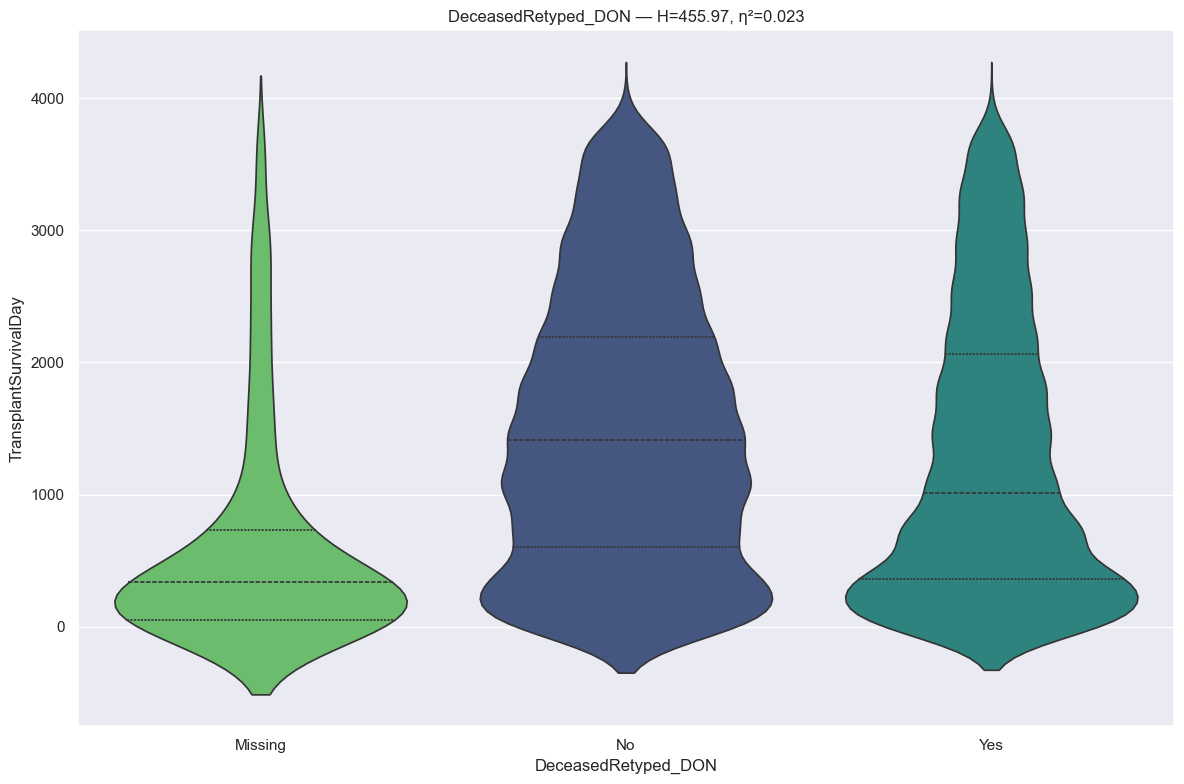

RANKING REPORT: DeceasedRetyped_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :    353 records
 * No                                                :   7755 records
 * Yes                                               :  11899 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 455.9710 | P-value: 9.708720e-100 | Effect η²: 0.0227
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=7.7017e-63 | thr=0.0167 | r= 0.526 | *Sig*
No           vs Yes          | p=4.8613e-54 | thr=0.0167 | r=-0.130 | *Sig*
Missing      vs Yes          | p=5.6914e-40 | thr=0.0167 | r= 0.413 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [7]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni", # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [8]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3'}


,DeceasedRetyped_DON,mean_survival_days,record_count
2,Yes,1253.558702,11899
1,No,1471.829014,7755
0,Missing,604.410765,353


##### **Note:** Statistically significant after Bonferroni and practically meaningful (|r| > 0.10 threshold) and none should be collapsed.

#### Antigen DA1

In [9]:
# info
features = u.get_feature_info(df, 'AntigenDA1', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top  freq
AntigenDA1_DON  20007     39   2  7936

:::: NaN Count:
AntigenDA1_DON    0 



{'AntigenDA1_DON': CategoricalDtype(categories=['01:01', '01:02', '02:01', '02:02', '02:03', '02:05',
                   '02:06', '03:01', '03:02', '1', '10', '11', '11:01', '2',
                   '23', '24', '24:02', '24:03', '25', '26', '26:01', '28',
                   '29', '29:02', '3', '30', '30:01', '31', '32', '33', '33:03',
                   '34', '34:02', '36', '66', '66:01', '68', '68:02', '69',
                   '74', 'Missing'],
 , ordered=False, categories_dtype=object)}

* Bonferroni/Holm (FWER): These are "perfectionists." They try to ensure there is a 0% chance of even one single mistake (Type I error) across all 741 tests. With 39 categories, these methods become incredibly strict, often failing to find differences even when they exist.
* FDR (Benjamini–Hochberg): This is a "pragmatist." It says, "If I claim 100 pairs are different, I’m okay if $\approx$5 of those claims are wrong." It controls the proportion of errors rather than the existence of a single error.
* We still want to be careful about false positives, but I don’t want to throw away everything here 

In [10]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3'}


,AntigenDA1_DON,mean_survival_days,record_count
12,2,1332.905620,7936
8,1,1335.125644,4465
23,3,1364.078074,2472
14,24,1317.361809,1194
10,11,1360.885584,874
13,23,1308.965007,743
24,30,1305.155357,560
21,29,1290.616046,349
18,26,1332.861789,246
26,31,1342.413613,191


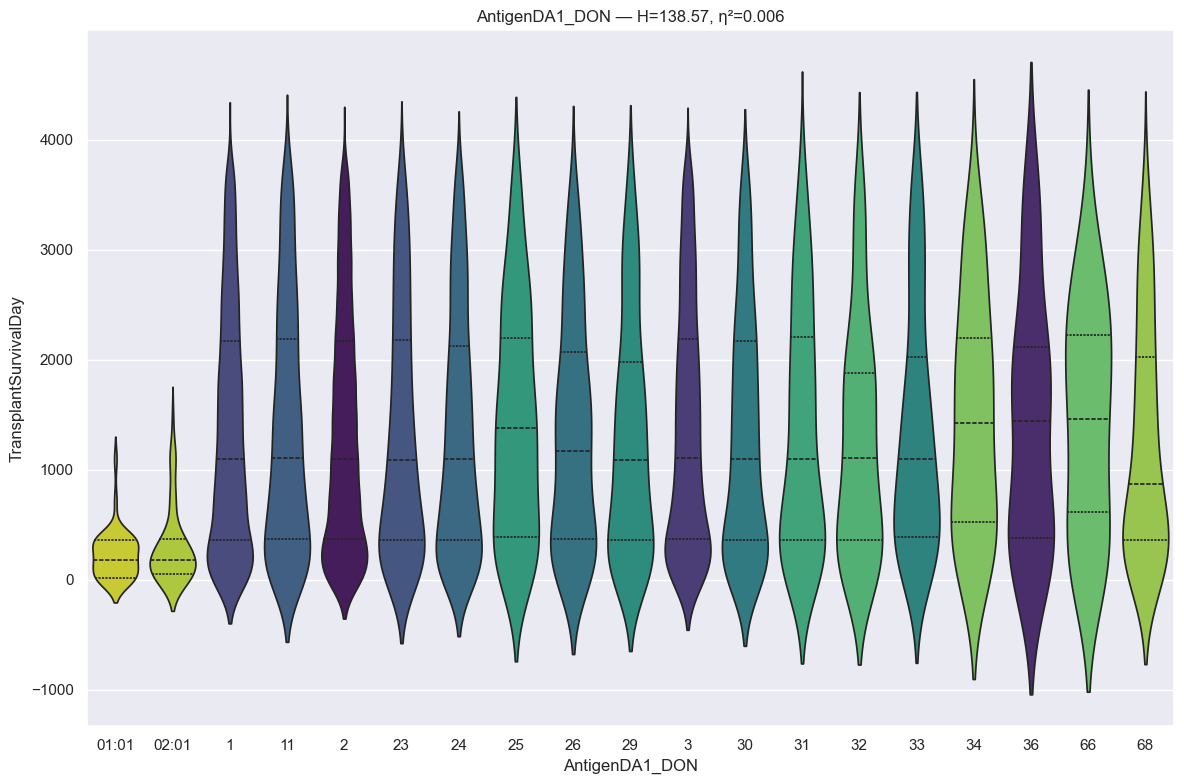

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:01                                             :     41 records
 * 02:01                                             :     64 records
 * 1                                                 :   4465 records
 * 11                                                :    874 records
 * 2                                                 :   7936 records
 * 23                                                :    743 records
 * 24                                                :   1194 records
 * 25                                                :    165 records
 * 26                                                :    246 records
 * 29                                                :    349 records
 * 3                                                 :   2472 records
 * 30                                                :    560 records
 * 31                                                :    191 records
 * 32                        

In [11]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [12]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'01:01': 'Group_1', '02:01': 'Group_2', '1': 'Group_3', '11': 'Group_3', '2': 'Group_3', '23': 'Group_3', '24': 'Group_3', '25': 'Group_3', '26': 'Group_3', '29': 'Group_3', '3': 'Group_3', '30': 'Group_3', '31': 'Group_3', '32': 'Group_3', '33': 'Group_3', '34': 'Group_3', '36': 'Group_3', '66': 'Group_3', '68': 'Group_3', '01:02': 'Other', '02:03': 'Other', '02:05': 'Other', '02:06': 'Other', '03:01': 'Other', '03:02': 'Other', '10': 'Other', '11:01': 'Other', '24:02': 'Other', '24:03': 'Other', '26:01': 'Other', '28': 'Other', '29:02': 'Other', '30:01': 'Other', '33:03': 'Other', '34:02': 'Other', '66:01': 'Other', '68:02': 'Other', '74': 'Other', 'Missing': 'Other'}


,AntigenDA1_DON,mean_survival_days,record_count
12,2,1332.905620,7936
8,1,1335.125644,4465
23,3,1364.078074,2472
14,24,1317.361809,1194
10,11,1360.885584,874
13,23,1308.965007,743
24,30,1305.155357,560
21,29,1290.616046,349
18,26,1332.861789,246
26,31,1342.413613,191


In [13]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: AntigenDA1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:01                                             :     41 records
 * 02:01                                             :     64 records
 * 1                                                 :   4465 records
 * 11                                                :    874 records
 * 2                                                 :   7936 records
 * 23                                                :    743 records
 * 24                                                :   1194 records
 * 25                                                :    165 records
 * 26                                                :    246 records
 * 29                                                :    349 records
 * 3                                                 :   2472 records
 * 30                                                :    560 records
 * 31                                                :    191 records
 * 32                        

In [14]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# initialize list
remove_cols = features
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### AntigenDA2

In [15]:
# info
features = u.get_feature_info(df, 'AntigenDA2', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top  freq
AntigenDA2_DON  20007     46  68  2313

:::: NaN Count:
AntigenDA2_DON    0 



{'AntigenDA2_DON': CategoricalDtype(categories=['0', '01:01', '02:01', '02:03', '02:05', '02:06', '03:01',
                   '1', '10', '11', '11:01', '2', '23', '24', '24:02', '24:03',
                   '25', '26', '26:01', '28', '29', '29:01', '29:02', '3', '30',
                   '30:01', '30:02', '31', '32', '33', '33:01', '33:03', '34',
                   '34:02', '36', '43', '66', '66:01', '66:02', '68', '68:01',
                   '68:02', '69', '74', '80', 'Missing',
                   'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

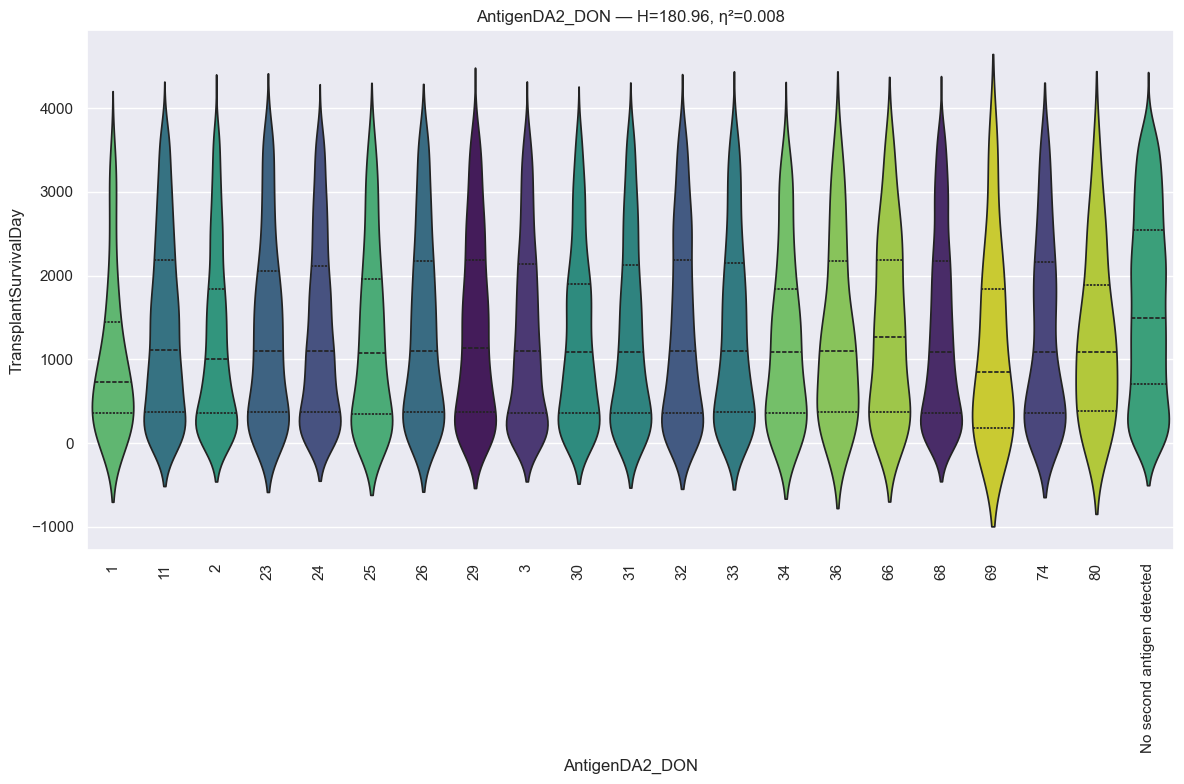

RANKING REPORT: AntigenDA2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1                                                 :    123 records
 * 11                                                :   1179 records
 * 2                                                 :   1930 records
 * 23                                                :    657 records
 * 24                                                :   2205 records
 * 25                                                :    463 records
 * 26                                                :    712 records
 * 29                                                :   1046 records
 * 3                                                 :   2073 records
 * 30                                                :   1301 records
 * 31                                                :   1031 records
 * 32                                                :   1035 records
 * 33                                                :    881 records
 * 34                        

In [16]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=90,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [17]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'1': 'Group_1', '69': 'Group_1', '11': 'Group_2', '2': 'Group_2', '23': 'Group_2', '24': 'Group_2', '25': 'Group_2', '26': 'Group_2', '29': 'Group_2', '3': 'Group_2', '30': 'Group_2', '31': 'Group_2', '32': 'Group_2', '33': 'Group_2', '34': 'Group_2', '36': 'Group_2', '66': 'Group_2', '68': 'Group_2', '74': 'Group_2', '80': 'Group_2', 'No second antigen detected': 'Group_3', '01:01': 'Other', '02:01': 'Other', '02:03': 'Other', '02:05': 'Other', '02:06': 'Other', '03:01': 'Other', '10': 'Other', '11:01': 'Other', '24:02': 'Other', '24:03': 'Other', '26:01': 'Other', '28': 'Other', '29:01': 'Other', '29:02': 'Other', '30:01': 'Other', '30:02': 'Other', '33:01': 'Other', '33:03': 'Other', '34:02': 'Other', '43': 'Other', '66:01': 'Other', '66:02': 'Other', '68:01': 'Other', '68:02': 'Other', 'Missing': 'Other'}


,AntigenDA2_DON,mean_survival_days,record_count
38,68,1328.291396,2313
12,24,1313.414059,2205
22,3,1299.107574,2073
10,2,1215.125907,1930
45,No second antigen detected,1638.123442,1685
23,30,1274.135281,1301
8,11,1365.620865,1179
19,29,1372.146272,1046
27,32,1342.907246,1035
26,31,1293.755577,1031


In [18]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

19

In [19]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

####  Antigen DB1

In [20]:
# info
features = u.get_feature_info(df, 'AntigenDB1', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top  freq
AntigenDB1_DON  20007     76   7  3978

:::: NaN Count:
AntigenDB1_DON    0 



{'AntigenDB1_DON': CategoricalDtype(categories=['07:02', '08:01', '13', '13:02', '14', '14:01', '14:02',
                   '15', '15:01', '15:03', '15:07', '15:10', '15:16', '15:17',
                   '15:18', '18', '27', '27:04', '27:05', '35', '35:01',
                   '35:02', '35:03', '35:08', '35:12', '37', '38', '38:01',
                   '39', '39:01', '39:02', '39:06', '40', '40:01', '40:02',
                   '40:05', '40:06', '41', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '49', '50',
                   '50:01', '51', '51:01', '51:02', '52', '53', '54', '55',
                   '55:01', '56', '56:03', '57', '58', '59', '60', '61', '62',
                   '63', '64', '65', '7', '70', '703', '71', '72', '75', '76',
                   '77', '78', '8', '81', 'Missing'],
 , ordered=False, categories_dtype=object)}

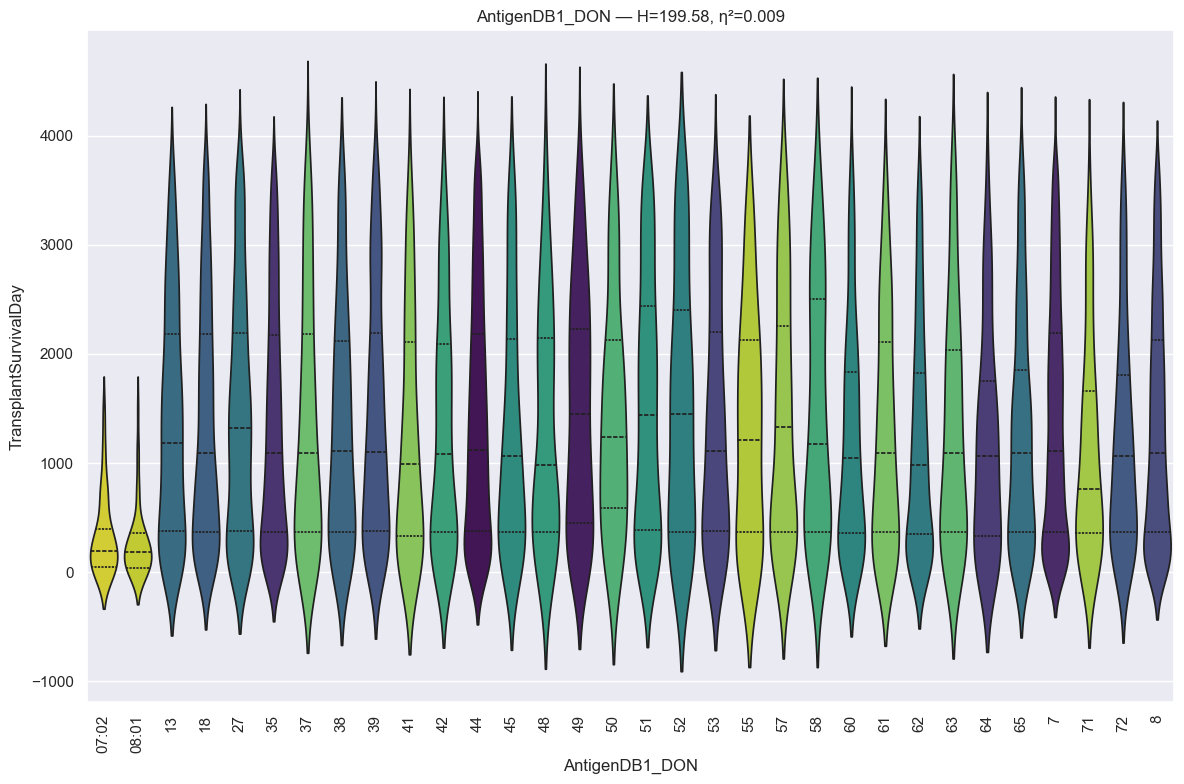

RANKING REPORT: AntigenDB1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 07:02                                             :     54 records
 * 08:01                                             :     47 records
 * 13                                                :    601 records
 * 18                                                :   1101 records
 * 27                                                :    831 records
 * 35                                                :   2413 records
 * 37                                                :    249 records
 * 38                                                :    308 records
 * 39                                                :    575 records
 * 41                                                :    171 records
 * 42                                                :    272 records
 * 44                                                :   1766 records
 * 45                                                :    263 records
 * 48                        

In [21]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [22]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'07:02': 'Group_1', '08:01': 'Group_2', '13': 'Group_3', '18': 'Group_3', '27': 'Group_3', '35': 'Group_3', '37': 'Group_3', '38': 'Group_3', '39': 'Group_3', '41': 'Group_3', '42': 'Group_3', '44': 'Group_3', '45': 'Group_3', '48': 'Group_3', '49': 'Group_3', '50': 'Group_3', '51': 'Group_3', '52': 'Group_3', '53': 'Group_3', '55': 'Group_3', '57': 'Group_3', '58': 'Group_3', '60': 'Group_3', '61': 'Group_3', '62': 'Group_3', '63': 'Group_3', '64': 'Group_3', '65': 'Group_3', '7': 'Group_3', '71': 'Group_3', '72': 'Group_3', '8': 'Group_3', '13:02': 'Other', '14': 'Other', '14:01': 'Other', '14:02': 'Other', '15': 'Other', '15:01': 'Other', '15:03': 'Other', '15:10': 'Other', '15:16': 'Other', '15:18': 'Other', '27:05': 'Other', '35:01': 'Other', '35:02': 'Other', '35:03': 'Other', '35:08': 'Other', '35:12': 'Other', '38:01': 'Other', '39:01': 'Other', '39:02': 'Other', '39:06': 'Other', '40': 'Other', '40:01': 'Other', '40:02': 'Other', '40:05': 'Other', '41:02': 'Other', '42:01': '

,AntigenDB1_DON,mean_survival_days,record_count
66,7,1368.573906,3978
73,8,1305.704305,2648
16,35,1326.891007,2413
38,44,1383.828992,1766
13,18,1341.009991,1101
62,62,1172.743169,915
14,27,1423.552347,831
2,13,1385.760399,601
25,39,1382.886957,575
65,65,1287.134694,490


In [23]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

66

In [24]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Antigen DB2

In [25]:
# info
features = u.get_feature_info(df, 'AntigenDB2', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top  freq
AntigenDB2_DON  20007     85  44  2826

:::: NaN Count:
AntigenDB2_DON    0 



{'AntigenDB2_DON': CategoricalDtype(categories=['07:02', '08:01', '12', '13', '13:02', '14', '14:01',
                   '14:02', '15', '15:01', '15:10', '15:16', '15:17', '18',
                   '22', '27', '27:05', '27:08', '35', '35:01', '35:02',
                   '35:03', '35:08', '35:12', '37', '38', '38:01', '39',
                   '39:01', '39:02', '39:05', '39:06', '40', '40:01', '40:02',
                   '40:05', '41', '41:01', '41:02', '42', '42:01', '42:02',
                   '44', '44:02', '44:03', '45', '46', '47', '48', '48:01',
                   '49', '50', '50:01', '51', '51:01', '51:02', '52', '53',
                   '54', '55', '55:01', '56', '56:01', '57', '57:01', '57:03',
                   '58', '59', '60', '61', '62', '63', '64', '65', '67', '7',
                   '70', '71', '72', '73', '75', '76', '77', '78', '8', '81',
                   '82', '82:01', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

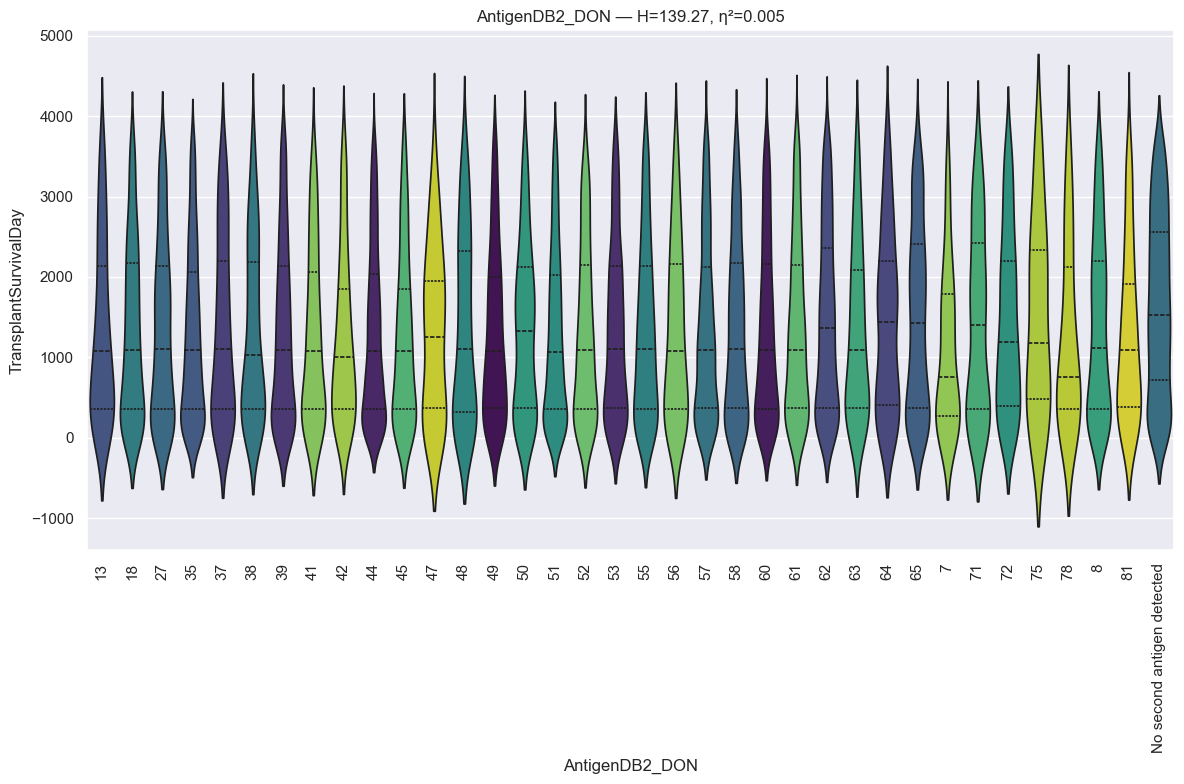

RANKING REPORT: AntigenDB2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 13                                                :    163 records
 * 18                                                :    467 records
 * 27                                                :    447 records
 * 35                                                :   1392 records
 * 37                                                :    240 records
 * 38                                                :    280 records
 * 39                                                :    633 records
 * 41                                                :    227 records
 * 42                                                :    218 records
 * 44                                                :   2826 records
 * 45                                                :    425 records
 * 47                                                :     60 records
 * 48                                                :    167 records
 * 49                        

In [26]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [27]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'13': 'Group_1', '18': 'Group_1', '27': 'Group_1', '35': 'Group_1', '37': 'Group_1', '38': 'Group_1', '39': 'Group_1', '41': 'Group_1', '42': 'Group_1', '44': 'Group_1', '45': 'Group_1', '47': 'Group_1', '48': 'Group_1', '49': 'Group_1', '50': 'Group_1', '51': 'Group_1', '52': 'Group_1', '53': 'Group_1', '55': 'Group_1', '56': 'Group_1', '57': 'Group_1', '58': 'Group_1', '60': 'Group_1', '61': 'Group_1', '62': 'Group_1', '63': 'Group_1', '64': 'Group_1', '65': 'Group_1', '71': 'Group_1', '72': 'Group_1', '75': 'Group_1', '78': 'Group_1', '8': 'Group_1', '81': 'Group_1', '7': 'Group_2', 'No second antigen detected': 'Group_3', '07:02': 'Other', '08:01': 'Other', '12': 'Other', '13:02': 'Other', '14': 'Other', '14:01': 'Other', '14:02': 'Other', '15': 'Other', '15:01': 'Other', '15:10': 'Other', '15:17': 'Other', '27:05': 'Other', '27:08': 'Other', '35:01': 'Other', '35:02': 'Other', '35:03': 'Other', '35:08': 'Other', '35:12': 'Other', '38:01': 'Other', '39:01': 'Other', '39:02': 'Othe

,AntigenDB2_DON,mean_survival_days,record_count
38,44,1273.490800,2826
49,51,1259.640959,1543
16,35,1275.472701,1392
59,57,1325.569738,1183
64,60,1321.175376,1129
66,62,1466.164408,1107
84,No second antigen detected,1654.549020,918
62,58,1334.509067,772
53,53,1332.873362,687
25,39,1302.971564,633


In [28]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

24

In [29]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Antigen DR1

In [30]:
# info
features = u.get_feature_info(df, 'AntigenDR1', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top  freq
AntigenDR1_DON  20007     43   4  5012

:::: NaN Count:
AntigenDR1_DON    0 



{'AntigenDR1_DON': CategoricalDtype(categories=['01:01', '01:02', '01:03', '03:01', '03:02', '04:01',
                   '04:02', '04:03', '04:04', '04:05', '04:07', '04:11',
                   '08:01', '08:02', '09:01', '1', '10', '103', '11', '11:01',
                   '11:03', '11:04', '12', '12:01', '13', '13:01', '13:02',
                   '13:03', '13:05', '14', '14:02', '14:04', '14:54', '15',
                   '15:01', '16', '17', '18', '3', '4', '7', '8', '9',
                   'Missing'],
 , ordered=False, categories_dtype=object)}

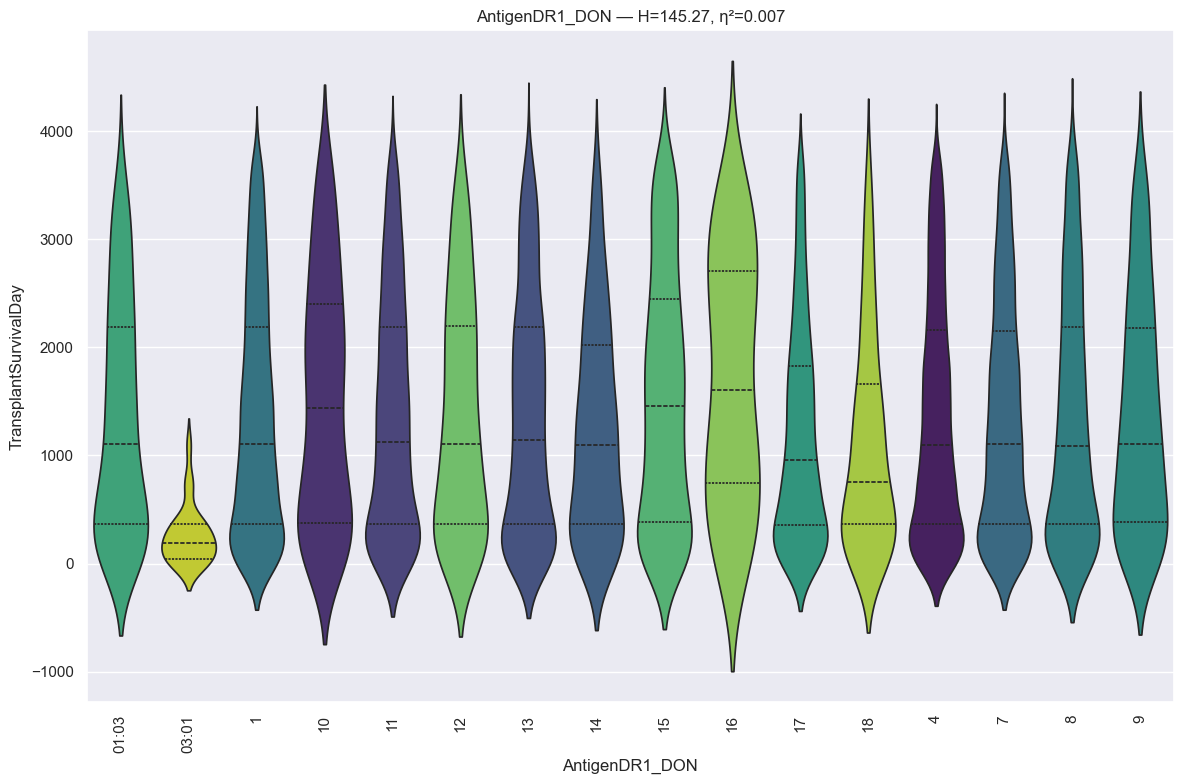

RANKING REPORT: AntigenDR1_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :    344 records
 * 03:01                                             :     48 records
 * 1                                                 :   3180 records
 * 10                                                :    244 records
 * 11                                                :   1590 records
 * 12                                                :    309 records
 * 13                                                :   1472 records
 * 14                                                :    333 records
 * 15                                                :    757 records
 * 16                                                :     58 records
 * 17                                                :   1930 records
 * 18                                                :    257 records
 * 4                                                 :   5012 records
 * 7                         

In [31]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [32]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'01:03': 'Group_1', '1': 'Group_1', '11': 'Group_1', '12': 'Group_1', '13': 'Group_1', '14': 'Group_1', '4': 'Group_1', '7': 'Group_1', '8': 'Group_1', '9': 'Group_1', '03:01': 'Group_2', '10': 'Group_3', '15': 'Group_3', '16': 'Group_4', '17': 'Group_5', '18': 'Group_5', '01:01': 'Other', '01:02': 'Other', '03:02': 'Other', '04:01': 'Other', '04:02': 'Other', '04:03': 'Other', '04:04': 'Other', '04:05': 'Other', '04:07': 'Other', '04:11': 'Other', '08:01': 'Other', '08:02': 'Other', '09:01': 'Other', '103': 'Other', '11:01': 'Other', '11:03': 'Other', '11:04': 'Other', '12:01': 'Other', '13:01': 'Other', '13:02': 'Other', '13:03': 'Other', '13:05': 'Other', '14:04': 'Other', '14:54': 'Other', '15:01': 'Other', '3': 'Other', 'Missing': 'Other'}


,AntigenDR1_DON,mean_survival_days,record_count
38,4,1327.943935,5012
15,1,1363.427673,3180
39,7,1333.009652,2901
35,17,1176.674611,1930
18,11,1370.537107,1590
24,13,1379.312500,1472
40,8,1329.870556,1097
32,15,1527.989432,757
2,01:03,1331.345930,344
41,9,1367.584795,342


In [33]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

29

In [34]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Antigen DR2

In [35]:
# info
features = u.get_feature_info(df, 'AntigenDR2', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top  freq
AntigenDR2_DON  20007     44  15  4192

:::: NaN Count:
AntigenDR2_DON    0 



{'AntigenDR2_DON': CategoricalDtype(categories=['01:01', '01:03', '03:01', '04:01', '04:04', '04:05',
                   '04:07', '08:01', '08:02', '09:01', '1', '10', '103', '11',
                   '11:01', '11:03', '11:04', '12', '12:01', '12:02', '13',
                   '13:01', '13:02', '13:03', '13:05', '14', '14:01', '14:02',
                   '14:04', '14:06', '14:54', '15', '15:01', '15:02', '15:03',
                   '16', '16:01', '16:02', '17', '18', '3', '4', '5', '7', '8',
                   '9', 'Missing', 'No second antigen detected'],
 , ordered=False, categories_dtype=object)}

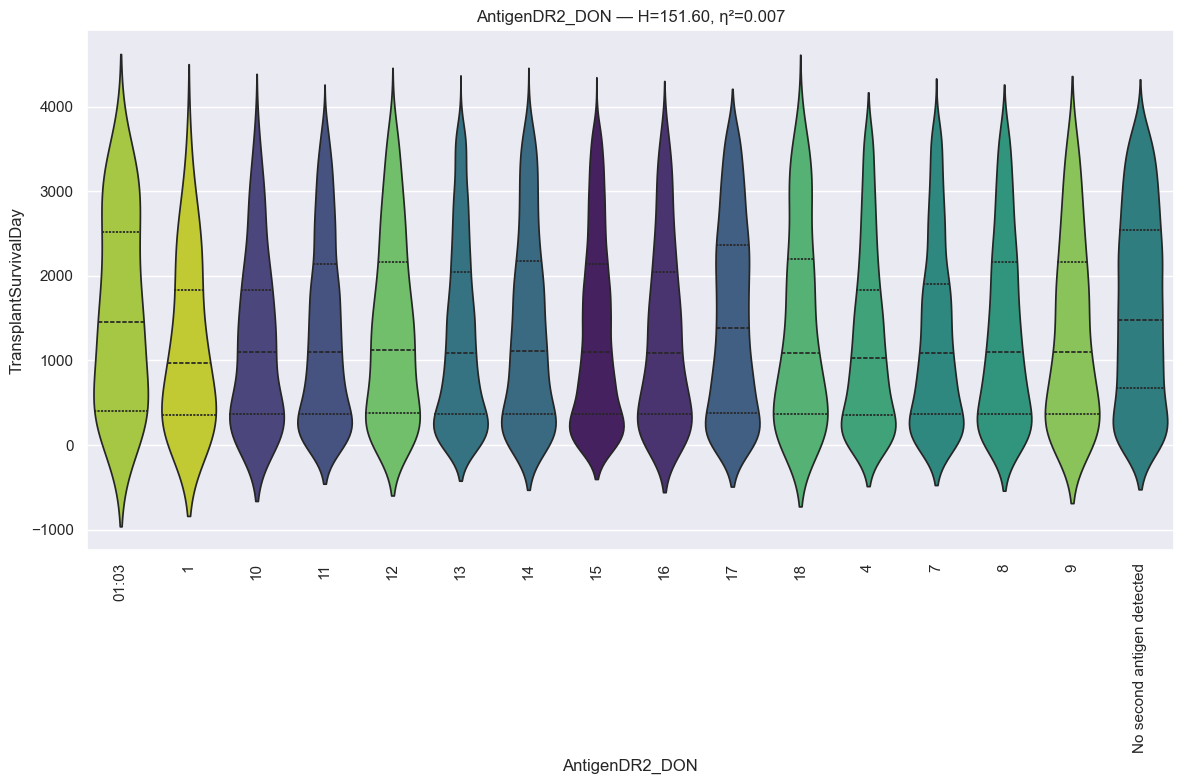

RANKING REPORT: AntigenDR2_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 01:03                                             :     59 records
 * 1                                                 :     66 records
 * 10                                                :    236 records
 * 11                                                :   2007 records
 * 12                                                :    530 records
 * 13                                                :   3124 records
 * 14                                                :   1146 records
 * 15                                                :   4192 records
 * 16                                                :    712 records
 * 17                                                :   1833 records
 * 18                                                :    291 records
 * 4                                                 :   1370 records
 * 7                                                 :   1724 records
 * 8                         

In [36]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [37]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'01:03': 'Group_1', 'No second antigen detected': 'Group_1', '1': 'Group_2', '10': 'Group_2', '11': 'Group_2', '12': 'Group_2', '13': 'Group_2', '14': 'Group_2', '15': 'Group_2', '16': 'Group_2', '17': 'Group_2', '18': 'Group_2', '4': 'Group_2', '7': 'Group_2', '8': 'Group_2', '9': 'Group_2', '01:01': 'Other', '03:01': 'Other', '04:01': 'Other', '04:04': 'Other', '04:05': 'Other', '08:01': 'Other', '08:02': 'Other', '09:01': 'Other', '103': 'Other', '11:01': 'Other', '11:03': 'Other', '11:04': 'Other', '12:01': 'Other', '13:01': 'Other', '13:02': 'Other', '13:03': 'Other', '13:05': 'Other', '14:01': 'Other', '14:02': 'Other', '14:04': 'Other', '14:06': 'Other', '14:54': 'Other', '15:01': 'Other', '15:02': 'Other', '15:03': 'Other', '16:01': 'Other', '16:02': 'Other', 'Missing': 'Other'}


,AntigenDR2_DON,mean_survival_days,record_count
29,15,1313.574905,4192
18,13,1268.121319,3124
12,11,1326.679621,2007
36,17,1463.146208,1833
39,7,1274.313805,1724
38,4,1214.260584,1370
43,No second antigen detected,1613.149665,1343
23,14,1359.410995,1146
40,8,1317.955435,920
33,16,1282.278090,712


In [38]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

16

In [39]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Citizenship

In [40]:
# info
features = u.get_feature_info(df, 'Citizenship', cat=False)
# dtype
{col: df[col].dtype for col in features}

                 count unique         top   freq
Citizenship_DON  20007      7  US Citizen  18000

:::: NaN Count:
Citizenship_DON    0 



{'Citizenship_DON': CategoricalDtype(categories=['Missing', 'NON-RESIDENT ALIEN',
                   'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant',
                   'Non-US Citizen/US Resident', 'RESIDENT ALIEN', 'US Citizen',
                   'Unknown'],
 , ordered=False, categories_dtype=object)}

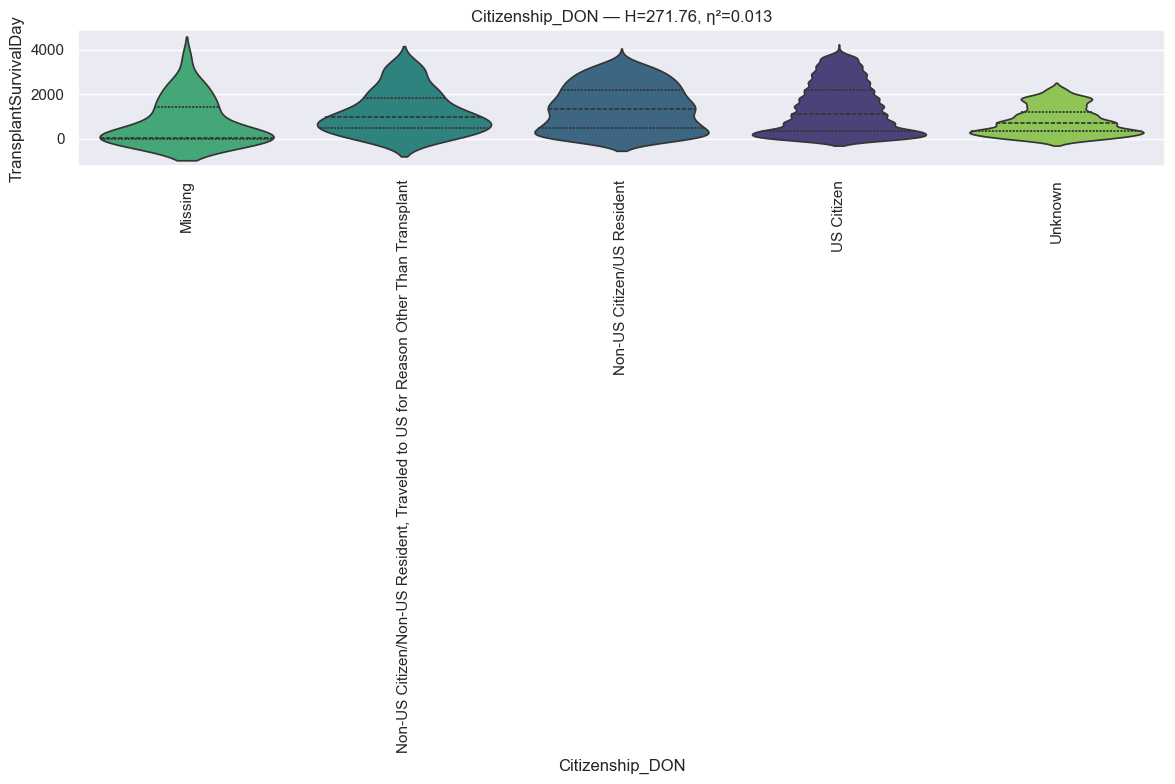

RANKING REPORT: Citizenship_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     36 records
 * Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant:     74 records
 * Non-US Citizen/US Resident                        :    668 records
 * US Citizen                                        :  18000 records
 * Unknown                                           :   1190 records
BYPASSED CATEGORIES (n < min_n):
 * NON-RESIDENT ALIEN                                :     10 records
 * RESIDENT ALIEN                                    :     29 records
--------------------------------------------------------------------------------
Kruskal H: 271.7595 | P-value: 1.332039e-57 | Effect η²: 0.0134
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 3 gro

In [41]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [42]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant': 'Group_2', 'Non-US Citizen/US Resident': 'Group_2', 'US Citizen': 'Group_2', 'Unknown': 'Group_3', 'NON-RESIDENT ALIEN': 'Other', 'RESIDENT ALIEN': 'Other'}


,Citizenship_DON,mean_survival_days,record_count
5,US Citizen,1358.029611,18000
6,Unknown,799.182353,1190
3,Non-US Citizen/US Resident,1391.616766,668
2,"Non-US Citizen/Non-US Resident, Traveled to US for Reason Other Than Transplant",1193.905405,74
0,Missing,735.305556,36
4,RESIDENT ALIEN,2742.586207,29
1,NON-RESIDENT ALIEN,2397.100000,10


In [43]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

6

In [44]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Past Cocaine Use

In [45]:
# info
features = u.get_feature_info(df, 'PastCocaineUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique top   freq
PastCocaineUse_DON  20007      4  No  14941

:::: NaN Count:
PastCocaineUse_DON    0 



{'PastCocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

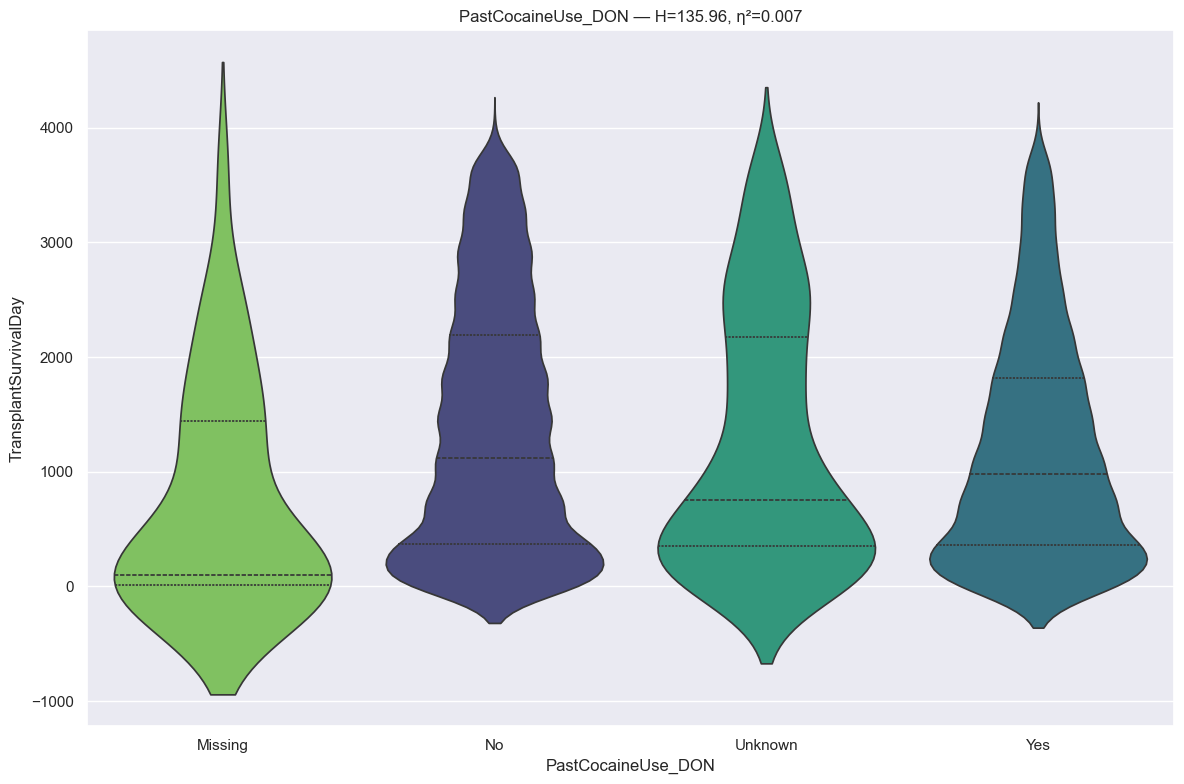

RANKING REPORT: PastCocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  14941 records
 * Unknown                                           :    383 records
 * Yes                                               :   4645 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 135.9621 | P-value: 2.805587e-29 | Effect η²: 0.0066
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.8975e-26 | thr=0.0083 | r=-0.103 | *Sig*
Missing      vs No           | p=4.2176e-06 | thr=0.0083 | r= 0.431 | *Sig*
Missing      vs Yes          | p=9.5442e-05 | thr=0.0083 | r= 0.367 | *Sig*
Missing      vs Unknown      | p=1.7079e-04 | thr=0.0083 | r= 0.370 | *Sig*
No   

In [46]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10, # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [47]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Unknown': 'Group_3', 'Yes': 'Group_3'}


,PastCocaineUse_DON,mean_survival_days,record_count
1,No,1380.615488,14941
3,Yes,1165.510872,4645
2,Unknown,1237.344648,383
0,Missing,737.078947,38


#### Ethnicity

In [48]:
# info
features = u.get_feature_info(df, 'Ethnicity', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique                  top   freq
Ethnicity_DON  20007      7  White, Non-Hispanic  12428

:::: NaN Count:
Ethnicity_DON    0 



{'Ethnicity_DON': CategoricalDtype(categories=['Amer Ind/Alaska Native', 'Asian', 'Black', 'Hispanic',
                   'Multiracial', 'Native Hawaiian/other Pacific Islander',
                   'White, Non-Hispanic'],
 , ordered=False, categories_dtype=object)}

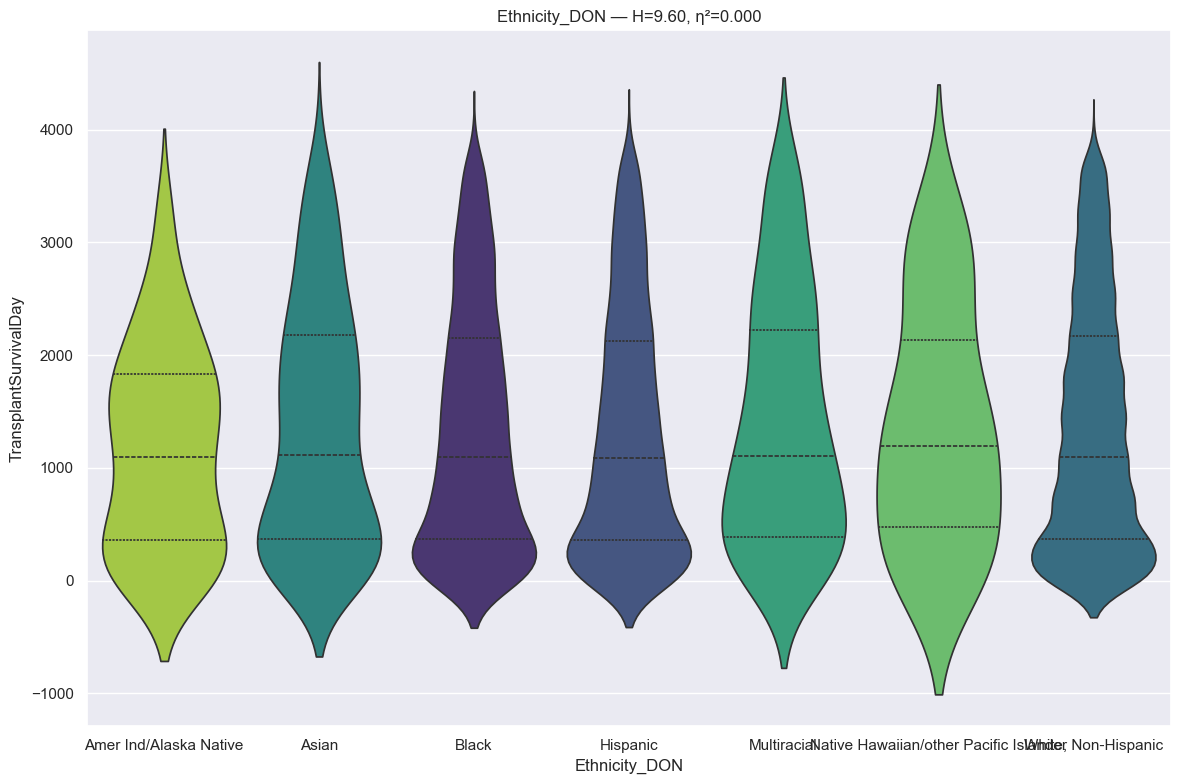

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Amer Ind/Alaska Native                            :    102 records
 * Asian                                             :    324 records
 * Black                                             :   3314 records
 * Hispanic                                          :   3629 records
 * Multiracial                                       :    172 records
 * Native Hawaiian/other Pacific Islander            :     38 records
 * White, Non-Hispanic                               :  12428 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 9.6015 | P-value: 1.424703e-01 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Hispanic     vs White, Non-Hispanic | p=9.4816e-03 | thr=0.0024 | r= 0.028 | Not Sig
Amer Ind/Alaska Nativ

In [49]:
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [50]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

{'Amer Ind/Alaska Native': 'Group_1', 'Asian': 'Group_1', 'Black': 'Group_1', 'Hispanic': 'Group_1', 'Multiracial': 'Group_1', 'Native Hawaiian/other Pacific Islander': 'Group_1', 'White, Non-Hispanic': 'Group_1'}


,Ethnicity_DON,mean_survival_days,record_count
6,"White, Non-Hispanic",1340.433135,12428
3,Hispanic,1286.079636,3629
2,Black,1316.984309,3314
1,Asian,1353.530864,324
4,Multiracial,1410.482558,172
0,Amer Ind/Alaska Native,1176.872549,102
5,Native Hawaiian/other Pacific Islander,1361.210526,38


In [51]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

0

In [52]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05, # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: Ethnicity_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Amer Ind/Alaska Native                            :    102 records
 * Asian                                             :    324 records
 * Black                                             :   3314 records
 * Hispanic                                          :   3629 records
 * Multiracial                                       :    172 records
 * Native Hawaiian/other Pacific Islander            :     38 records
 * White, Non-Hispanic                               :  12428 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 9.6015 | P-value: 1.424703e-01 | Effect η²: 0.0002
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.05)
--------------------------------------------------------------------------------
[Pairwise comparison output suppressed]
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [53]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

0

In [54]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

{'Amer Ind/Alaska Native': 'Group_1', 'Asian': 'Group_1', 'Black': 'Group_1', 'Hispanic': 'Group_1', 'Multiracial': 'Group_1', 'Native Hawaiian/other Pacific Islander': 'Group_1', 'White, Non-Hispanic': 'Group_1'}


,Ethnicity_DON,mean_survival_days,record_count
6,"White, Non-Hispanic",1340.433135,12428
3,Hispanic,1286.079636,3629
2,Black,1316.984309,3314
1,Asian,1353.530864,324
4,Multiracial,1410.482558,172
0,Amer Ind/Alaska Native,1176.872549,102
5,Native Hawaiian/other Pacific Islander,1361.210526,38


In [55]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** Non‑significant Global Kruskal–Wallis across all categories suggests there is no evidence that any ethnicity category differs in survival distribution, confirmed by the pairwise testing, therefore no splitting is justified.

#### Hepatitis B Core Antibody

In [56]:
# info
features = u.get_feature_info(df, 'Hepatitis_B_CoreAntibody', cat=False)
# dtype
{col: df[col].dtype for col in features}

                              count unique       top   freq
Hepatitis_B_CoreAntibody_DON  20007      5  Negative  19595

:::: NaN Count:
Hepatitis_B_CoreAntibody_DON    0 



{'Hepatitis_B_CoreAntibody_DON': CategoricalDtype(categories=['Indeterminate', 'Negative', 'Not Done', 'Pending',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

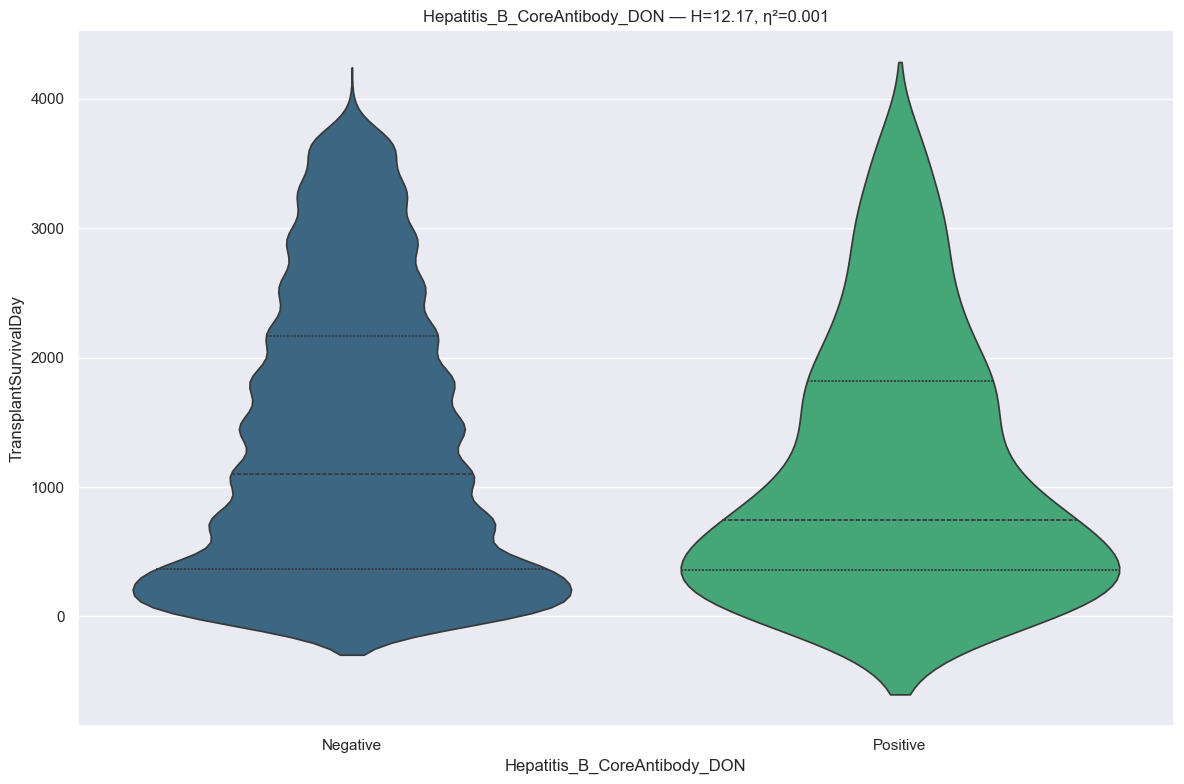

RANKING REPORT: Hepatitis_B_CoreAntibody_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :  19595 records
 * Positive                                          :    400 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :      1 records
 * Not Done                                          :     10 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 12.1671 | P-value: 4.863923e-04 | Effect η²: 0.0006
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.05)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=4.8640e-04 | thr=0.0500 | r=-0.102 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [57]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df,features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [58]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df,features[0])

{'Negative': 'Group_1', 'Positive': 'Group_2', 'Indeterminate': 'Other', 'Not Done': 'Other', 'Pending': 'Other'}


,Hepatitis_B_CoreAntibody_DON,mean_survival_days,record_count
1,Negative,1330.591375,19595
4,Positive,1138.667500,400
2,Not Done,1247.600000,10
0,Indeterminate,374.000000,1
3,Pending,2231.000000,1


In [59]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Not Done': 'Other',
           'Indeterminate': 'Other',
           'Pending': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

,Hepatitis_B_CoreAntibody_DON,mean_survival_days,record_count
0,Negative,1330.591375,19595
2,Positive,1138.667500,400
1,Other,1256.750000,12


#### Surface Antigen HEP B

In [60]:
# info
features = u.get_feature_info(df, 'SurfaceAntigenHEP_B', cat=False)
# dtype
{col: df[col].dtype for col in features}

                         count unique       top   freq
SurfaceAntigenHEP_B_DON  20007      5  Negative  19971

:::: NaN Count:
SurfaceAntigenHEP_B_DON    0 



{'SurfaceAntigenHEP_B_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive'],
 , ordered=False, categories_dtype=object)}

In [61]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

[WARNING] Cannot perform statistical comparison for SurfaceAntigenHEP_B_DON
          Only 1 category has n ≥ 30.
          You can only compare MORE THAN ONE category since n < min_n.



In [62]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1'}


,SurfaceAntigenHEP_B_DON,mean_survival_days,record_count
2,Negative,1326.824946,19971
4,Positive,801.500000,14
1,Missing,1316.454545,11
3,Not Done,1592.000000,9
0,Indeterminate,2717.500000,2


##### **Note:** We will perform a manual Binning in which the Positive, Missing, Not Done, and Indeterminate groups are grouped into a single category called `Non-Negative` (Total $n=36$). This would give us just enough data to meet your $n \ge 30$ threshold and compare `Negative` vs. `Non-Negative`.

In [63]:
# mapping
mapping = {'Positive': 'Other',
           'Missing': 'Other',
           'Not Done': 'Other',
           'Indeterminate': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df, features[0])

,SurfaceAntigenHEP_B_DON,mean_survival_days,record_count
0,Negative,1326.824946,19971
1,Other,1262.916667,36


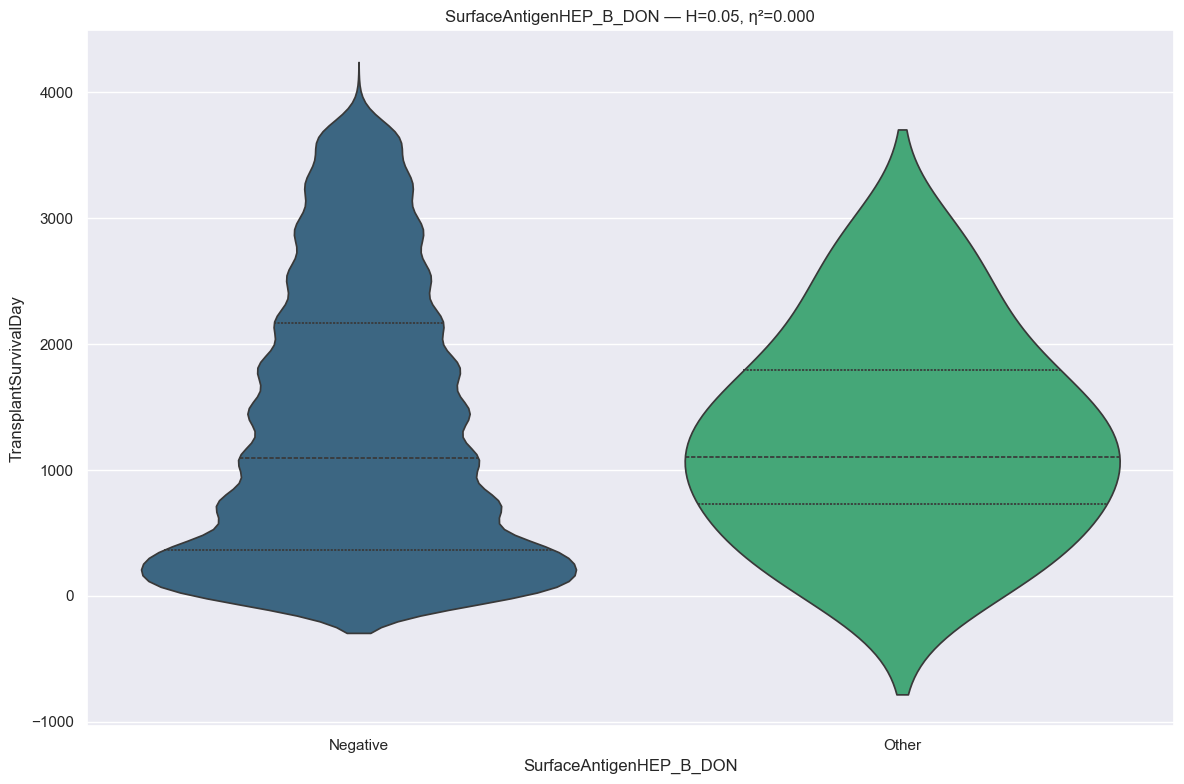

RANKING REPORT: SurfaceAntigenHEP_B_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :  19971 records
 * Other                                             :     36 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 0.0483 | P-value: 8.261188e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Other        | p=8.2613e-01 | thr=0.0500 | r= 0.021 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [64]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [65]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1', 'Other': 'Group_1'}


,SurfaceAntigenHEP_B_DON,mean_survival_days,record_count
0,Negative,1326.824946,19971
1,Other,1262.916667,36


In [66]:
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list
remove_cols.extend(features)

##### **Note:** This feature does not have a statistically or practically significant impact on survival.

#### Blood Group

In [67]:
# info
features = u.get_feature_info(df, 'BloodGroup', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top   freq
BloodGroup_DON  20007      8   O  10018

:::: NaN Count:
BloodGroup_DON    0 



{'BloodGroup_DON': CategoricalDtype(categories=['A', 'A1', 'A1B', 'A2', 'A2B', 'AB', 'B', 'O'], ordered=False, categories_dtype=object)}

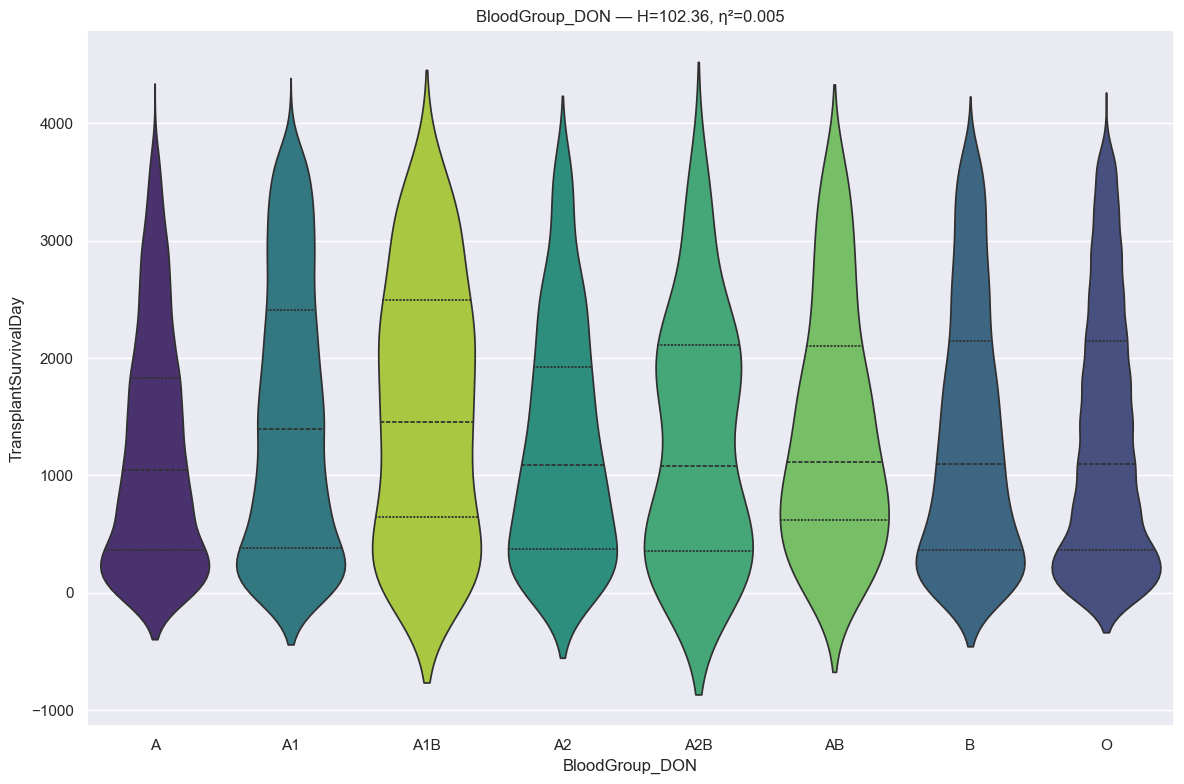

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * A                                                 :   3040 records
 * A1                                                :   3539 records
 * A1B                                               :    194 records
 * A2                                                :    606 records
 * A2B                                               :     74 records
 * AB                                                :    242 records
 * B                                                 :   2294 records
 * O                                                 :  10018 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 102.3577 | P-value: 3.513755e-19 | Effect η²: 0.0048
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0018 | r_threshold: 0.05)
--------------------------------------------------------------------------------
A            vs A1           | p=

In [68]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=False,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [69]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'A': 'Group_1', 'A2': 'Group_1', 'A2B': 'Group_1', 'B': 'Group_1', 'O': 'Group_1', 'A1': 'Group_2', 'A1B': 'Group_2', 'AB': 'Group_2'}


,BloodGroup_DON,mean_survival_days,record_count
7,O,1310.498004,10018
1,A1,1478.598474,3539
0,A,1198.469737,3040
6,B,1322.562772,2294
3,A2,1271.775578,606
5,AB,1390.615702,242
2,A1B,1554.958763,194
4,A2B,1296.797297,74


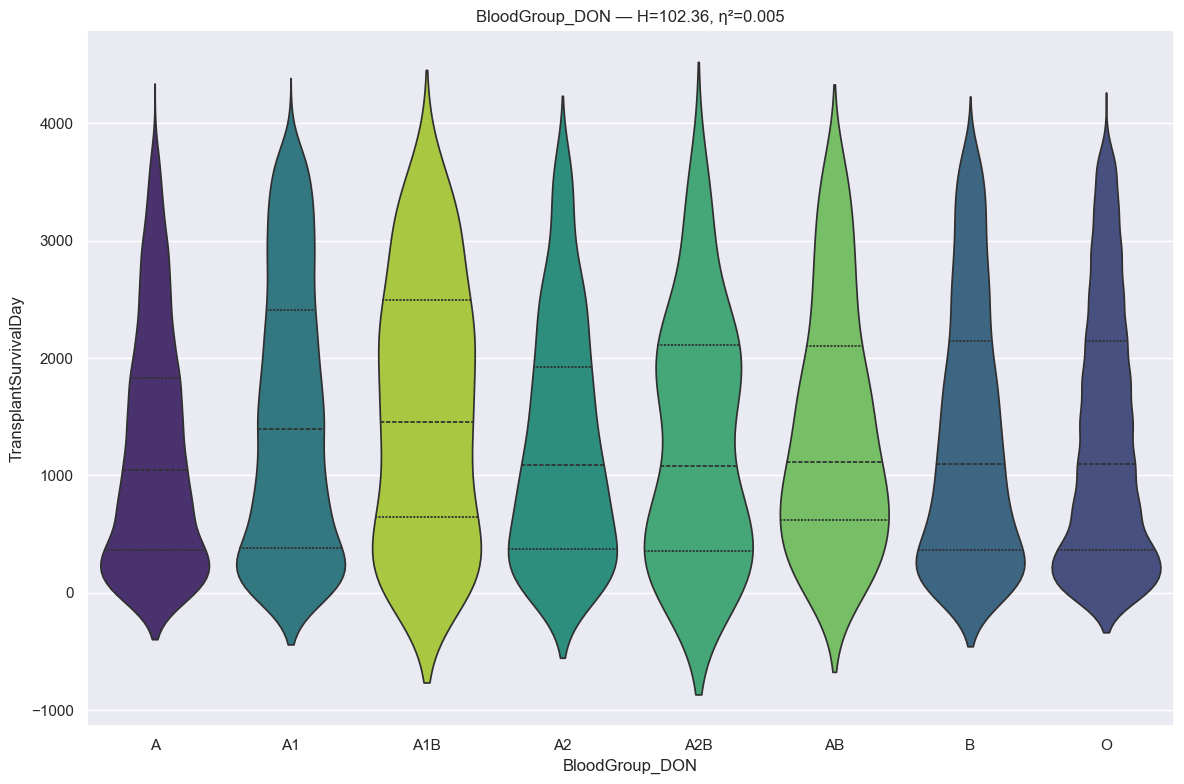

RANKING REPORT: BloodGroup_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * A                                                 :   3040 records
 * A1                                                :   3539 records
 * A1B                                               :    194 records
 * A2                                                :    606 records
 * A2B                                               :     74 records
 * AB                                                :    242 records
 * B                                                 :   2294 records
 * O                                                 :  10018 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 102.3577 | P-value: 3.513755e-19 | Effect η²: 0.0048
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.05)
--------------------------------------------------------------------------------
A            vs A1           | p=9

In [70]:
# FDR is the most relaxed
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=False,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [71]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'A': 'Group_1', 'A2': 'Group_1', 'A2B': 'Group_1', 'B': 'Group_1', 'O': 'Group_1', 'A1': 'Group_2', 'A1B': 'Group_2', 'AB': 'Group_2'}


,BloodGroup_DON,mean_survival_days,record_count
7,O,1310.498004,10018
1,A1,1478.598474,3539
0,A,1198.469737,3040
6,B,1322.562772,2294
3,A2,1271.775578,606
5,AB,1390.615702,242
2,A1B,1554.958763,194
4,A2B,1296.797297,74


##### **Note:** Not going to collapse blood types since it is a very important part of transplant

#### Heavy Alcohol Use

In [72]:
# info
features = u.get_feature_info(df, 'HeavyAlcoholUse_DON', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique top   freq
HeavyAlcoholUse_DON  20007      4  No  15661

:::: NaN Count:
HeavyAlcoholUse_DON    0 



{'HeavyAlcoholUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

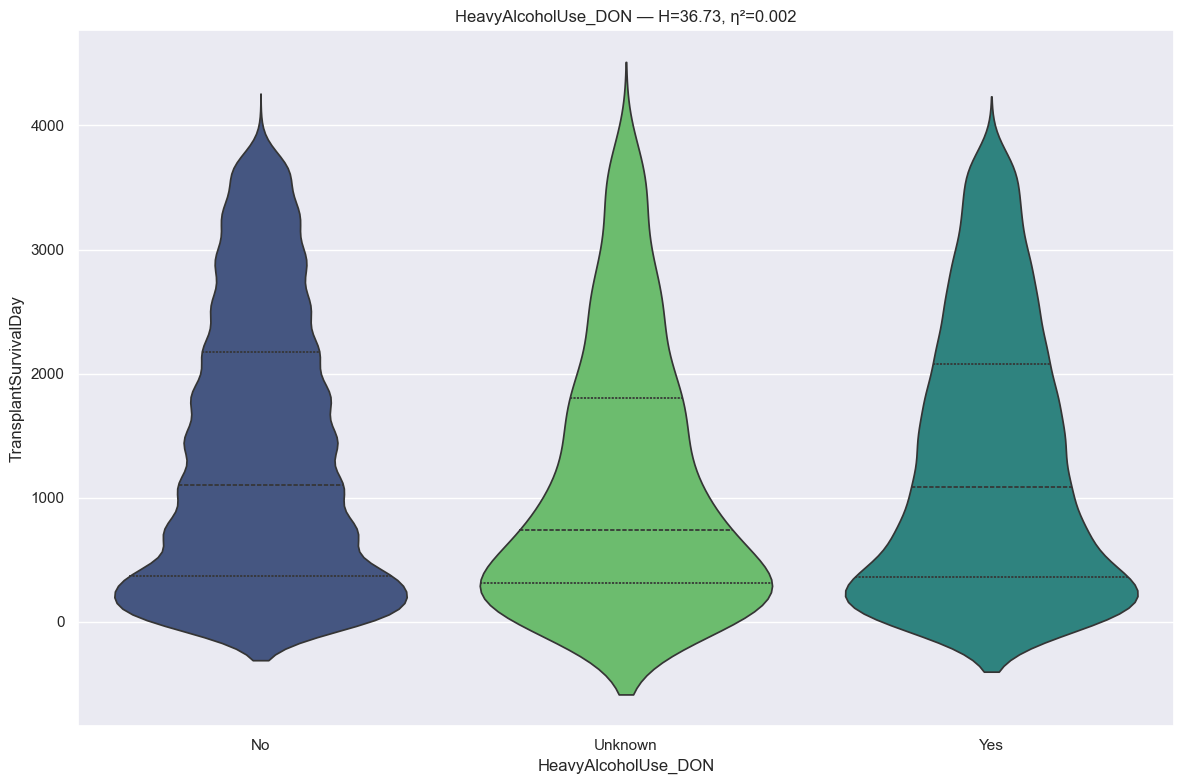

RANKING REPORT: HeavyAlcoholUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  15661 records
 * Unknown                                           :    513 records
 * Yes                                               :   3823 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     10 records
--------------------------------------------------------------------------------
Kruskal H: 36.7291 | P-value: 1.057741e-08 | Effect η²: 0.0017
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=4.9971e-07 | thr=0.0167 | r=-0.130 | *Sig*
No           vs Yes          | p=1.6486e-04 | thr=0.0167 | r=-0.039 | *Sig*
Unknown      vs Yes          | p=7.5035e-04 | thr=0.0167 | r= 0.092 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [73]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [74]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_2', 'Yes': 'Group_3', 'Missing': 'Other'}


,HeavyAlcoholUse_DON,mean_survival_days,record_count
1,No,1346.692868,15661
3,Yes,1273.254512,3823
2,Unknown,1114.514620,513
0,Missing,1353.100000,10


In [75]:
# Collapse Missing & Unknown into Other
# mapping: collapse Missing & Unknown: small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,HeavyAlcoholUse_DON,mean_survival_days,record_count
0,No,1346.692868,15661
2,Yes,1273.254512,3823
1,Other,1119.076482,523


#### Gender

In [76]:
# add to remove list
remove_cols.extend(['Gender_DON'])

#### Residency State

In [77]:
# info
features = u.get_feature_info(df, 'ResidencyState', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique top  freq
ResidencyState_DON  20007     54  CA  2183

:::: NaN Count:
ResidencyState_DON    0 



{'ResidencyState_DON': CategoricalDtype(categories=['AK', 'AL', 'AR', 'AS', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE',
                   'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA',
                   'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND',
                   'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA',
                   'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA',
                   'WI', 'WV', 'WY', 'XX', 'ZZ'],
 , ordered=False, categories_dtype=object)}

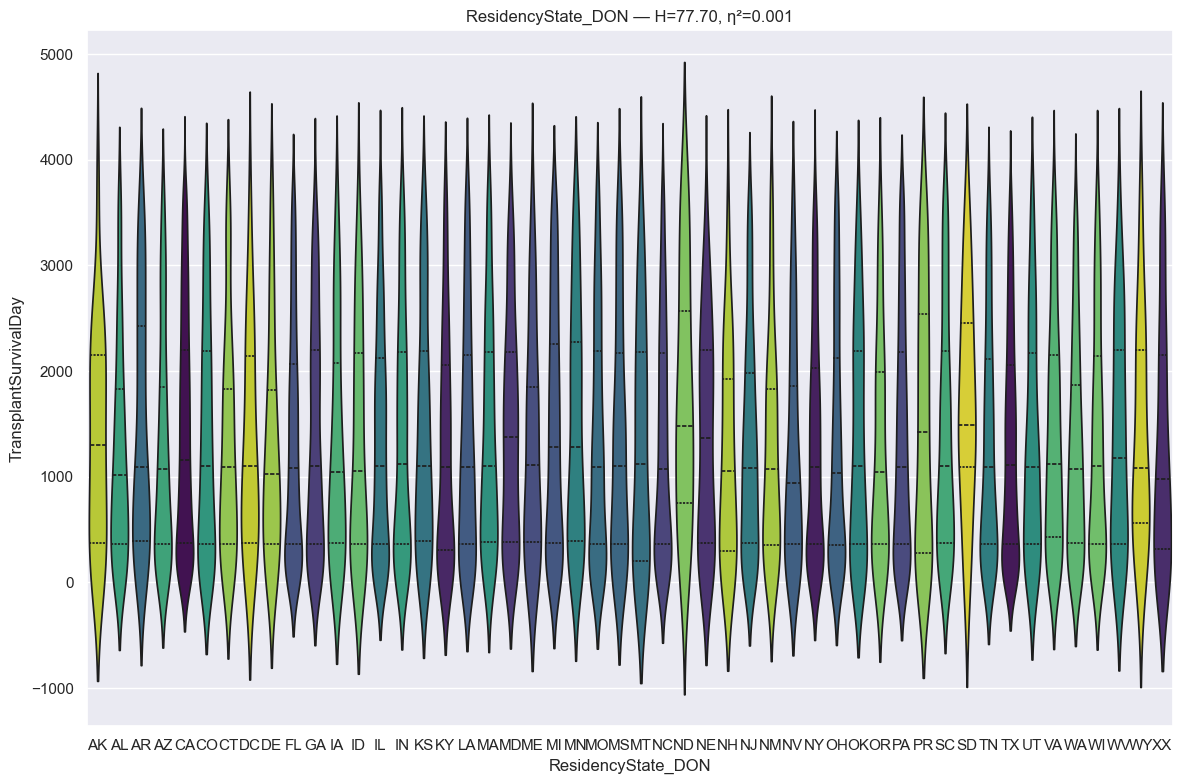

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AK                                                :     47 records
 * AL                                                :    282 records
 * AR                                                :    202 records
 * AZ                                                :    488 records
 * CA                                                :   2183 records
 * CO                                                :    336 records
 * CT                                                :    193 records
 * DC                                                :     37 records
 * DE                                                :     99 records
 * FL                                                :   1276 records
 * GA                                                :    630 records
 * IA                                                :    154 records
 * ID                                                :     94 records
 * IL                    

In [78]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [79]:
# instantiate class (more relaxed)
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",         # bonferroni, Holm-Bonferroni (holm), Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: ResidencyState_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * AK                                                :     47 records
 * AL                                                :    282 records
 * AR                                                :    202 records
 * AZ                                                :    488 records
 * CA                                                :   2183 records
 * CO                                                :    336 records
 * CT                                                :    193 records
 * DC                                                :     37 records
 * DE                                                :     99 records
 * FL                                                :   1276 records
 * GA                                                :    630 records
 * IA                                                :    154 records
 * ID                                                :     94 records
 * IL                    

In [80]:
# Pairwise Testing significance
sum(d['sig'] for d in results['pairwise'])

0

In [81]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Antibody HEP C

In [82]:
# info
features = u.get_feature_info(df, 'Antibody_HEP_C', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique       top   freq
Antibody_HEP_C_DON  20007      5  Negative  19047

:::: NaN Count:
Antibody_HEP_C_DON    0 



{'Antibody_HEP_C_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive'],
 , ordered=False, categories_dtype=object)}

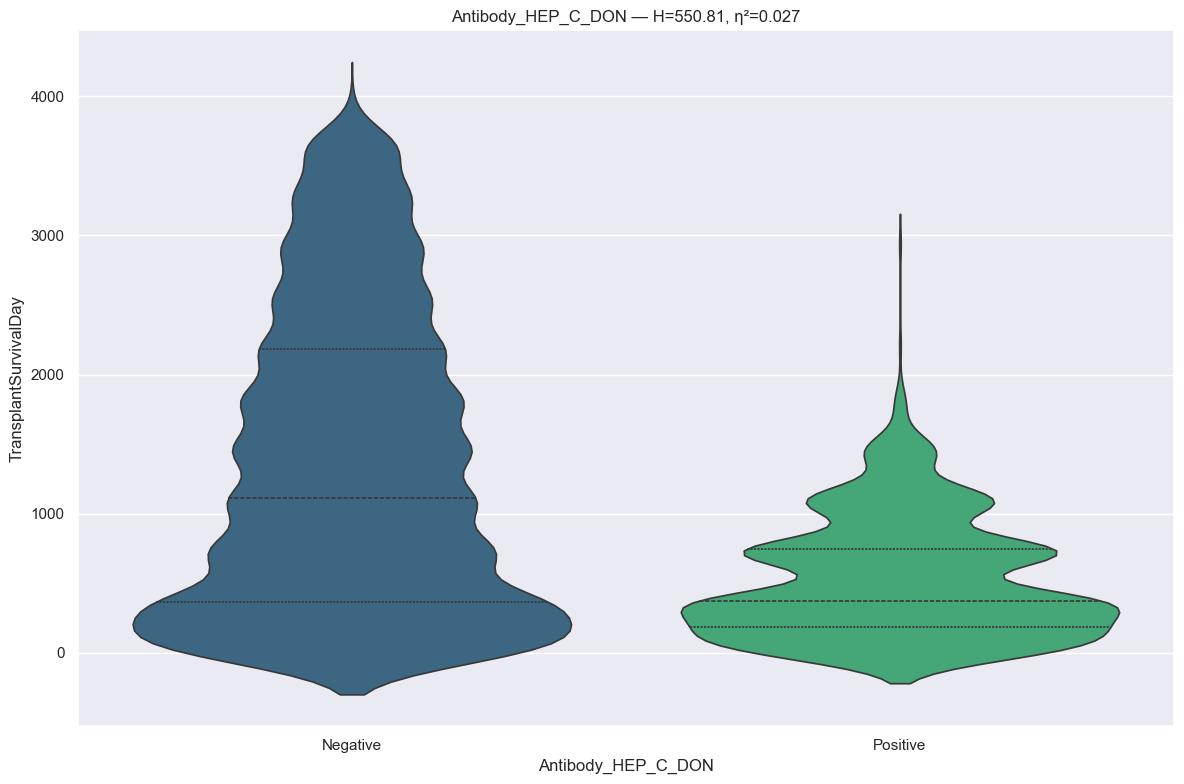

RANKING REPORT: Antibody_HEP_C_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :  19047 records
 * Positive                                          :    956 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :      1 records
 * Missing                                           :      2 records
 * Pending                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 550.8052 | P-value: 8.410624e-122 | Effect η²: 0.0275
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Positive     | p=8.4112e-122 | thr=0.0500 | r=-0.449 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [83]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [84]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1', 'Positive': 'Group_2', 'Indeterminate': 'Other', 'Missing': 'Other', 'Pending': 'Other'}


,Antibody_HEP_C_DON,mean_survival_days,record_count
2,Negative,1366.612957,19047
4,Positive,533.234310,956
1,Missing,769.000000,2
0,Indeterminate,68.000000,1
3,Pending,2231.000000,1


In [85]:
# mapping (small sample size)
mapping = {'Missing': 'Other',
           'Indeterminate': 'Other',
           'Pending': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,Antibody_HEP_C_DON,mean_survival_days,record_count
0,Negative,1366.612957,19047
2,Positive,533.234310,956
1,Other,959.250000,4


#### Non Heart Beating

In [86]:
# info
features = u.get_feature_info(df, 'NonHeartBeating', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique top   freq
NonHeartBeating_DON  20007      3  No  19766

:::: NaN Count:
NonHeartBeating_DON    0 



{'NonHeartBeating_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

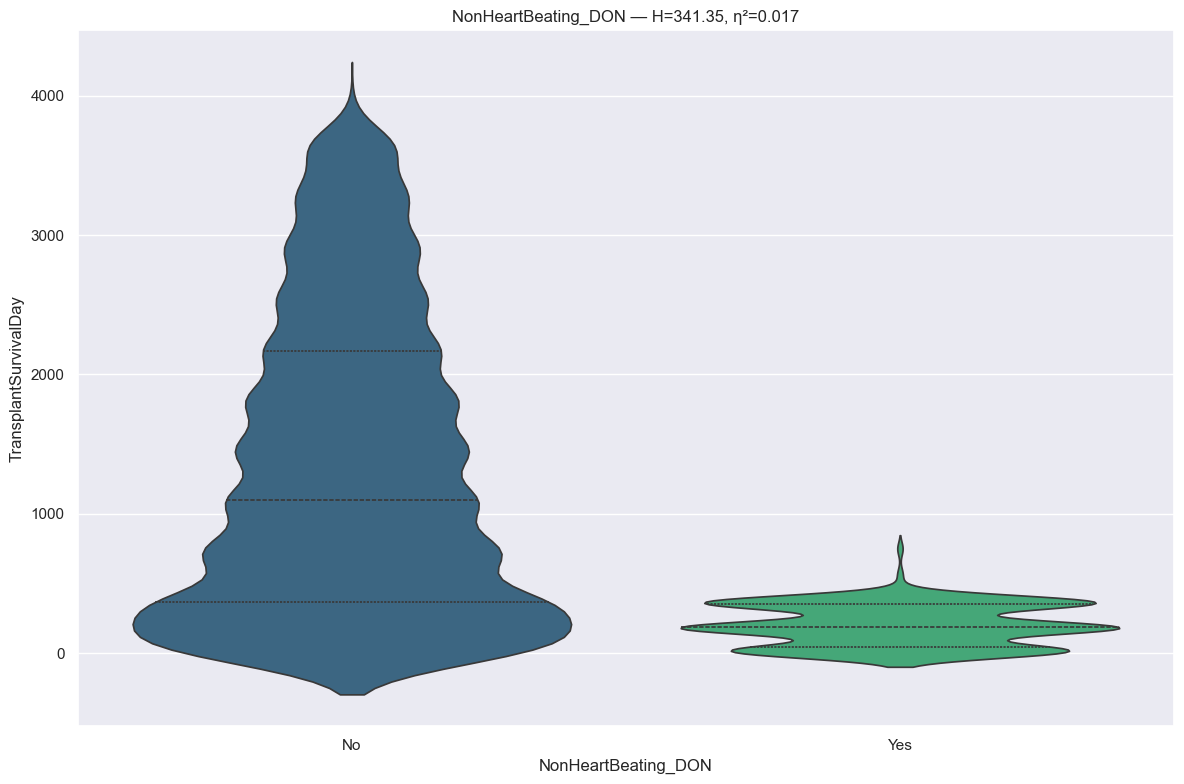

RANKING REPORT: NonHeartBeating_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19766 records
 * Yes                                               :    237 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 341.3466 | P-value: 3.247908e-76 | Effect η²: 0.0170
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.2482e-76 | thr=0.0500 | r=-0.697 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [87]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [88]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,NonHeartBeating_DON,mean_survival_days,record_count
1,No,1340.228726,19766
2,Yes,203.000000,237
0,Missing,1103.500000,4


#### Anti Hypertensive

In [89]:
# info
features = u.get_feature_info(df, 'AntiHypertensive_DON', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique top   freq
AntiHypertensive_DON  20007      4  No  13411

:::: NaN Count:
AntiHypertensive_DON    0 



{'AntiHypertensive_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

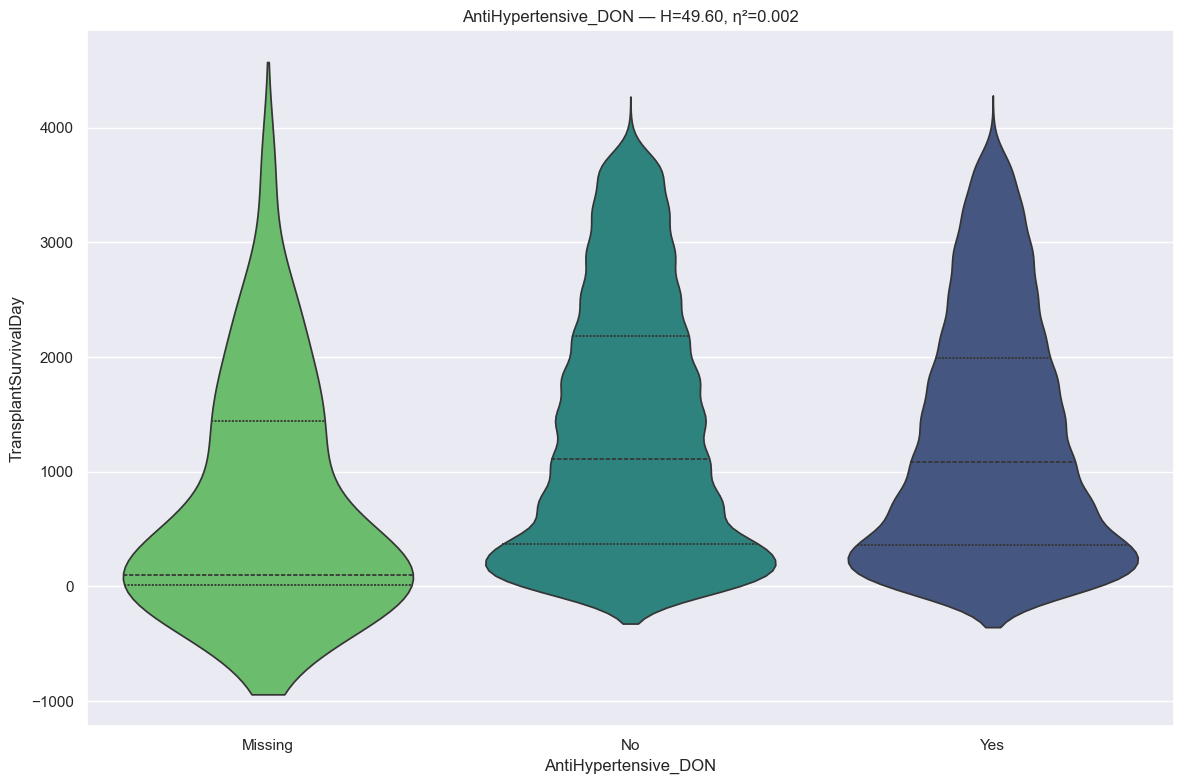

RANKING REPORT: AntiHypertensive_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  13411 records
 * Yes                                               :   6551 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 49.5977 | P-value: 1.698209e-11 | Effect η²: 0.0024
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.2798e-08 | thr=0.0167 | r=-0.048 | *Sig*
Missing      vs No           | p=5.7943e-06 | thr=0.0167 | r= 0.425 | *Sig*
Missing      vs Yes          | p=2.6309e-05 | thr=0.0167 | r= 0.395 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [90]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [91]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,AntiHypertensive_DON,mean_survival_days,record_count
1,No,1361.092312,13411
3,Yes,1259.841704,6551
0,Missing,737.078947,38
2,Unknown,1235.000000,7


In [92]:
# mapping
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = df[features[0]].map(mapping).fillna(df[features[0]])
# sanity check
mean_survival_by_category(df, features[0])

,AntiHypertensive_DON,mean_survival_days,record_count
0,No,1361.092312,13411
2,Yes,1259.841704,6551
1,Other,814.533333,45


#### Blood Infection Source

In [93]:
# info
features = u.get_feature_info(df, 'BloodInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in features}

                          count unique top   freq
BloodInfectionSource_DON  20007      3  No  18052

:::: NaN Count:
BloodInfectionSource_DON    0 



{'BloodInfectionSource_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

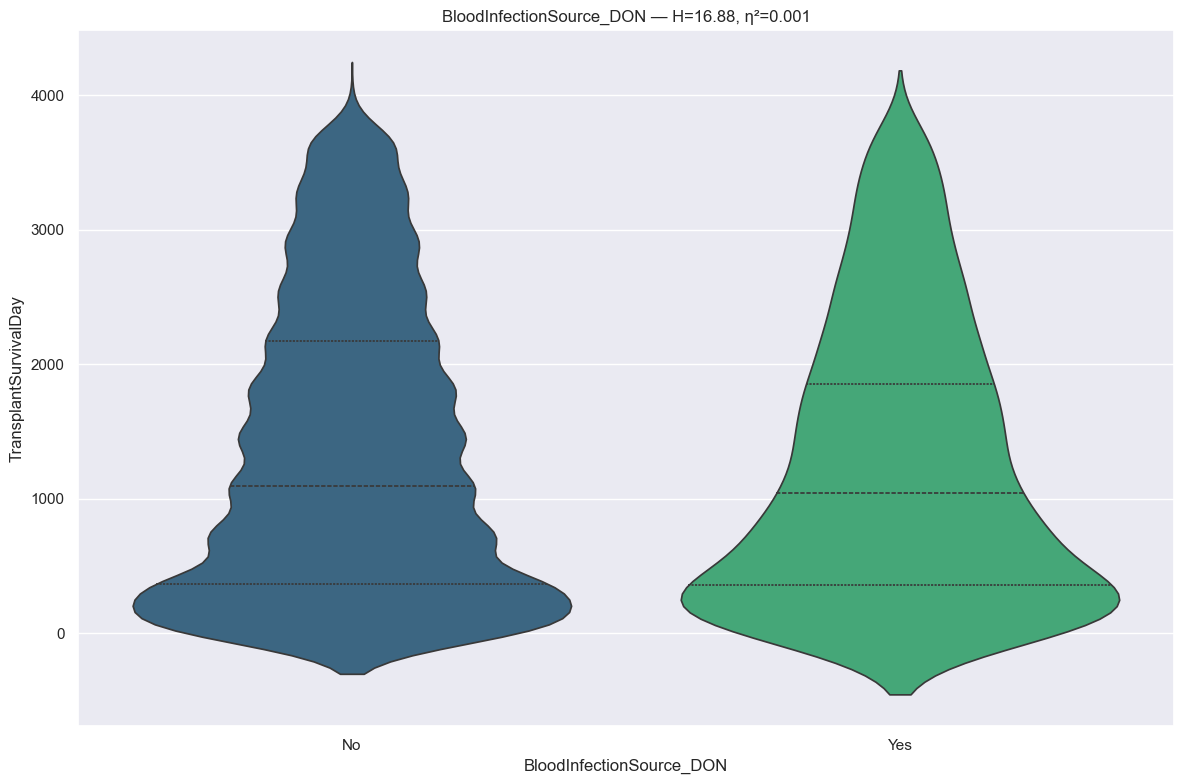

RANKING REPORT: BloodInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  18052 records
 * Yes                                               :   1953 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 16.8812 | P-value: 3.979412e-05 | Effect η²: 0.0008
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.9794e-05 | thr=0.0500 | r=-0.057 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [94]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [95]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,BloodInfectionSource_DON,mean_survival_days,record_count
1,No,1337.368048,18052
2,Yes,1228.766001,1953
0,Missing,769.000000,2


#### OtherInfectionSource_DON

In [96]:
# info
features = u.get_feature_info(df, 'OtherInfectionSource', cat=False)
# dtype
{col: df[col].dtype for col in features}

                          count unique top   freq
OtherInfectionSource_DON  20007      3  No  13826

:::: NaN Count:
OtherInfectionSource_DON    0 



{'OtherInfectionSource_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

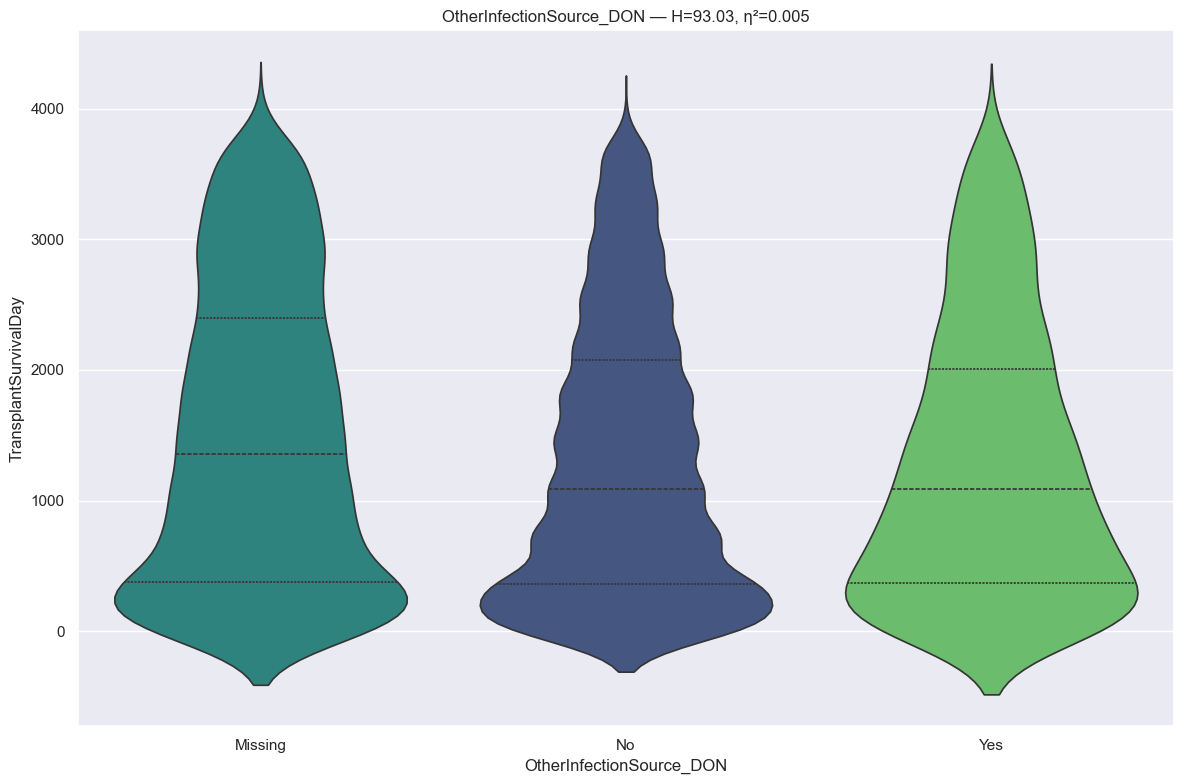

RANKING REPORT: OtherInfectionSource_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   4763 records
 * No                                                :  13826 records
 * Yes                                               :   1418 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 93.0341 | P-value: 6.279175e-21 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=3.4071e-21 | thr=0.0167 | r=-0.092 | *Sig*
Missing      vs Yes          | p=1.4604e-08 | thr=0.0167 | r=-0.099 | *Sig*
No           vs Yes          | p=6.5624e-01 | thr=0.0167 | r=-0.007 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [97]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [98]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_2'}


,OtherInfectionSource_DON,mean_survival_days,record_count
1,No,1283.638073,13826
0,Missing,1469.604661,4763
2,Yes,1266.698872,1418


#### Diuretics

In [99]:
# info
features = u.get_feature_info(df, 'Diuretics', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique  top   freq
Diuretics_DON  20007      4  Yes  13904

:::: NaN Count:
Diuretics_DON    0 



{'Diuretics_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

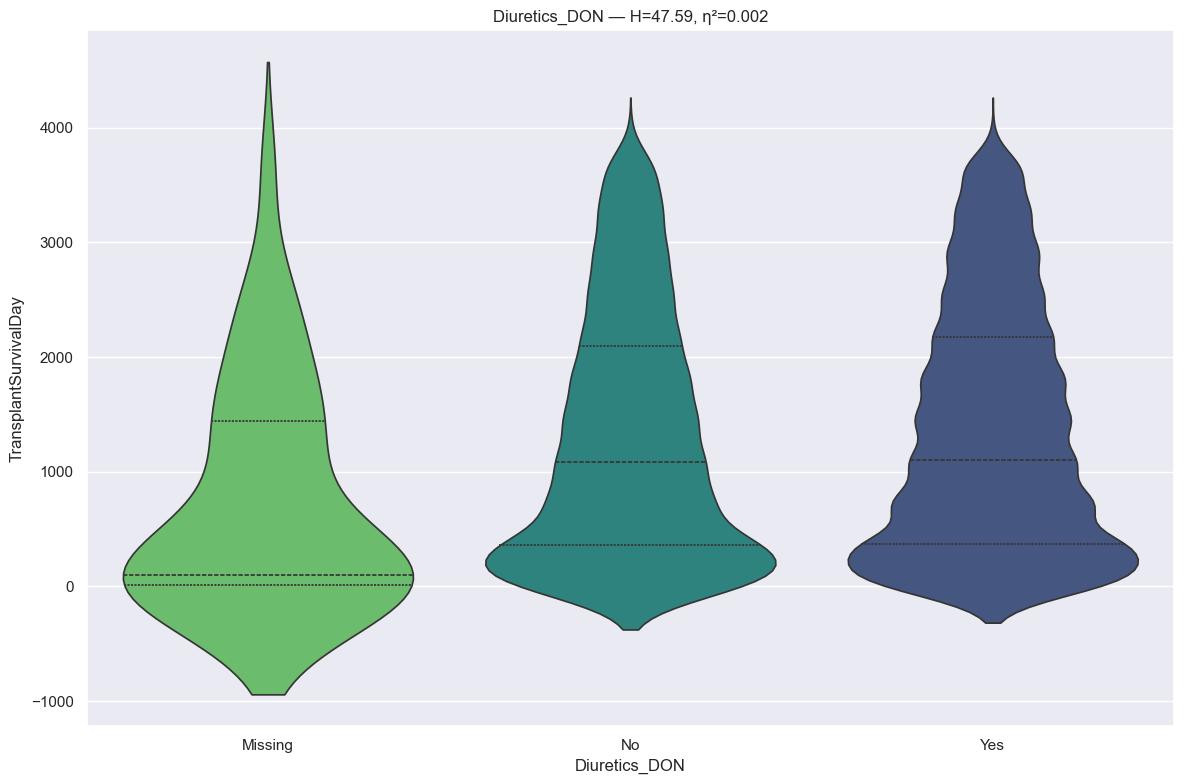

RANKING REPORT: Diuretics_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   6061 records
 * Yes                                               :  13904 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 47.5900 | P-value: 4.633986e-11 | Effect η²: 0.0023
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.2068e-07 | thr=0.0167 | r= 0.047 | *Sig*
Missing      vs Yes          | p=5.9832e-06 | thr=0.0167 | r= 0.425 | *Sig*
Missing      vs No           | p=2.7832e-05 | thr=0.0167 | r= 0.394 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [100]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [101]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,Diuretics_DON,mean_survival_days,record_count
3,Yes,1350.236982,13904
1,No,1276.136281,6061
0,Missing,737.078947,38
2,Unknown,1780.000000,4


In [102]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,Diuretics_DON,mean_survival_days,record_count
2,Yes,1350.236982,13904
0,No,1276.136281,6061
1,Other,836.404762,42


#### Steroids Use

In [103]:
# info
features = u.get_feature_info(df, 'SteroidsUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

                 count unique  top   freq
SteroidsUse_DON  20007      4  Yes  14208

:::: NaN Count:
SteroidsUse_DON    0 



{'SteroidsUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

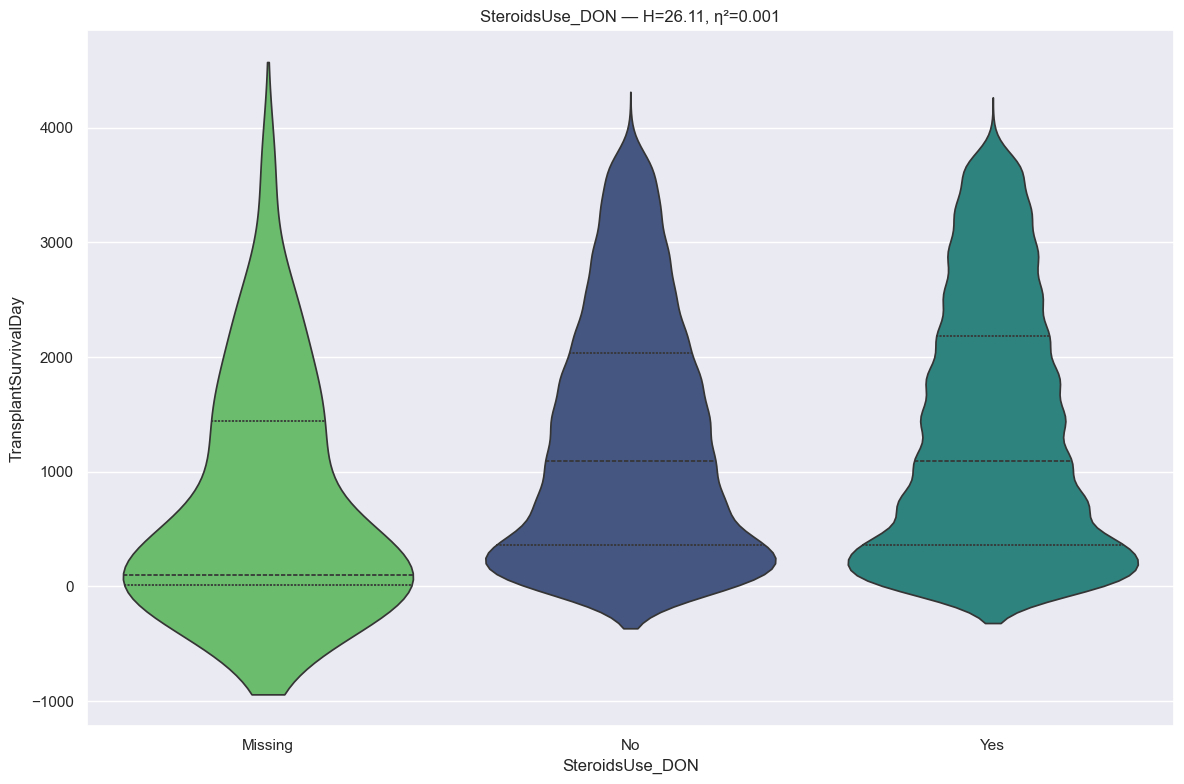

RANKING REPORT: SteroidsUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   5747 records
 * Yes                                               :  14208 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     14 records
--------------------------------------------------------------------------------
Kruskal H: 26.1129 | P-value: 2.136296e-06 | Effect η²: 0.0012
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=7.8928e-06 | thr=0.0167 | r= 0.419 | *Sig*
Missing      vs No           | p=1.5739e-05 | thr=0.0167 | r= 0.406 | *Sig*
No           vs Yes          | p=1.0751e-02 | thr=0.0167 | r= 0.023 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [104]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [105]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,SteroidsUse_DON,mean_survival_days,record_count
3,Yes,1344.670045,14208
1,No,1285.896816,5747
0,Missing,737.078947,38
2,Unknown,1454.000000,14


In [106]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,SteroidsUse_DON,mean_survival_days,record_count
2,Yes,1344.670045,14208
0,No,1285.896816,5747
1,Other,930.096154,52


#### Triiodothyronine T3

In [107]:
# info
features = u.get_feature_info(df, 'TriiodothyronineT3', cat=False)
# dtype
{col: df[col].dtype for col in features}

                        count unique top   freq
TriiodothyronineT3_DON  20007      4  No  19879

:::: NaN Count:
TriiodothyronineT3_DON    0 



{'TriiodothyronineT3_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

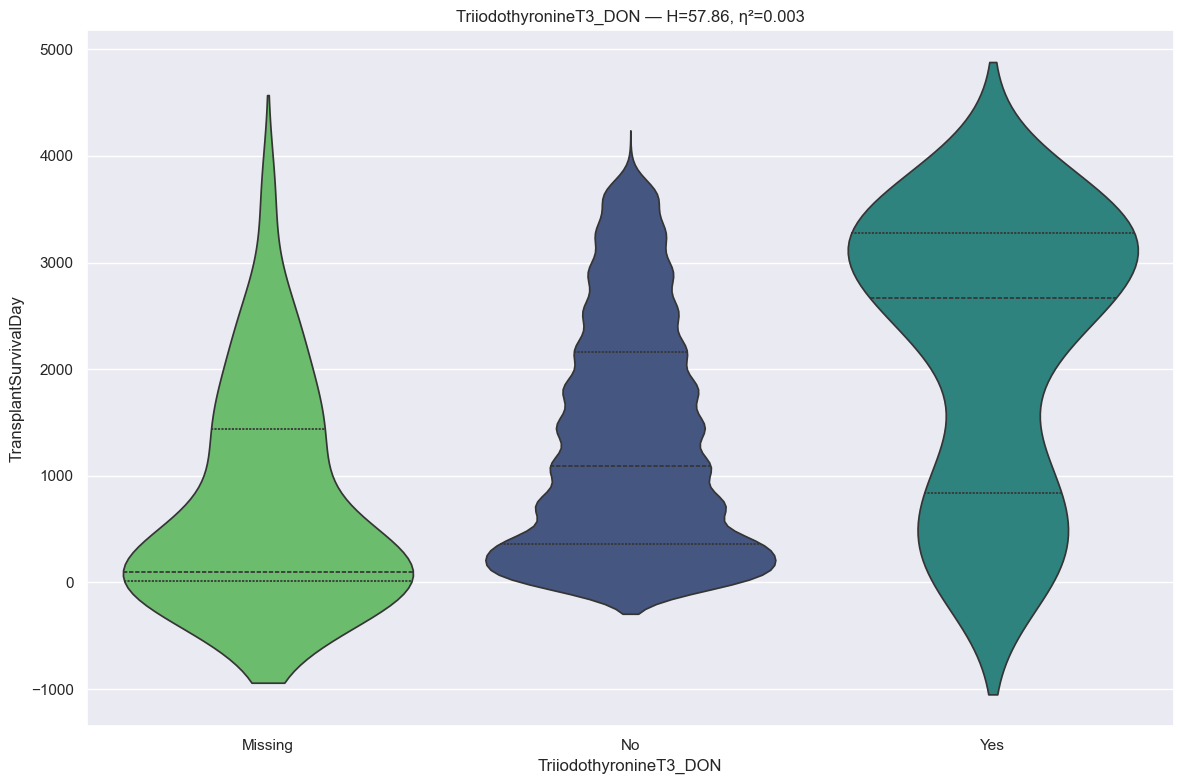

RANKING REPORT: TriiodothyronineT3_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19879 records
 * Yes                                               :     85 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      5 records
--------------------------------------------------------------------------------
Kruskal H: 57.8649 | P-value: 2.721383e-13 | Effect η²: 0.0028
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.0448e-10 | thr=0.0167 | r= 0.388 | *Sig*
Missing      vs Yes          | p=1.3734e-08 | thr=0.0167 | r= 0.642 | *Sig*
Missing      vs No           | p=9.9242e-06 | thr=0.0167 | r= 0.414 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [108]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [109]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,TriiodothyronineT3_DON,mean_survival_days,record_count
1,No,1324.080738,19879
3,Yes,2195.600000,85
0,Missing,737.078947,38
2,Unknown,1490.000000,5


In [110]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,TriiodothyronineT3_DON,mean_survival_days,record_count
0,No,1324.080738,19879
2,Yes,2195.600000,85
1,Other,824.627907,43


#### Thyroxine T4

In [111]:
# info
features = u.get_feature_info(df, 'ThyroxineT4', cat=False)
# dtype
{col: df[col].dtype for col in features}

                 count unique  top   freq
ThyroxineT4_DON  20007      4  Yes  13263

:::: NaN Count:
ThyroxineT4_DON    0 



{'ThyroxineT4_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

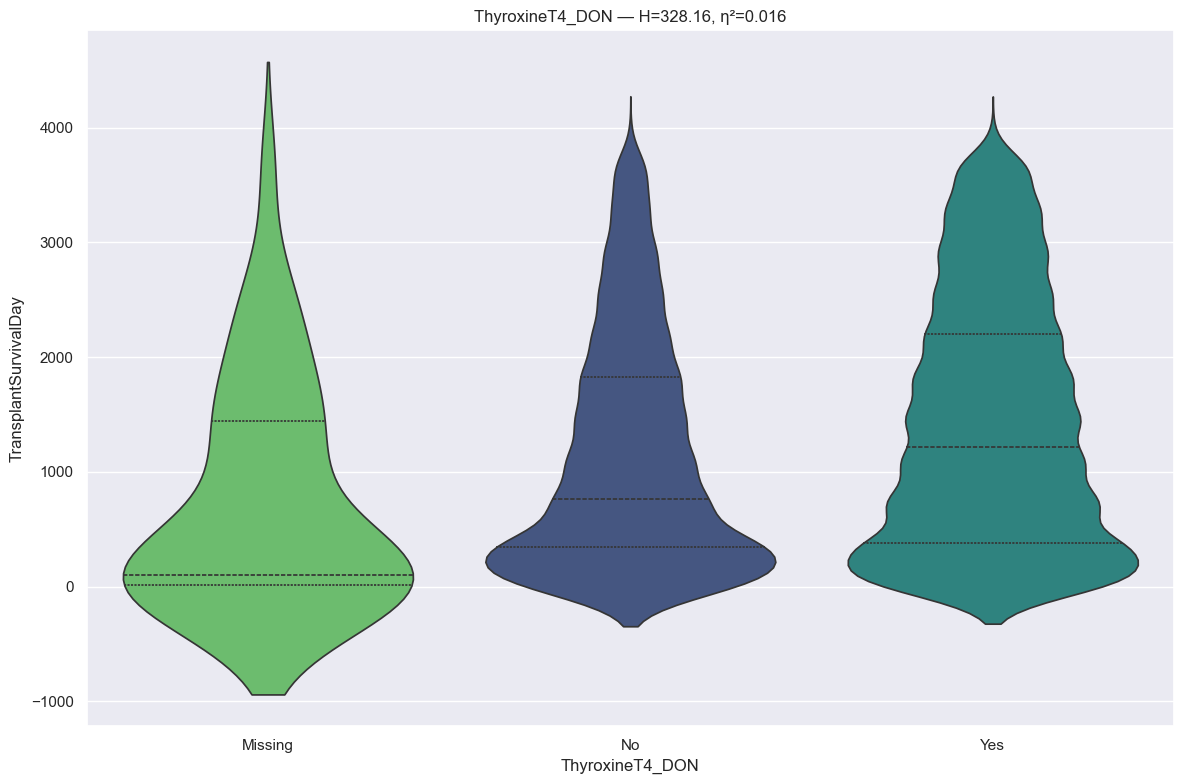

RANKING REPORT: ThyroxineT4_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   6703 records
 * Yes                                               :  13263 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 328.1611 | P-value: 5.504492e-72 | Effect η²: 0.0163
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=3.6690e-69 | thr=0.0167 | r= 0.152 | *Sig*
Missing      vs Yes          | p=1.8005e-06 | thr=0.0167 | r= 0.448 | *Sig*
Missing      vs No           | p=1.8807e-04 | thr=0.0167 | r= 0.351 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [112]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [113]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,ThyroxineT4_DON,mean_survival_days,record_count
3,Yes,1421.726985,13263
1,No,1142.193645,6703
0,Missing,737.078947,38
2,Unknown,996.000000,3


In [114]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,ThyroxineT4_DON,mean_survival_days,record_count
2,Yes,1421.726985,13263
0,No,1142.193645,6703
1,Other,756.024390,41


#### Pulmonary Infection

In [115]:
# info
features = u.get_feature_info(df, 'PulmonaryInfection', cat=False)
# dtype
{col: df[col].dtype for col in features}

                        count unique  top   freq
PulmonaryInfection_DON  20007      3  Yes  14217

:::: NaN Count:
PulmonaryInfection_DON    0 



{'PulmonaryInfection_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

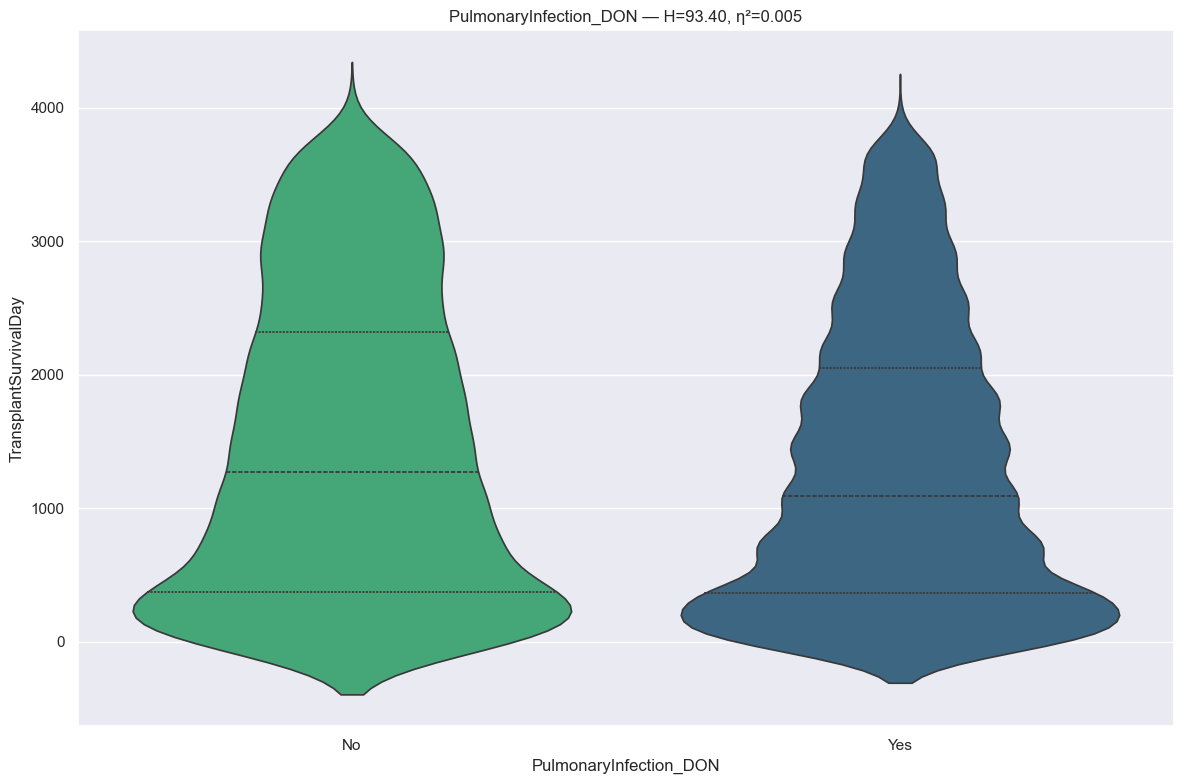

RANKING REPORT: PulmonaryInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   5788 records
 * Yes                                               :  14217 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 93.4044 | P-value: 4.263021e-22 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.2631e-22 | thr=0.0500 | r=-0.087 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [116]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [117]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,PulmonaryInfection_DON,mean_survival_days,record_count
2,Yes,1275.535837,14217
1,No,1452.601071,5788
0,Missing,769.000000,2


#### Urine Infection

In [118]:
# info
features = u.get_feature_info(df, 'UrineInfection', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique top   freq
UrineInfection_DON  20007      3  No  18800

:::: NaN Count:
UrineInfection_DON    0 



{'UrineInfection_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

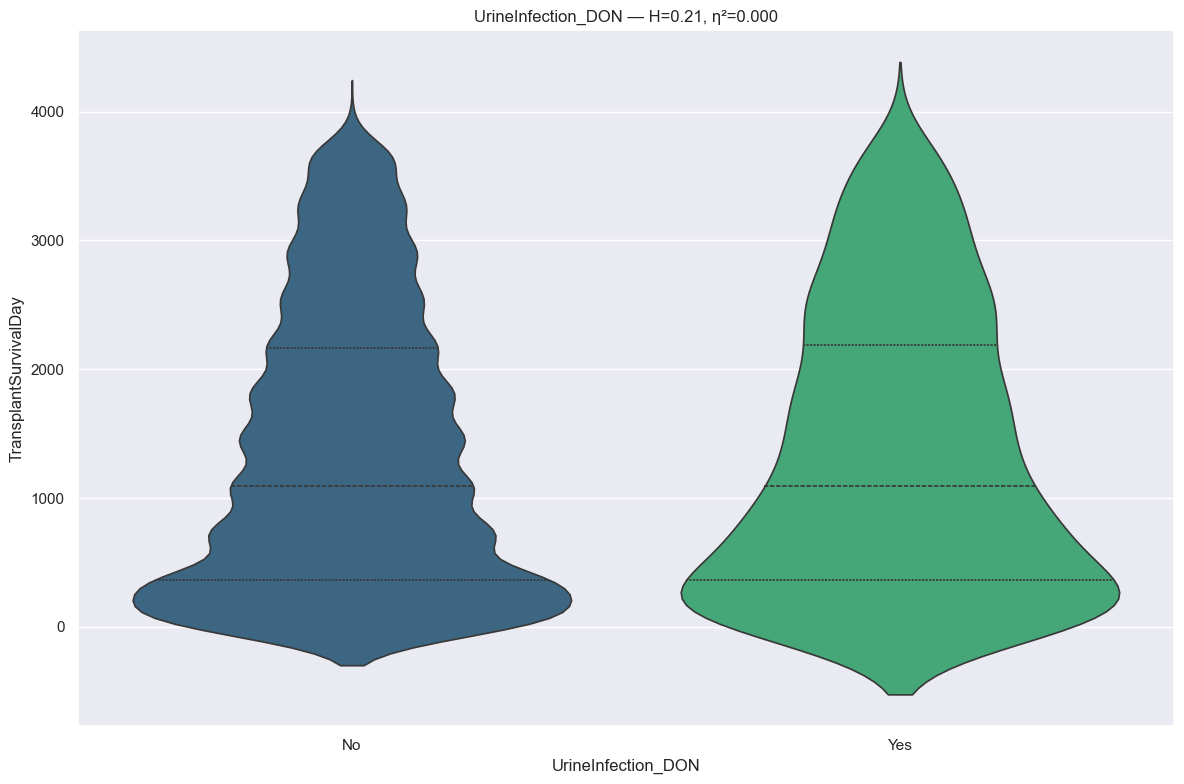

RANKING REPORT: UrineInfection_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  18800 records
 * Yes                                               :   1205 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 0.2146 | P-value: 6.431920e-01 | Effect η²: 0.0000
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.4319e-01 | thr=0.0500 | r=-0.008 | Not Sig
::::: Collapsed into 1 groups (excluding 'Other') :::::



In [119]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [120]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Missing': 'Other'}


,UrineInfection_DON,mean_survival_days,record_count
1,No,1327.029574,18800
2,Yes,1322.648963,1205
0,Missing,769.000000,2


#### Vasodilators

In [121]:
# info
features = u.get_feature_info(df, 'Vasodilators', cat=False)
# dtype
{col: df[col].dtype for col in features}

                  count unique top   freq
Vasodilators_DON  20007      4  No  16687

:::: NaN Count:
Vasodilators_DON    0 



{'Vasodilators_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

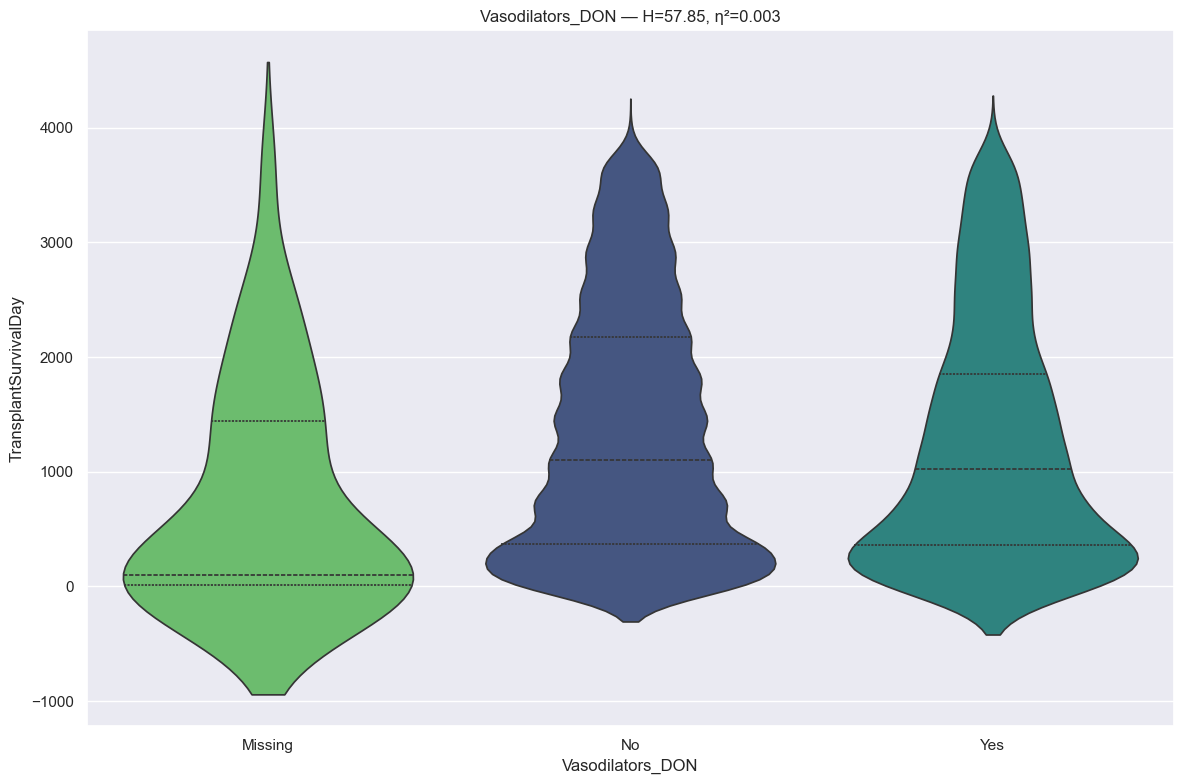

RANKING REPORT: Vasodilators_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  16687 records
 * Yes                                               :   3276 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      6 records
--------------------------------------------------------------------------------
Kruskal H: 57.8468 | P-value: 2.746140e-13 | Effect η²: 0.0028
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=6.1233e-10 | thr=0.0167 | r=-0.068 | *Sig*
Missing      vs No           | p=6.7117e-06 | thr=0.0167 | r= 0.422 | *Sig*
Missing      vs Yes          | p=5.5213e-05 | thr=0.0167 | r= 0.380 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [122]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [123]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,Vasodilators_DON,mean_survival_days,record_count
1,No,1347.535267,16687
3,Yes,1227.838217,3276
0,Missing,737.078947,38
2,Unknown,1126.333333,6


In [124]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,Vasodilators_DON,mean_survival_days,record_count
0,No,1347.535267,16687
2,Yes,1227.838217,3276
1,Other,790.159091,44


#### Antibody Result RPR VDRL

In [125]:
# info
features = u.get_feature_info(df, 'AntibodyResultRPR_VDRL', cat=False)
# dtype
{col: df[col].dtype for col in features}

                            count unique       top   freq
AntibodyResultRPR_VDRL_DON  20007      4  Negative  19475

:::: NaN Count:
AntibodyResultRPR_VDRL_DON    0 



{'AntibodyResultRPR_VDRL_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Positive'], ordered=False, categories_dtype=object)}

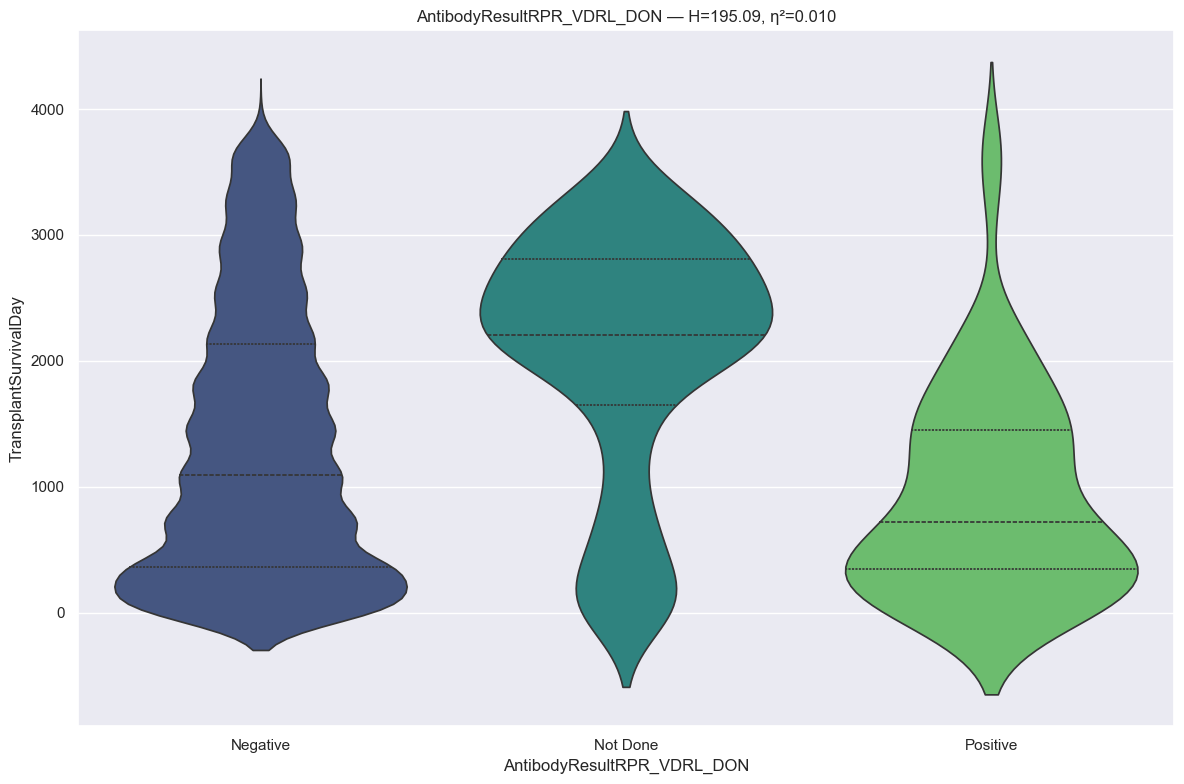

RANKING REPORT: AntibodyResultRPR_VDRL_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Negative                                          :  19475 records
 * Not Done                                          :    408 records
 * Positive                                          :    111 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     13 records
--------------------------------------------------------------------------------
Kruskal H: 195.0874 | P-value: 4.338136e-43 | Effect η²: 0.0097
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=3.1436e-41 | thr=0.0167 | r= 0.388 | *Sig*
Not Done     vs Positive     | p=1.5589e-22 | thr=0.0167 | r=-0.604 | *Sig*
Negative     vs Positive     | p=3.0871e-04 | thr=0.0167 | r=-0.198 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [126]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [127]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Negative': 'Group_1', 'Not Done': 'Group_2', 'Positive': 'Group_3', 'Missing': 'Other'}


,AntibodyResultRPR_VDRL_DON,mean_survival_days,record_count
1,Negative,1313.857099,19475
2,Not Done,2053.666667,408
3,Positive,920.756757,111
0,Missing,1232.230769,13


#### Infection Clinical

In [128]:
# info
features = u.get_feature_info(df, 'InfectionClinical', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique  top   freq
InfectionClinical_DON  20007      4  Yes  15244

:::: NaN Count:
InfectionClinical_DON    0 



{'InfectionClinical_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

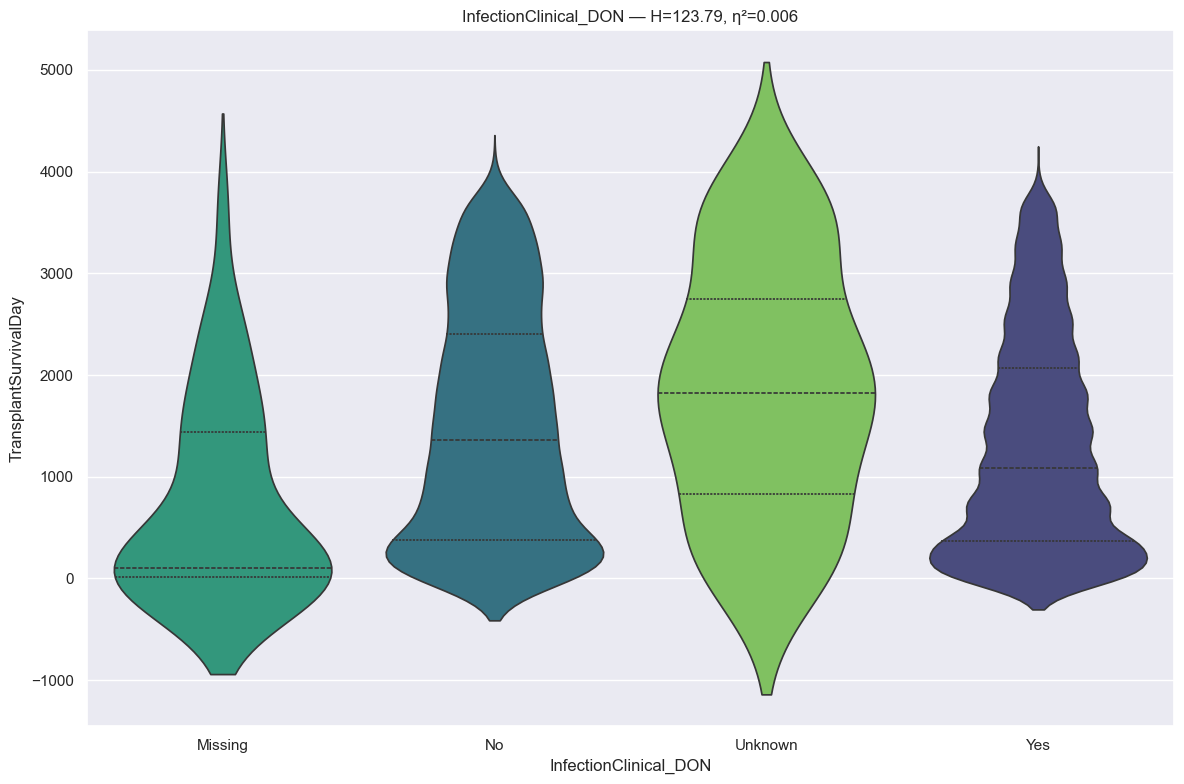

RANKING REPORT: InfectionClinical_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   4683 records
 * Unknown                                           :     42 records
 * Yes                                               :  15244 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 123.7855 | P-value: 1.180480e-26 | Effect η²: 0.0060
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=9.1588e-23 | thr=0.0083 | r=-0.095 | *Sig*
Missing      vs No           | p=9.2602e-07 | thr=0.0083 | r= 0.461 | *Sig*
Missing      vs Unknown      | p=9.5163e-06 | thr=0.0083 | r= 0.576 | *Sig*
Missing      vs Yes          | p=1.9387e-05 | thr=0.0083 | r= 0.401 | *Sig*
Un

In [129]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [130]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Unknown': 'Group_3', 'Yes': 'Group_4'}


,InfectionClinical_DON,mean_survival_days,record_count
3,Yes,1282.062385,15244
1,No,1472.134956,4683
2,Unknown,1850.238095,42
0,Missing,737.078947,38


#### Cocaine Use

In [131]:
# info
features = u.get_feature_info(df, 'CocaineUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique      top   freq
CocaineUse_DON      20007      4  Missing  15362
PastCocaineUse_DON  20007      4       No  14941

:::: NaN Count:
CocaineUse_DON        0
PastCocaineUse_DON    0 



{'CocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object),
 'PastCocaineUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

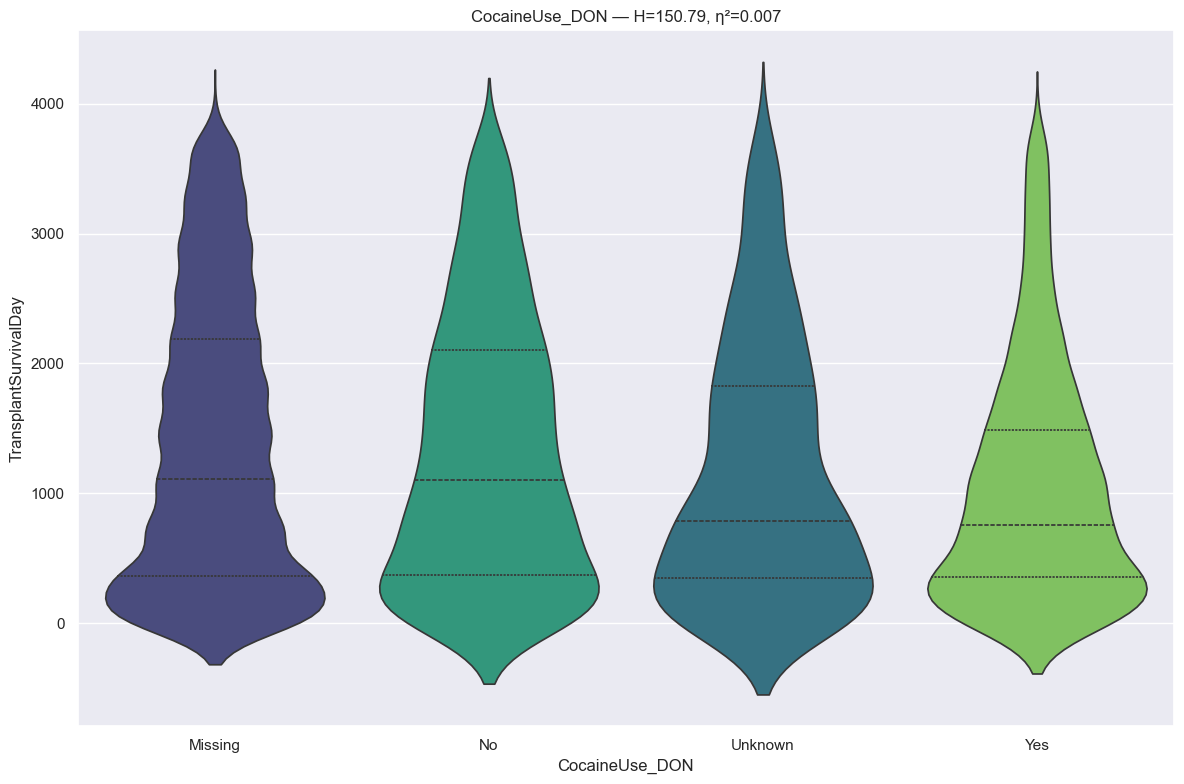

RANKING REPORT: CocaineUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :  15362 records
 * No                                                :   1614 records
 * Unknown                                           :    627 records
 * Yes                                               :   2404 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 150.7909 | P-value: 1.778885e-32 | Effect η²: 0.0074
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=3.3362e-31 | thr=0.0083 | r=-0.147 | *Sig*
No           vs Yes          | p=2.0674e-12 | thr=0.0083 | r=-0.131 | *Sig*
Missing      vs Unknown      | p=3.0617e-06 | thr=0.0083 | r=-0.110 | *Sig*
No           vs Unknown      | p=8.3449e-04 | thr=0.0083 | r=-0.091 | *Sig*
Missing  

In [132]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [133]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_1', 'Unknown': 'Group_2', 'Yes': 'Group_2'}


,CocaineUse_DON,mean_survival_days,record_count
0,Missing,1375.451634,15362
3,Yes,1070.467970,2404
1,No,1310.149318,1614
2,Unknown,1157.594896,627


#### Other Drug Use

In [134]:
# info
features = u.get_feature_info(df, 'OtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique  top   freq
OtherDrugUse_DON      20007      4  Yes   9051
PastOtherDrugUse_DON  20007      4  Yes  11850

:::: NaN Count:
OtherDrugUse_DON        0
PastOtherDrugUse_DON    0 



{'OtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object),
 'PastOtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

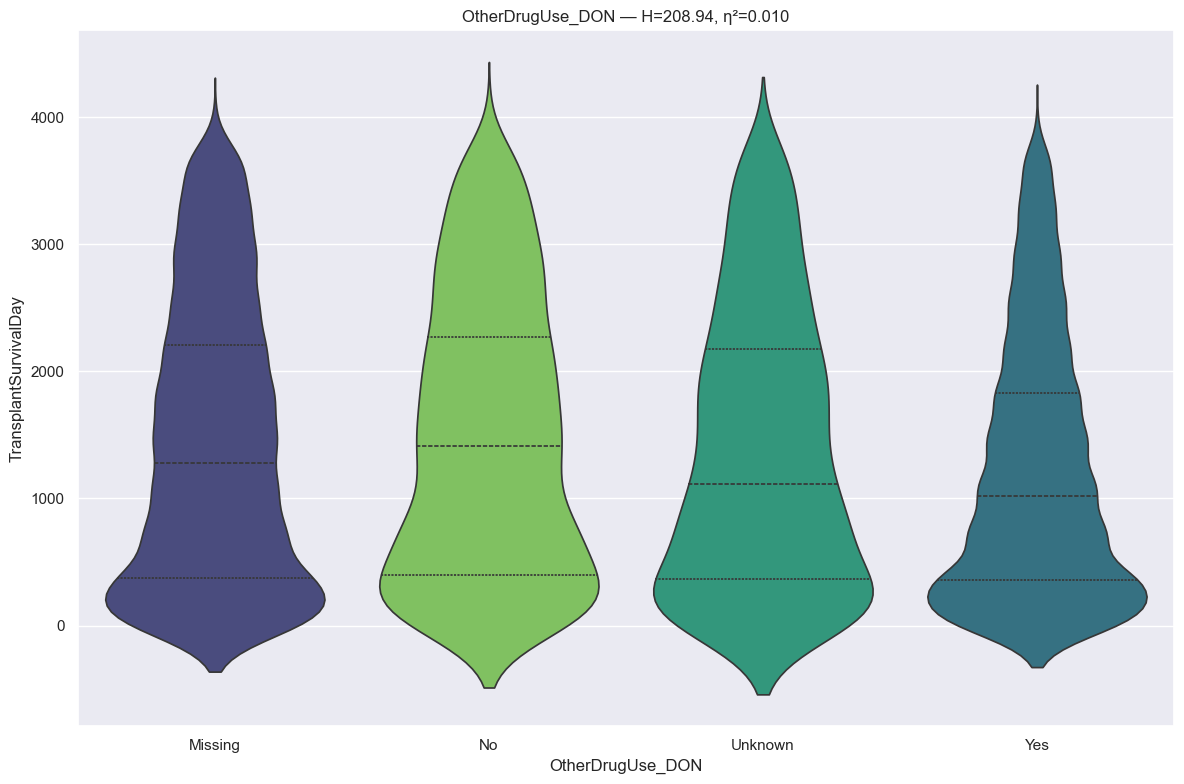

RANKING REPORT: OtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   8157 records
 * No                                                :   1784 records
 * Unknown                                           :   1015 records
 * Yes                                               :   9051 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 208.9391 | P-value: 4.936967e-45 | Effect η²: 0.0103
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Yes          | p=1.9311e-38 | thr=0.0083 | r=-0.114 | *Sig*
No           vs Yes          | p=4.0483e-22 | thr=0.0083 | r=-0.145 | *Sig*
Unknown      vs Yes          | p=7.0097e-06 | thr=0.0083 | r=-0.086 | *Sig*
No           vs Unknown      | p=1.2571e-02 | thr=0.0083 | r=-0.057 | Not Sig
Missi

In [135]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [136]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_1', 'Unknown': 'Group_1', 'Yes': 'Group_2'}


,OtherDrugUse_DON,mean_survival_days,record_count
3,Yes,1200.408574,9051
0,Missing,1428.825916,8157
1,No,1475.841368,1784
2,Unknown,1370.200985,1015


#### Cancer ExtraCranial

In [137]:
# info
features = u.get_feature_info(df, 'CancerExtraCranial', cat=False)
# dtype
{col: df[col].dtype for col in features}

                        count unique top   freq
CancerExtraCranial_DON  20007      4  No  19807

:::: NaN Count:
CancerExtraCranial_DON    0 



{'CancerExtraCranial_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

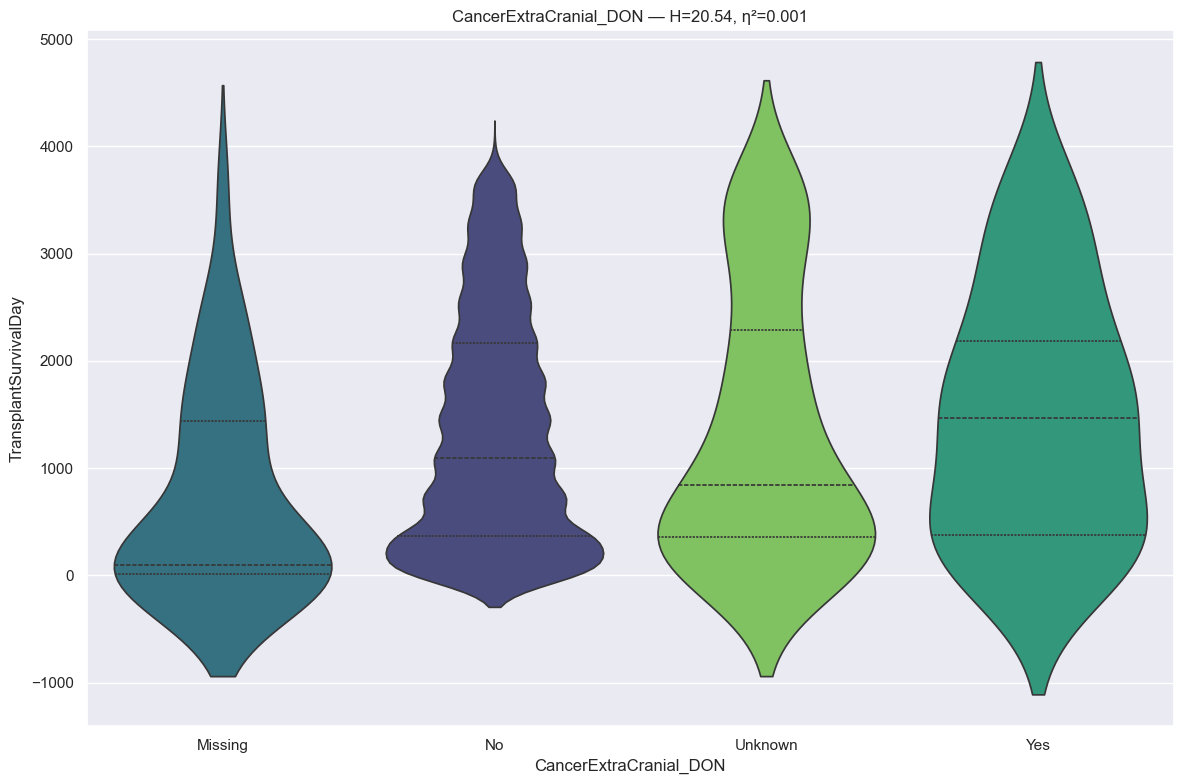

RANKING REPORT: CancerExtraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19807 records
 * Unknown                                           :    127 records
 * Yes                                               :     35 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 20.5365 | P-value: 1.313860e-04 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=9.3417e-06 | thr=0.0083 | r= 0.415 | *Sig*
Missing      vs Yes          | p=4.7293e-04 | thr=0.0083 | r= 0.477 | *Sig*
Missing      vs Unknown      | p=7.6439e-04 | thr=0.0083 | r= 0.361 | *Sig*
Unknown      vs Yes          | p=3.8158e-01 | thr=0.0083 | r= 0.097 | Not Sig


In [138]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [139]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Unknown': 'Group_2', 'Yes': 'Group_2'}


,CancerExtraCranial_DON,mean_survival_days,record_count
1,No,1327.481698,19807
2,Unknown,1340.385827,127
0,Missing,737.078947,38
3,Yes,1480.514286,35


#### Cancer Site

In [140]:
# info
features = u.get_feature_info(df, 'CancerSite', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top   freq
CancerSite_DON  20007     19  NO  19700

:::: NaN Count:
CancerSite_DON    0 



{'CancerSite_DON': CategoricalDtype(categories=['BREAST', 'CNS TUMOR - ASTROCYTOMA',
                   'CNS TUMOR - GLIOBLASTOMA MULTIFORME',
                   'CNS TUMOR - MEDULLOBLASTOMA', 'CNS TUMOR - MENINGIOMA',
                   'CNS TUMOR - NEUROBLASTOMA', 'CNS TUMOR - OTHER',
                   'GASTROINTESTINAL - COLO-RECTAL',
                   'GASTROINTESTINAL - STOMACH', 'GENITOURINARY - BLADDER',
                   'GENITOURINARY - KIDNEY', 'GENITOURINARY - OVARIAN',
                   'GENITOURINARY - PENIS, TESTICULAR',
                   'GENITOURINARY - PROSTATE', 'GENITOURINARY - UNKNOWN',
                   'GENITOURINARY - UTERINE BODY CHORIOCARCINOMA',
                   'GENITOURINARY - UTERINE BODY ENDOMETRIAL',
                   'GENITOURINARY - UTERINE CERVIX', 'GENITOURINARY - VULVA',
                   'LEUKEMIA/LYMPHOMA', 'Missing', 'NO', 'OTHER, SPECIFY',
                   'SKIN - MELANOMA', 'SKIN - SQUAMOUS, BASAL CELL', 'THYROID',
                  

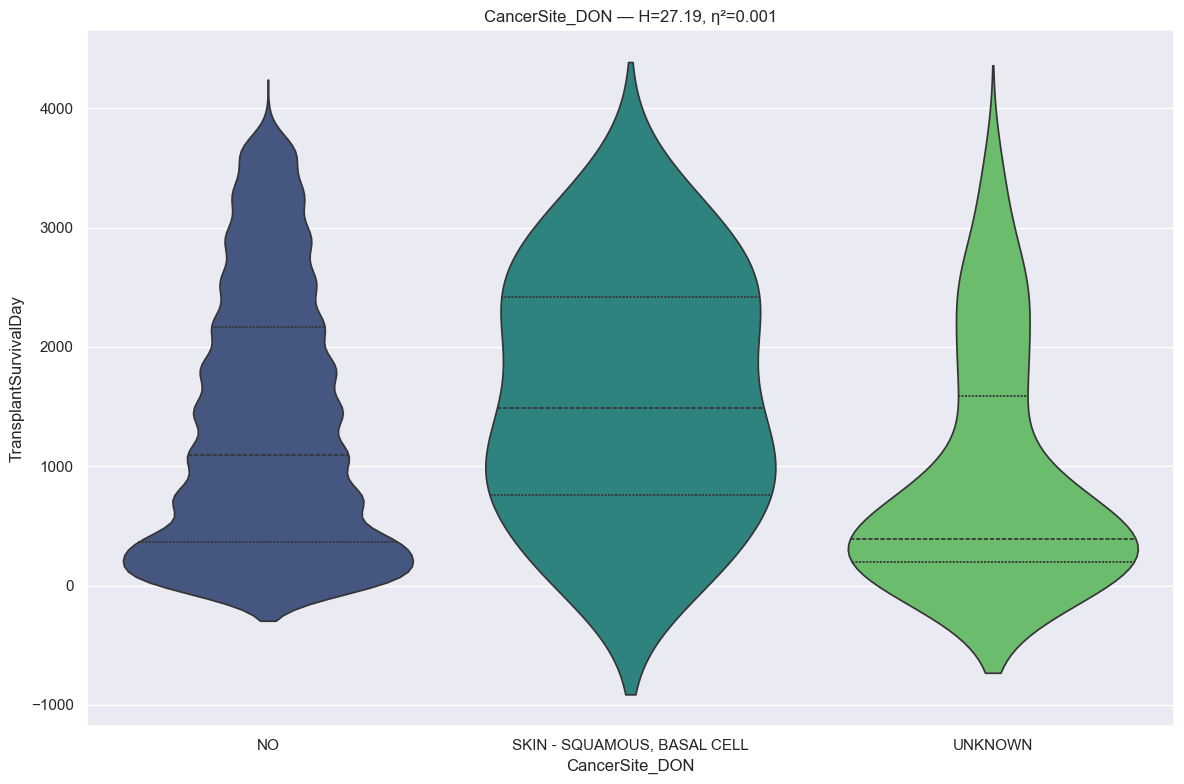

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * NO                                                :  19700 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     49 records
 * UNKNOWN                                           :    131 records
BYPASSED CATEGORIES (n < min_n):
 * CNS TUMOR - ASTROCYTOMA                           :     13 records
 * CNS TUMOR - GLIOBLASTOMA MULTIFORME               :     11 records
 * CNS TUMOR - MEDULLOBLASTOMA                       :      1 records
 * CNS TUMOR - MENINGIOMA                            :      3 records
 * CNS TUMOR - OTHER                                 :     13 records
 * GASTROINTESTINAL - COLO-RECTAL                    :      3 records
 * GASTROINTESTINAL - STOMACH                        :      1 records
 * GENITOURINARY - BLADDER                           :      2 records
 * GENITOURINARY - KIDNEY                            :      6 records
 * GENITOURINARY - PENIS, TESTICULAR                 :     17 reco

In [141]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [142]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'NO': 'Group_1', 'SKIN - SQUAMOUS, BASAL CELL': 'Group_2', 'UNKNOWN': 'Group_3', 'CNS TUMOR - ASTROCYTOMA': 'Other', 'CNS TUMOR - GLIOBLASTOMA MULTIFORME': 'Other', 'CNS TUMOR - MEDULLOBLASTOMA': 'Other', 'CNS TUMOR - MENINGIOMA': 'Other', 'CNS TUMOR - OTHER': 'Other', 'GASTROINTESTINAL - COLO-RECTAL': 'Other', 'GASTROINTESTINAL - STOMACH': 'Other', 'GENITOURINARY - BLADDER': 'Other', 'GENITOURINARY - KIDNEY': 'Other', 'GENITOURINARY - PENIS, TESTICULAR': 'Other', 'GENITOURINARY - PROSTATE': 'Other', 'LEUKEMIA/LYMPHOMA': 'Other', 'Missing': 'Other', 'OTHER, SPECIFY': 'Other', 'SKIN - MELANOMA': 'Other', 'THYROID': 'Other'}


,CancerSite_DON,mean_survival_days,record_count
13,NO,1329.481675,19700
18,UNKNOWN,919.053435,131
16,"SKIN - SQUAMOUS, BASAL CELL",1596.142857,49
14,"OTHER, SPECIFY",1199.518519,27
9,"GENITOURINARY - PENIS, TESTICULAR",1248.882353,17
4,CNS TUMOR - OTHER,1626.846154,13
0,CNS TUMOR - ASTROCYTOMA,1687.615385,13
1,CNS TUMOR - GLIOBLASTOMA MULTIFORME,1069.545455,11
12,Missing,1465.555556,9
8,GENITOURINARY - KIDNEY,916.666667,6


In [143]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: CancerSite_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * NO                                                :  19700 records
 * SKIN - SQUAMOUS, BASAL CELL                       :     49 records
 * UNKNOWN                                           :    131 records
BYPASSED CATEGORIES (n < min_n):
 * CNS TUMOR - ASTROCYTOMA                           :     13 records
 * CNS TUMOR - GLIOBLASTOMA MULTIFORME               :     11 records
 * CNS TUMOR - MEDULLOBLASTOMA                       :      1 records
 * CNS TUMOR - MENINGIOMA                            :      3 records
 * CNS TUMOR - OTHER                                 :     13 records
 * GASTROINTESTINAL - COLO-RECTAL                    :      3 records
 * GASTROINTESTINAL - STOMACH                        :      1 records
 * GENITOURINARY - BLADDER                           :      2 records
 * GENITOURINARY - KIDNEY                            :      6 records
 * GENITOURINARY - PENIS, TESTICULAR                 :     17 reco

In [144]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'NO': 'Group_1', 'SKIN - SQUAMOUS, BASAL CELL': 'Group_2', 'UNKNOWN': 'Group_3', 'CNS TUMOR - ASTROCYTOMA': 'Other', 'CNS TUMOR - GLIOBLASTOMA MULTIFORME': 'Other', 'CNS TUMOR - MEDULLOBLASTOMA': 'Other', 'CNS TUMOR - MENINGIOMA': 'Other', 'CNS TUMOR - OTHER': 'Other', 'GASTROINTESTINAL - COLO-RECTAL': 'Other', 'GASTROINTESTINAL - STOMACH': 'Other', 'GENITOURINARY - BLADDER': 'Other', 'GENITOURINARY - KIDNEY': 'Other', 'GENITOURINARY - PENIS, TESTICULAR': 'Other', 'GENITOURINARY - PROSTATE': 'Other', 'LEUKEMIA/LYMPHOMA': 'Other', 'Missing': 'Other', 'OTHER, SPECIFY': 'Other', 'SKIN - MELANOMA': 'Other', 'THYROID': 'Other'}


,CancerSite_DON,mean_survival_days,record_count
13,NO,1329.481675,19700
18,UNKNOWN,919.053435,131
16,"SKIN - SQUAMOUS, BASAL CELL",1596.142857,49
14,"OTHER, SPECIFY",1199.518519,27
9,"GENITOURINARY - PENIS, TESTICULAR",1248.882353,17
4,CNS TUMOR - OTHER,1626.846154,13
0,CNS TUMOR - ASTROCYTOMA,1687.615385,13
1,CNS TUMOR - GLIOBLASTOMA MULTIFORME,1069.545455,11
12,Missing,1465.555556,9
8,GENITOURINARY - KIDNEY,916.666667,6


In [145]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Cigarette History

In [146]:
# info
features = u.get_feature_info(df, 'CigaretteHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique top   freq
CigaretteHistory_DON  20007      4  No  17458

:::: NaN Count:
CigaretteHistory_DON    0 



{'CigaretteHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

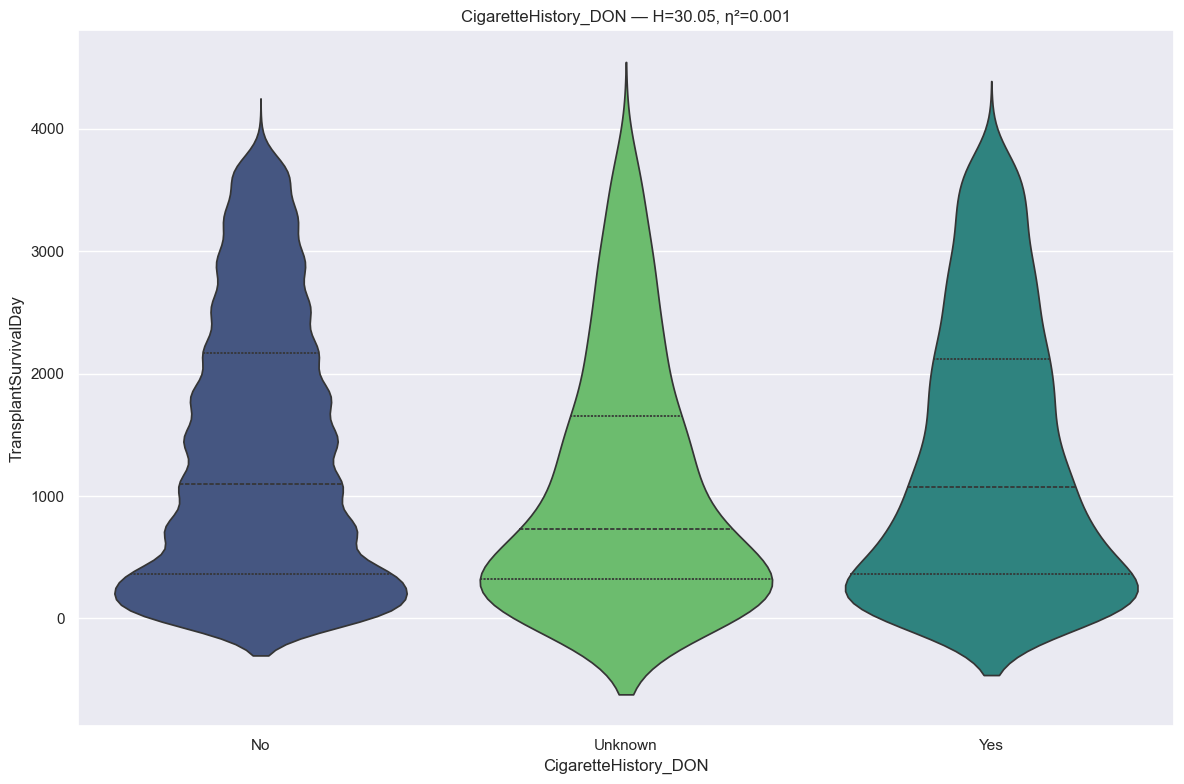

RANKING REPORT: CigaretteHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  17458 records
 * Unknown                                           :    341 records
 * Yes                                               :   2204 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 30.0505 | P-value: 2.982686e-07 | Effect η²: 0.0014
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.2083e-06 | thr=0.0167 | r=-0.153 | *Sig*
Unknown      vs Yes          | p=6.9672e-04 | thr=0.0167 | r= 0.114 | *Sig*
No           vs Yes          | p=5.3642e-03 | thr=0.0167 | r=-0.036 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [147]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [148]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_2', 'Yes': 'Group_3', 'Missing': 'Other'}


,CigaretteHistory_DON,mean_survival_days,record_count
1,No,1337.473880,17458
3,Yes,1282.543557,2204
2,Unknown,1065.442815,341
0,Missing,956.250000,4


In [149]:
# mapping (Missing and Unknown are close enough, with only 4 in Missing)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,CigaretteHistory_DON,mean_survival_days,record_count
0,No,1337.473880,17458
2,Yes,1282.543557,2204
1,Other,1064.176812,345


#### Hypertension History

In [150]:
# info
features = u.get_feature_info(df, 'HypertensionHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                         count unique top   freq
HypertensionHistory_DON  20007      4  No  17184

:::: NaN Count:
HypertensionHistory_DON    0 



{'HypertensionHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

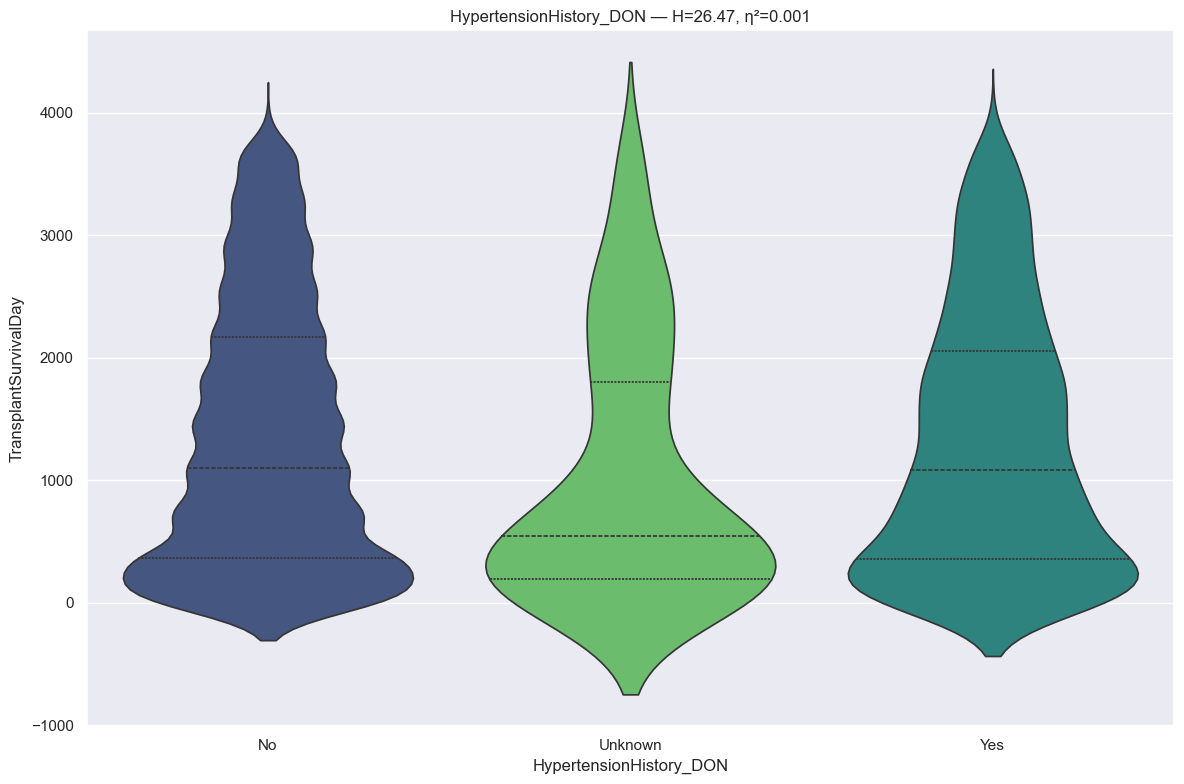

RANKING REPORT: HypertensionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  17184 records
 * Unknown                                           :    169 records
 * Yes                                               :   2651 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 26.4739 | P-value: 1.783466e-06 | Effect η²: 0.0012
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.4131e-05 | thr=0.0167 | r=-0.194 | *Sig*
Unknown      vs Yes          | p=4.7612e-04 | thr=0.0167 | r= 0.160 | *Sig*
No           vs Yes          | p=3.6089e-03 | thr=0.0167 | r=-0.035 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [151]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [152]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Unknown': 'Group_2', 'Yes': 'Group_3', 'Missing': 'Other'}


,HypertensionHistory_DON,mean_survival_days,record_count
1,No,1337.980680,17184
3,Yes,1273.089023,2651
2,Unknown,1023.065089,169
0,Missing,1256.333333,3


In [153]:
# mapping (Missing and Unknown are close enough, with only 3 in Missing)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,HypertensionHistory_DON,mean_survival_days,record_count
0,No,1337.980680,17184
2,Yes,1273.089023,2651
1,Other,1027.133721,172


#### Cancer Intra Cranial

In [154]:
# info
features = u.get_feature_info(df, 'CancerIntraCranial', cat=False)
# dtype
{col: df[col].dtype for col in features}

                        count unique top   freq
CancerIntraCranial_DON  20007      4  No  19795

:::: NaN Count:
CancerIntraCranial_DON    0 



{'CancerIntraCranial_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

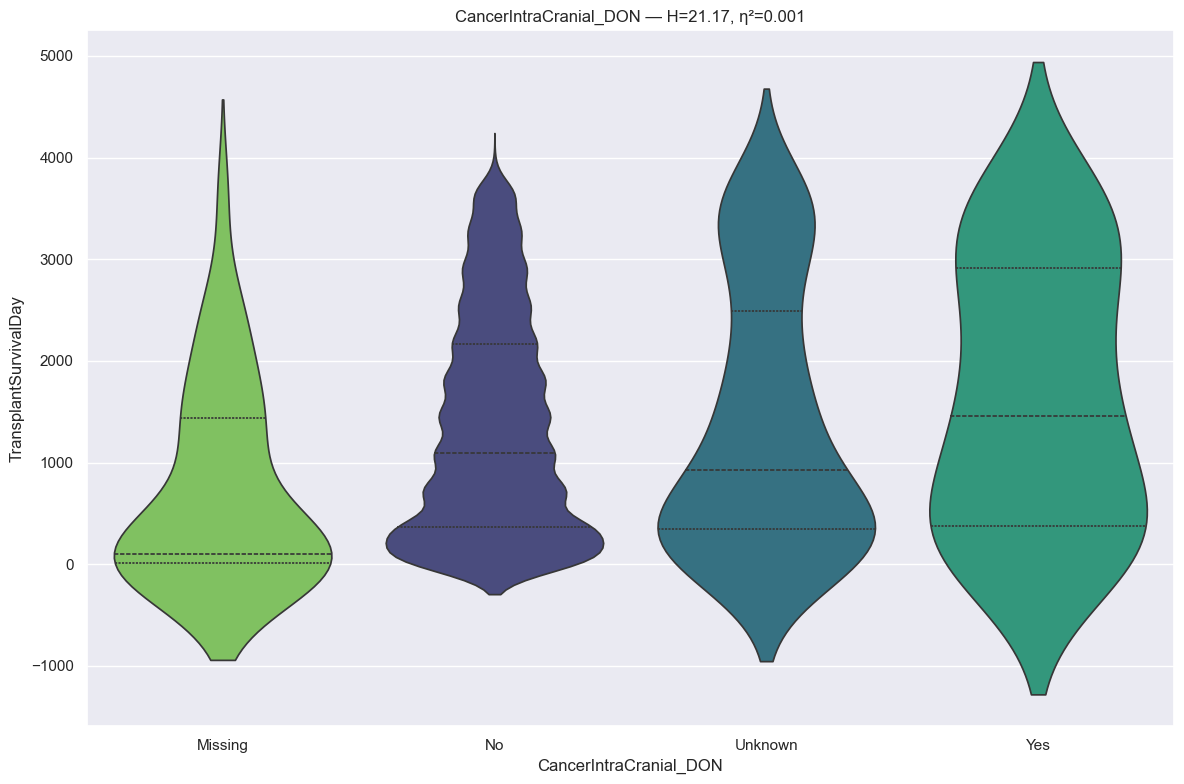

RANKING REPORT: CancerIntraCranial_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19795 records
 * Unknown                                           :    138 records
 * Yes                                               :     36 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 21.1748 | P-value: 9.683317e-05 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=9.3416e-06 | thr=0.0083 | r= 0.415 | *Sig*
Missing      vs Unknown      | p=4.8686e-04 | thr=0.0083 | r= 0.370 | *Sig*
Missing      vs Yes          | p=7.8295e-04 | thr=0.0083 | r= 0.455 | *Sig*
No           vs Yes          | p=2.2587e-01 | thr=0.0083 | r= 0.117 | Not Sig


In [155]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [156]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Unknown': 'Group_2', 'Yes': 'Group_3'}


,CancerIntraCranial_DON,mean_survival_days,record_count
1,No,1326.854862,19795
2,Unknown,1385.420290,138
0,Missing,737.078947,38
3,Yes,1644.361111,36


#### Cancer History

In [157]:
# info
features = u.get_feature_info(df, 'CancerHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique top   freq
CancerHistory_DON  20007      4  No  19700

:::: NaN Count:
CancerHistory_DON    0 



{'CancerHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

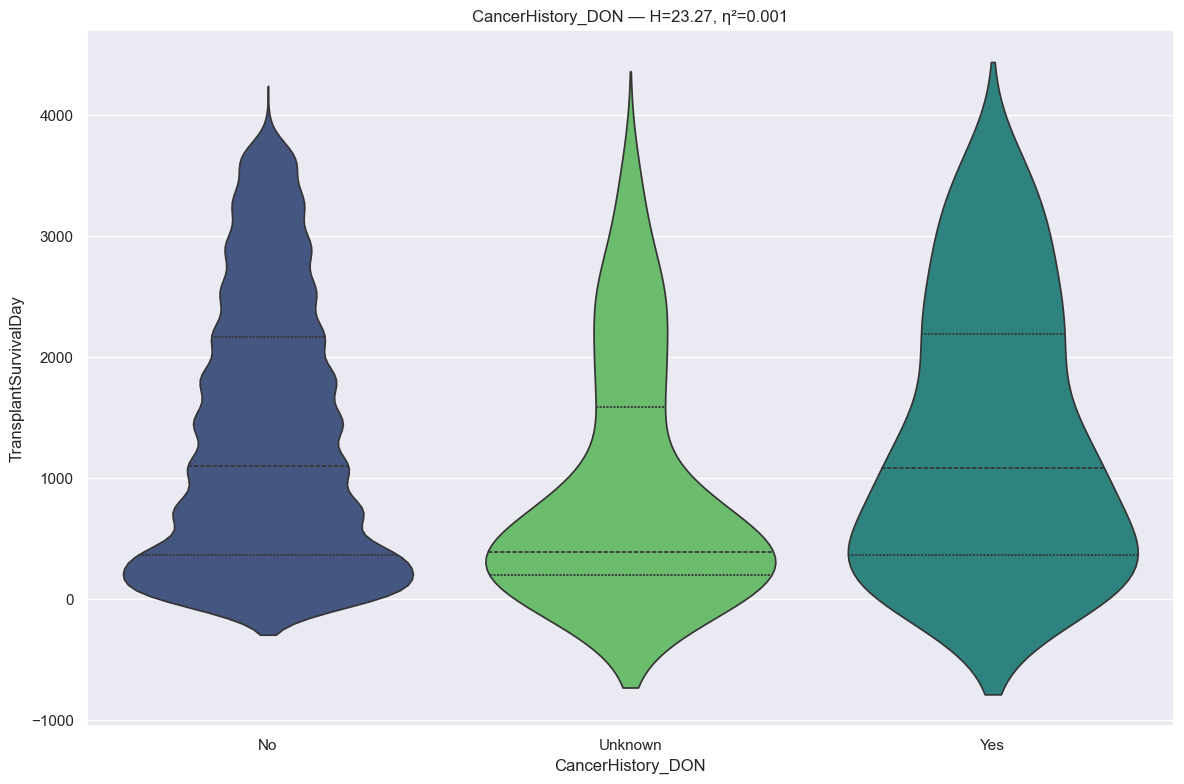

RANKING REPORT: CancerHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19700 records
 * Unknown                                           :    131 records
 * Yes                                               :    167 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      9 records
--------------------------------------------------------------------------------
Kruskal H: 23.2717 | P-value: 8.843183e-06 | Effect η²: 0.0011
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.5398e-06 | thr=0.0167 | r=-0.243 | *Sig*
Unknown      vs Yes          | p=1.1376e-03 | thr=0.0167 | r= 0.220 | *Sig*
No           vs Yes          | p=6.4680e-01 | thr=0.0167 | r=-0.021 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [158]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [159]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Unknown': 'Group_2', 'Missing': 'Other'}


,CancerHistory_DON,mean_survival_days,record_count
1,No,1329.481675,19700
3,Yes,1312.041916,167
2,Unknown,919.053435,131
0,Missing,1465.555556,9


In [160]:
# mapping (Combine missing to unknown, not enough to trust the mean survival at all)
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,CancerHistory_DON,mean_survival_days,record_count
0,No,1329.481675,19700
2,Yes,1312.041916,167
1,Other,954.185714,140


#### Diabetes History

In [161]:
# info
features = u.get_feature_info(df, 'DiabetesHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique top   freq
DiabetesHistory_DON  20007      7  No  19246

:::: NaN Count:
DiabetesHistory_DON    0 



{'DiabetesHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes, 0-5 Years',
                   'Yes, 6-10 Years', 'Yes, >10 Years',
                   'Yes, Duration Unknown'],
 , ordered=False, categories_dtype=object)}

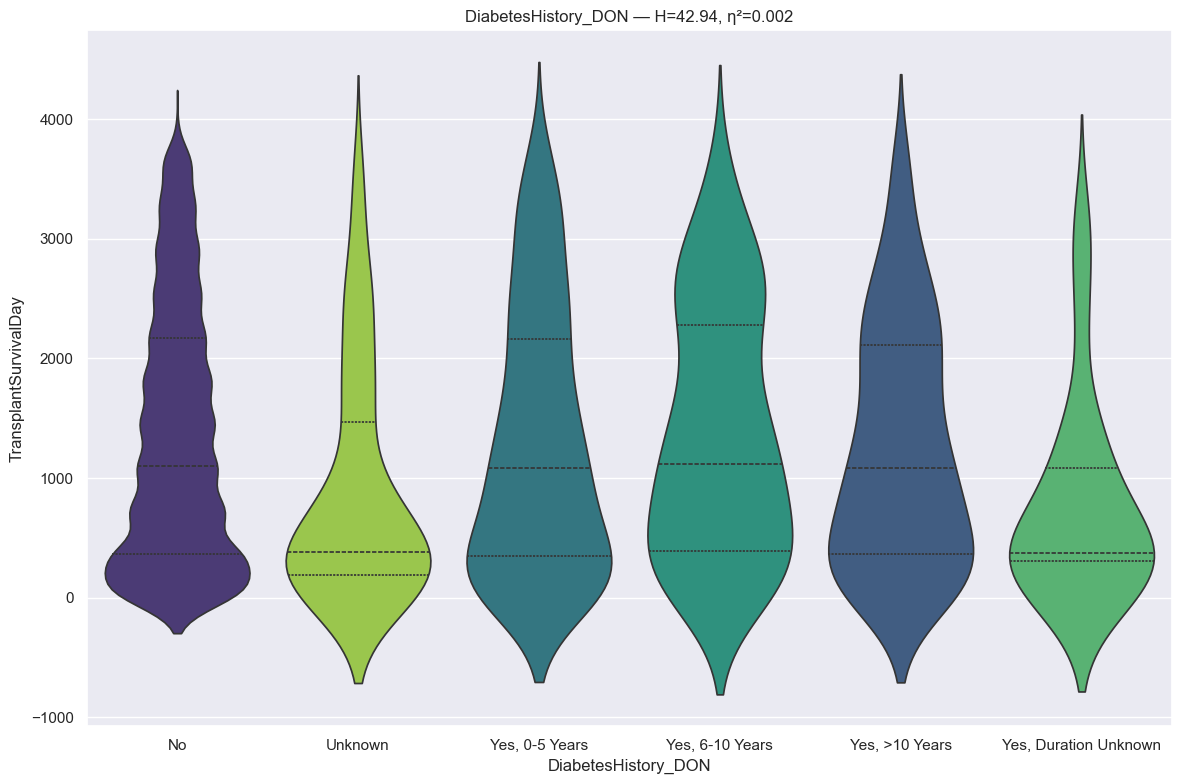

RANKING REPORT: DiabetesHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19246 records
 * Unknown                                           :    142 records
 * Yes, 0-5 Years                                    :    286 records
 * Yes, 6-10 Years                                   :    113 records
 * Yes, >10 Years                                    :    173 records
 * Yes, Duration Unknown                             :     44 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 42.9378 | P-value: 3.803828e-08 | Effect η²: 0.0019
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.1645e-07 | thr=0.0033 | r=-0.258 | *Sig*
Unknown      vs 

In [162]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [163]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes, 0-5 Years': 'Group_1', 'Yes, 6-10 Years': 'Group_1', 'Yes, >10 Years': 'Group_1', 'Unknown': 'Group_2', 'Yes, Duration Unknown': 'Group_2', 'Missing': 'Other'}


,DiabetesHistory_DON,mean_survival_days,record_count
1,No,1332.350099,19246
3,"Yes, 0-5 Years",1275.741259,286
5,"Yes, >10 Years",1245.722543,173
2,Unknown,894.866197,142
4,"Yes, 6-10 Years",1379.415929,113
6,"Yes, Duration Unknown",772.500000,44
0,Missing,1256.333333,3


In [164]:
# Remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
# add to remove list (Use Diabetes_DON)
remove_cols.extend(features)

#### Diabetes

In [165]:
# info
features = u.get_feature_info(df, 'Diabetes_DON', cat=False)
# dtype
{col: df[col].dtype for col in features}

              count unique top   freq
Diabetes_DON  20007      4  No  19246

:::: NaN Count:
Diabetes_DON    0 



{'Diabetes_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

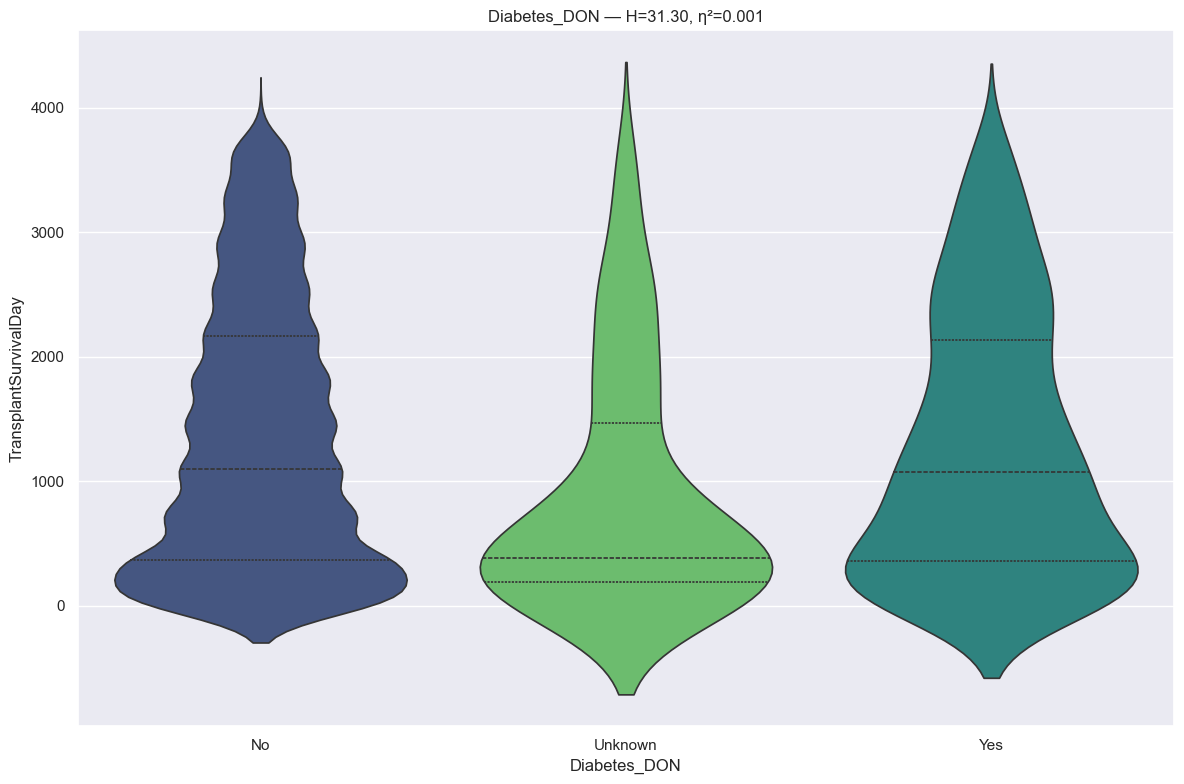

RANKING REPORT: Diabetes_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19246 records
 * Unknown                                           :    142 records
 * Yes                                               :    616 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 31.3042 | P-value: 1.593636e-07 | Effect η²: 0.0015
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=1.1645e-07 | thr=0.0167 | r=-0.258 | *Sig*
Unknown      vs Yes          | p=5.4937e-05 | thr=0.0167 | r= 0.217 | *Sig*
No           vs Yes          | p=6.1477e-02 | thr=0.0167 | r=-0.044 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [166]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [167]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_1', 'Unknown': 'Group_2', 'Missing': 'Other'}


,Diabetes_DON,mean_survival_days,record_count
1,No,1332.350099,19246
3,Yes,1250.383117,616
2,Unknown,894.866197,142
0,Missing,1256.333333,3


In [168]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,Diabetes_DON,mean_survival_days,record_count
0,No,1332.350099,19246
2,Yes,1250.383117,616
1,Other,902.344828,145


#### Past Other Drug Use

In [169]:
# info
features = u.get_feature_info(df, 'PastOtherDrugUse', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique  top   freq
PastOtherDrugUse_DON  20007      4  Yes  11850

:::: NaN Count:
PastOtherDrugUse_DON    0 



{'PastOtherDrugUse_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

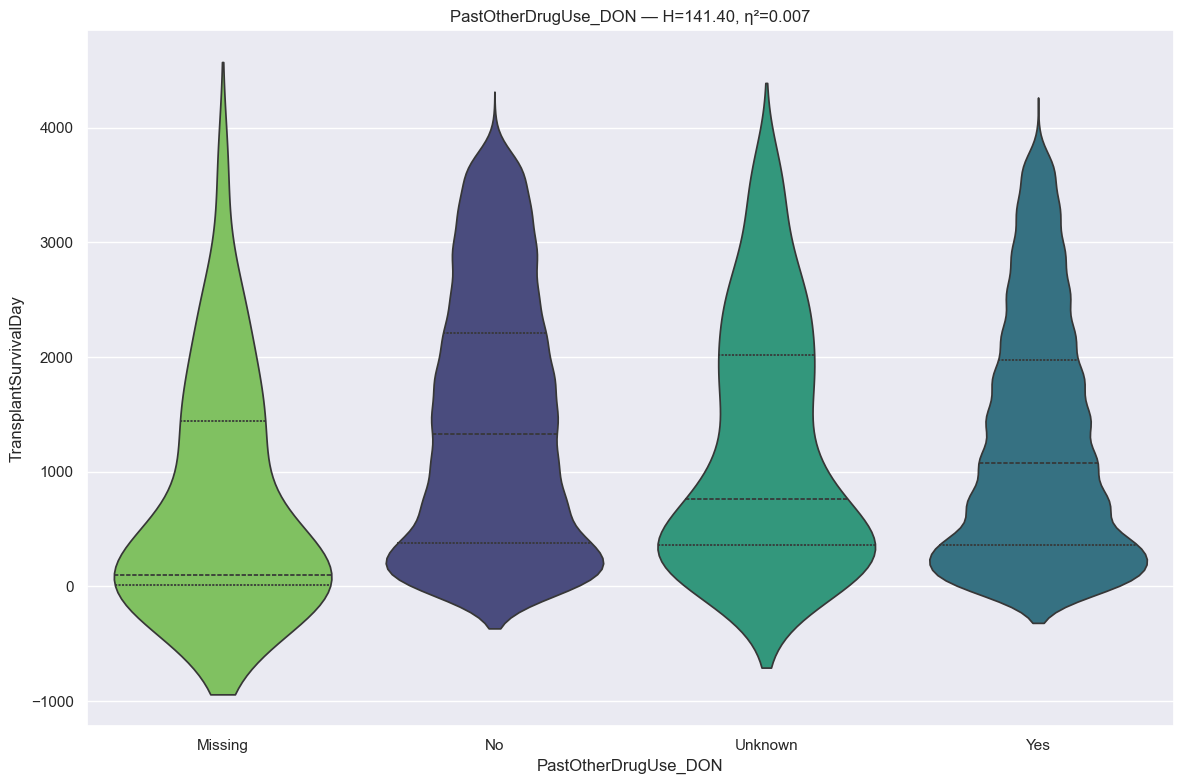

RANKING REPORT: PastOtherDrugUse_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   7887 records
 * Unknown                                           :    232 records
 * Yes                                               :  11850 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 141.3953 | P-value: 1.890553e-30 | Effect η²: 0.0069
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.2679e-27 | thr=0.0083 | r=-0.091 | *Sig*
Missing      vs No           | p=1.5441e-06 | thr=0.0083 | r= 0.451 | *Sig*
Missing      vs Yes          | p=2.9163e-05 | thr=0.0083 | r= 0.392 | *Sig*
Missing      vs Unknown      | p=2.1638e-04 | thr=0.0083 | r= 0.375 | *Sig*
No 

In [170]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [171]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Unknown': 'Group_3', 'Yes': 'Group_3'}


,PastOtherDrugUse_DON,mean_survival_days,record_count
3,Yes,1256.417975,11850
1,No,1438.826930,7887
2,Unknown,1202.137931,232
0,Missing,737.078947,38


#### Cancer Skin

In [172]:
# info
features = u.get_feature_info(df, 'CancerSkin', cat=False)
# dtype
{col: df[col].dtype for col in features}

                count unique top   freq
CancerSkin_DON  20007      4  No  19824

:::: NaN Count:
CancerSkin_DON    0 



{'CancerSkin_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

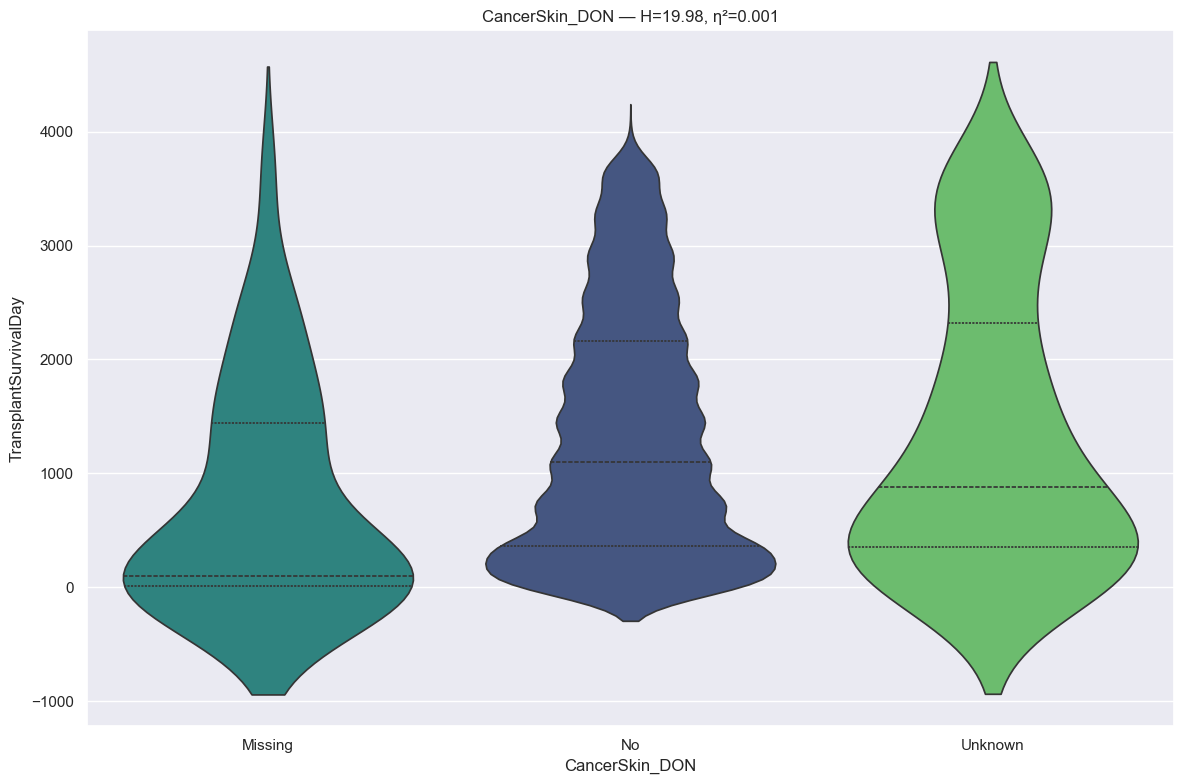

RANKING REPORT: CancerSkin_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19824 records
 * Unknown                                           :    130 records
BYPASSED CATEGORIES (n < min_n):
 * Yes                                               :     15 records
--------------------------------------------------------------------------------
Kruskal H: 19.9765 | P-value: 4.593722e-05 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=9.3689e-06 | thr=0.0167 | r= 0.415 | *Sig*
Missing      vs Unknown      | p=7.3474e-04 | thr=0.0167 | r= 0.361 | *Sig*
No           vs Unknown      | p=5.4153e-01 | thr=0.0167 | r=-0.031 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [173]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [174]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Unknown': 'Group_2', 'Yes': 'Other'}


,CancerSkin_DON,mean_survival_days,record_count
1,No,1327.256305,19824
2,Unknown,1338.792308,130
0,Missing,737.078947,38
3,Yes,1993.666667,15


#### Serology Anti CMV

In [175]:
# info
features = u.get_feature_info(df, 'SerologyAntiCMV', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique       top   freq
SerologyAntiCMV_DON  20007      6  Positive  11684

:::: NaN Count:
SerologyAntiCMV_DON    0 



{'SerologyAntiCMV_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

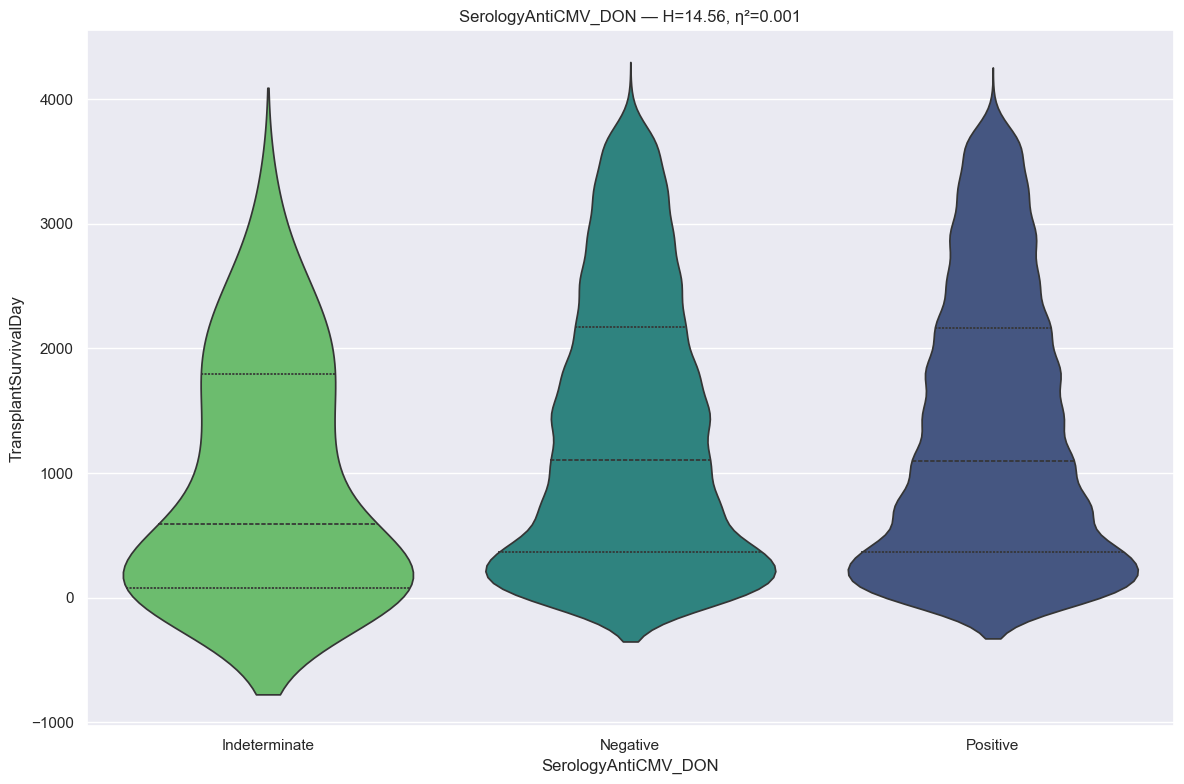

RANKING REPORT: SerologyAntiCMV_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     78 records
 * Negative                                          :   8224 records
 * Positive                                          :  11684 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      6 records
 * Not Done                                          :     14 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 14.5610 | P-value: 6.888544e-04 | Effect η²: 0.0006
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Indeterminate vs Negative     | p=1.5395e-04 | thr=0.0167 | r= 0.249 | *Sig*
Indeterminate vs Positive     | p=2.0495e-04 | thr=0.0167 | r= 0.244 | *Sig*
Negative

In [176]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [177]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_2', 'Positive': 'Group_2', 'Missing': 'Other', 'Not Done': 'Other', 'Unknown': 'Other'}


,SerologyAntiCMV_DON,mean_survival_days,record_count
4,Positive,1323.053834,11684
2,Negative,1335.547787,8224
0,Indeterminate,925.384615,78
3,Not Done,1676.857143,14
1,Missing,893.833333,6
5,Unknown,361.000000,1


In [178]:
# mapping (Missing and Unknown are close enough, with only 4 in Missing)
mapping = {'Not Done': 'Other',
           'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,SerologyAntiCMV_DON,mean_survival_days,record_count
3,Positive,1323.053834,11684
1,Negative,1335.547787,8224
0,Indeterminate,925.384615,78
2,Other,1390.476190,21


#### Cause Of Death

In [179]:
# info
features = u.get_feature_info(df, 'CauseOfDeath', cat=False)
# dtype
{col: df[col].dtype for col in features}

                  count unique          top   freq
CauseOfDeath_DON  20007      6  HEAD TRAUMA  10708

:::: NaN Count:
CauseOfDeath_DON    0 



{'CauseOfDeath_DON': CategoricalDtype(categories=['ANOXIA', 'CEREBROVASCULAR/STROKE', 'CNS TUMOR',
                   'HEAD TRAUMA', 'Missing', 'OTHER SPECIFY'],
 , ordered=False, categories_dtype=object)}

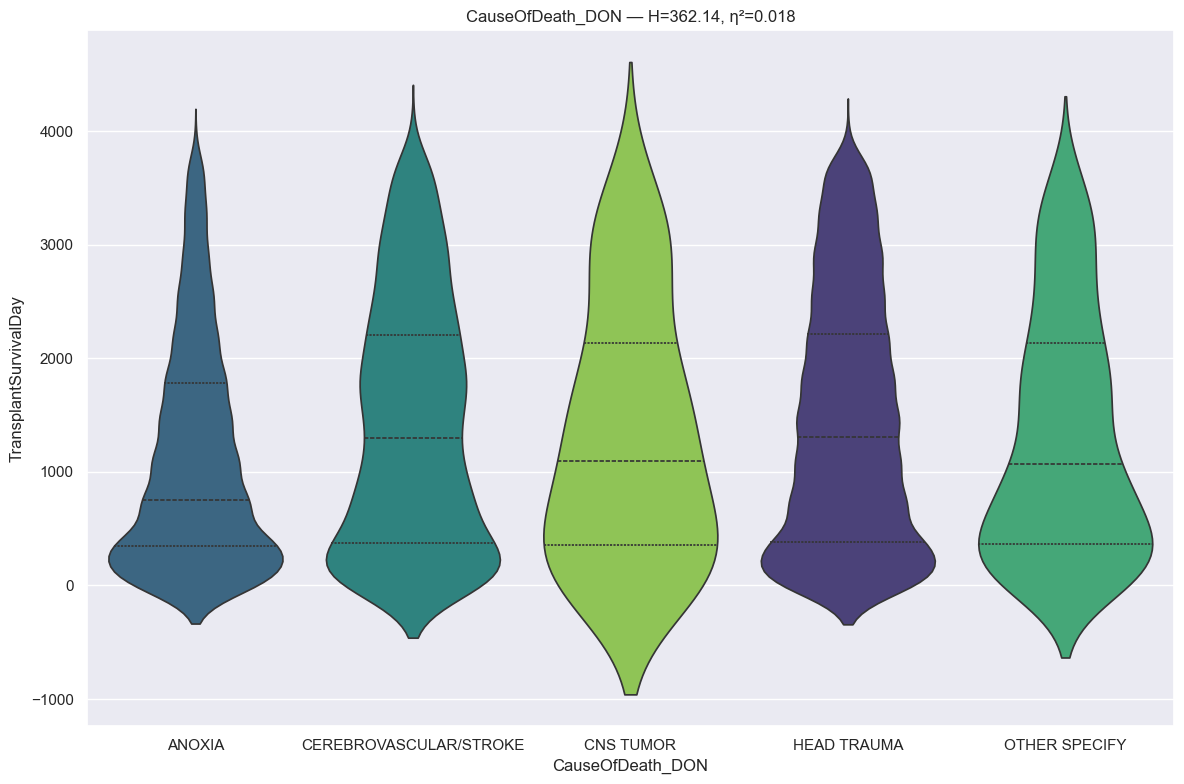

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   6414 records
 * CEREBROVASCULAR/STROKE                            :   2387 records
 * CNS TUMOR                                         :     68 records
 * HEAD TRAUMA                                       :  10708 records
 * OTHER SPECIFY                                     :    427 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 362.1440 | P-value: 4.184833e-77 | Effect η²: 0.0179
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0050 | r_threshold: 0.10)
--------------------------------------------------------------------------------
ANOXIA       vs HEAD TRAUMA  | p=1.1449e-77 | thr=0.0050 | r= 0.170 | *Sig*
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.0572e-28 | thr=0.0050 | r= 0.154 | *Sig*
AN

In [180]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [181]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ANOXIA': 'Group_1', 'CEREBROVASCULAR/STROKE': 'Group_1', 'CNS TUMOR': 'Group_1', 'HEAD TRAUMA': 'Group_1', 'OTHER SPECIFY': 'Group_1', 'Missing': 'Other'}


,CauseOfDeath_DON,mean_survival_days,record_count
3,HEAD TRAUMA,1438.529324,10708
0,ANOXIA,1109.235734,6414
1,CEREBROVASCULAR/STROKE,1414.826979,2387
5,OTHER SPECIFY,1299.690867,427
2,CNS TUMOR,1310.985294,68
4,Missing,1256.333333,3


In [182]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: CauseOfDeath_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ANOXIA                                            :   6414 records
 * CEREBROVASCULAR/STROKE                            :   2387 records
 * CNS TUMOR                                         :     68 records
 * HEAD TRAUMA                                       :  10708 records
 * OTHER SPECIFY                                     :    427 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 362.1440 | P-value: 4.184833e-77 | Effect η²: 0.0179
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.05)
--------------------------------------------------------------------------------
ANOXIA       vs HEAD TRAUMA  | p=1.1449e-77 | fdr_alpha=0.05 | r= 0.170 | *Sig*
ANOXIA       vs CEREBROVASCULAR/STROKE | p=1.0572e-28 | fdr_alpha=0.05 | r= 0.154 | *

In [183]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ANOXIA': 'Group_1', 'CEREBROVASCULAR/STROKE': 'Group_2', 'HEAD TRAUMA': 'Group_2', 'CNS TUMOR': 'Group_3', 'OTHER SPECIFY': 'Group_3', 'Missing': 'Other'}


,CauseOfDeath_DON,mean_survival_days,record_count
3,HEAD TRAUMA,1438.529324,10708
0,ANOXIA,1109.235734,6414
1,CEREBROVASCULAR/STROKE,1414.826979,2387
5,OTHER SPECIFY,1299.690867,427
2,CNS TUMOR,1310.985294,68
4,Missing,1256.333333,3


In [184]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Death Mechanism

In [185]:
# info
features = u.get_feature_info(df, 'DeathMechanism', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique           top  freq
DeathMechanism_DON  20007     13  BLUNT INJURY  6265

:::: NaN Count:
DeathMechanism_DON    0 



{'DeathMechanism_DON': CategoricalDtype(categories=['ASPHYXIATION', 'BLUNT INJURY', 'CARDIOVASCULAR',
                   'DEATH FROM NATURAL CAUSES', 'DROWNING', 'DRUG INTOXICATION',
                   'ELECTRICAL', 'GUNSHOT WOUND',
                   'INTRACRANIAL HEMORRHAGE/STROKE', 'Missing',
                   'NONE OF THE ABOVE', 'SEIZURE', 'STAB'],
 , ordered=False, categories_dtype=object)}

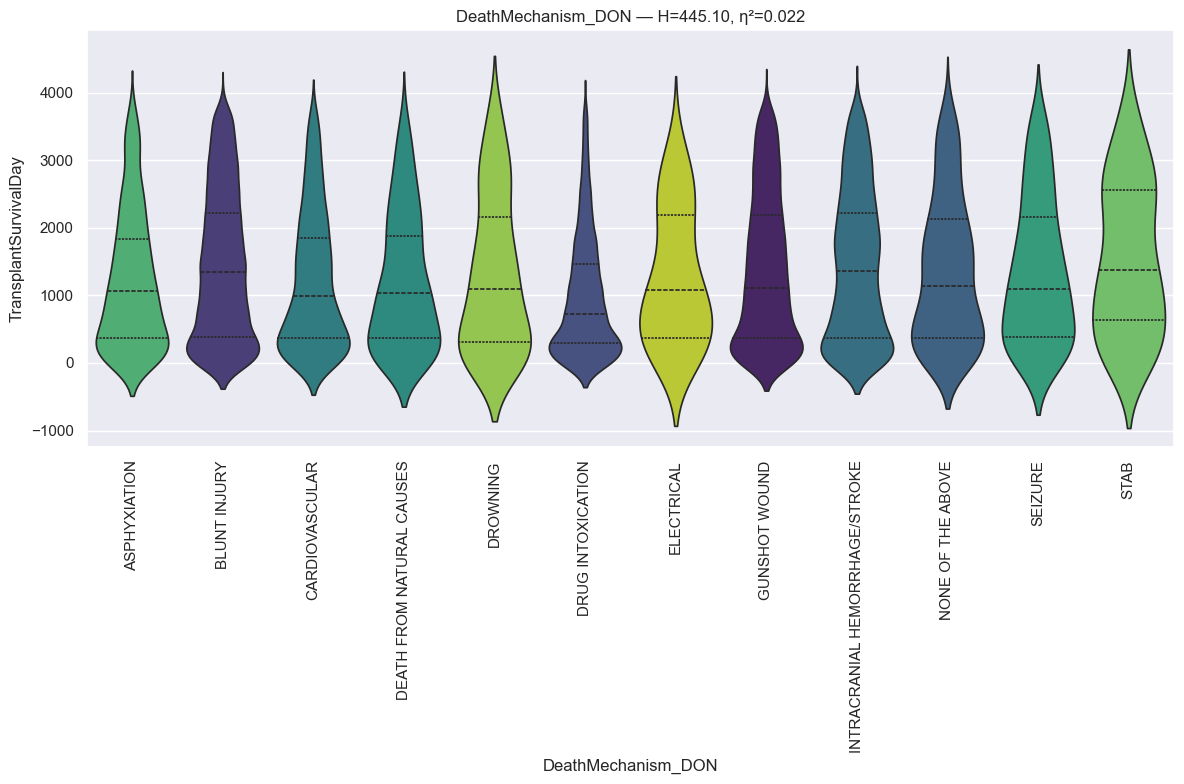

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :   1189 records
 * BLUNT INJURY                                      :   6265 records
 * CARDIOVASCULAR                                    :   1473 records
 * DEATH FROM NATURAL CAUSES                         :    283 records
 * DROWNING                                          :    123 records
 * DRUG INTOXICATION                                 :   3088 records
 * ELECTRICAL                                        :     37 records
 * GUNSHOT WOUND                                     :   4376 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2628 records
 * NONE OF THE ABOVE                                 :    316 records
 * SEIZURE                                           :    157 records
 * STAB                                              :     67 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      5 

In [186]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    suppress_pairwise=True,
    rotation = 90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [187]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ASPHYXIATION': 'Group_1', 'BLUNT INJURY': 'Group_1', 'CARDIOVASCULAR': 'Group_1', 'DEATH FROM NATURAL CAUSES': 'Group_1', 'DROWNING': 'Group_1', 'ELECTRICAL': 'Group_1', 'GUNSHOT WOUND': 'Group_1', 'INTRACRANIAL HEMORRHAGE/STROKE': 'Group_1', 'NONE OF THE ABOVE': 'Group_1', 'SEIZURE': 'Group_1', 'STAB': 'Group_1', 'DRUG INTOXICATION': 'Group_2', 'Missing': 'Other'}


,DeathMechanism_DON,mean_survival_days,record_count
1,BLUNT INJURY,1447.090662,6265
7,GUNSHOT WOUND,1400.766225,4376
5,DRUG INTOXICATION,981.493847,3088
8,INTRACRANIAL HEMORRHAGE/STROKE,1434.717275,2628
2,CARDIOVASCULAR,1216.411405,1473
0,ASPHYXIATION,1220.281749,1189
10,NONE OF THE ABOVE,1367.743671,316
3,DEATH FROM NATURAL CAUSES,1207.978799,283
11,SEIZURE,1361.560510,157
4,DROWNING,1294.317073,123


In [188]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :   1189 records
 * BLUNT INJURY                                      :   6265 records
 * CARDIOVASCULAR                                    :   1473 records
 * DEATH FROM NATURAL CAUSES                         :    283 records
 * DROWNING                                          :    123 records
 * DRUG INTOXICATION                                 :   3088 records
 * ELECTRICAL                                        :     37 records
 * GUNSHOT WOUND                                     :   4376 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2628 records
 * NONE OF THE ABOVE                                 :    316 records
 * SEIZURE                                           :    157 records
 * STAB                                              :     67 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      5 

In [189]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ASPHYXIATION': 'Group_1', 'BLUNT INJURY': 'Group_1', 'CARDIOVASCULAR': 'Group_1', 'DEATH FROM NATURAL CAUSES': 'Group_1', 'DROWNING': 'Group_1', 'ELECTRICAL': 'Group_1', 'GUNSHOT WOUND': 'Group_1', 'INTRACRANIAL HEMORRHAGE/STROKE': 'Group_1', 'NONE OF THE ABOVE': 'Group_1', 'SEIZURE': 'Group_1', 'STAB': 'Group_1', 'DRUG INTOXICATION': 'Group_2', 'Missing': 'Other'}


,DeathMechanism_DON,mean_survival_days,record_count
1,BLUNT INJURY,1447.090662,6265
7,GUNSHOT WOUND,1400.766225,4376
5,DRUG INTOXICATION,981.493847,3088
8,INTRACRANIAL HEMORRHAGE/STROKE,1434.717275,2628
2,CARDIOVASCULAR,1216.411405,1473
0,ASPHYXIATION,1220.281749,1189
10,NONE OF THE ABOVE,1367.743671,316
3,DEATH FROM NATURAL CAUSES,1207.978799,283
11,SEIZURE,1361.560510,157
4,DROWNING,1294.317073,123


In [190]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",        # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: DeathMechanism_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * ASPHYXIATION                                      :   1189 records
 * BLUNT INJURY                                      :   6265 records
 * CARDIOVASCULAR                                    :   1473 records
 * DEATH FROM NATURAL CAUSES                         :    283 records
 * DROWNING                                          :    123 records
 * DRUG INTOXICATION                                 :   3088 records
 * ELECTRICAL                                        :     37 records
 * GUNSHOT WOUND                                     :   4376 records
 * INTRACRANIAL HEMORRHAGE/STROKE                    :   2628 records
 * NONE OF THE ABOVE                                 :    316 records
 * SEIZURE                                           :    157 records
 * STAB                                              :     67 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      5 

In [191]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'ASPHYXIATION': 'Group_1', 'BLUNT INJURY': 'Group_1', 'CARDIOVASCULAR': 'Group_1', 'DEATH FROM NATURAL CAUSES': 'Group_1', 'DROWNING': 'Group_1', 'ELECTRICAL': 'Group_1', 'GUNSHOT WOUND': 'Group_1', 'INTRACRANIAL HEMORRHAGE/STROKE': 'Group_1', 'NONE OF THE ABOVE': 'Group_1', 'SEIZURE': 'Group_1', 'STAB': 'Group_1', 'DRUG INTOXICATION': 'Group_2', 'Missing': 'Other'}


,DeathMechanism_DON,mean_survival_days,record_count
1,BLUNT INJURY,1447.090662,6265
7,GUNSHOT WOUND,1400.766225,4376
5,DRUG INTOXICATION,981.493847,3088
8,INTRACRANIAL HEMORRHAGE/STROKE,1434.717275,2628
2,CARDIOVASCULAR,1216.411405,1473
0,ASPHYXIATION,1220.281749,1189
10,NONE OF THE ABOVE,1367.743671,316
3,DEATH FROM NATURAL CAUSES,1207.978799,283
11,SEIZURE,1361.560510,157
4,DROWNING,1294.317073,123


In [192]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Heparin Management

In [193]:
# info
features = u.get_feature_info(df, 'HeparinManagement', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique  top   freq
HeparinManagement_DON  20007      4  Yes  19641

:::: NaN Count:
HeparinManagement_DON    0 



{'HeparinManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

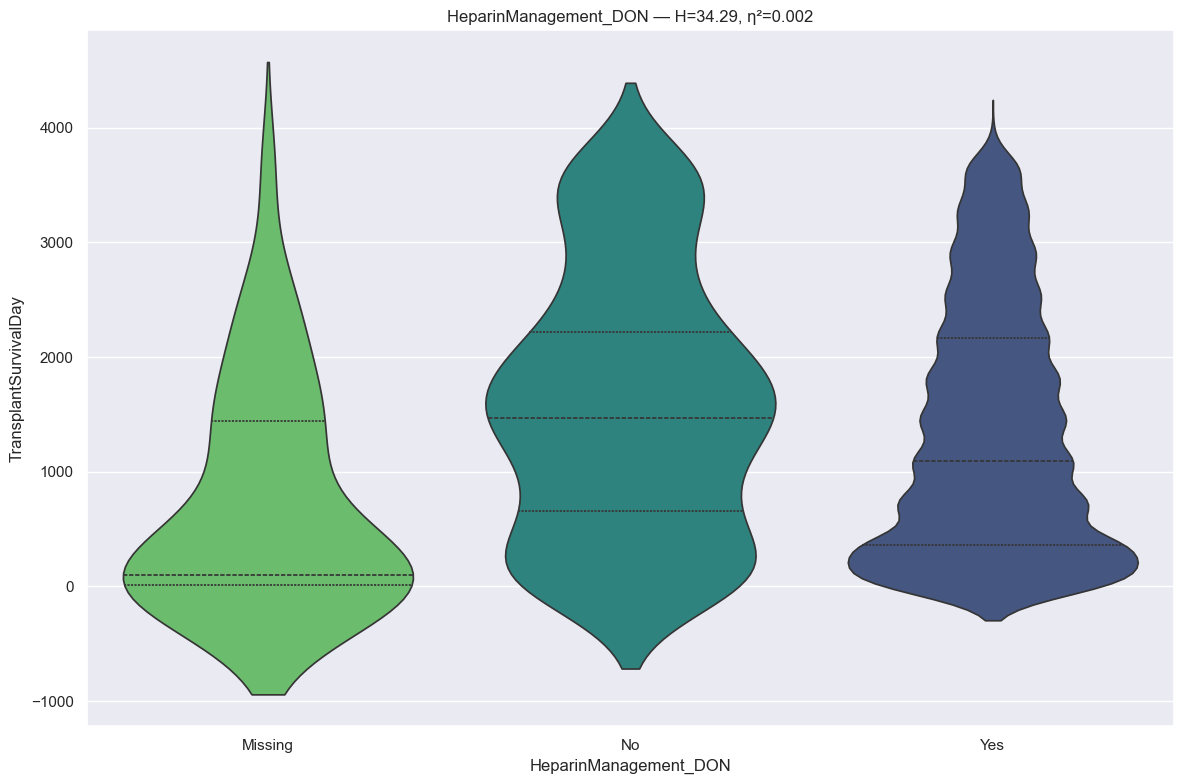

RANKING REPORT: HeparinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :    326 records
 * Yes                                               :  19641 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 34.2892 | P-value: 3.582592e-08 | Effect η²: 0.0016
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=1.3032e-06 | thr=0.0167 | r= 0.480 | *Sig*
Missing      vs Yes          | p=9.9650e-06 | thr=0.0167 | r= 0.414 | *Sig*
No           vs Yes          | p=1.2634e-04 | thr=0.0167 | r=-0.124 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [194]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [195]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,HeparinManagement_DON,mean_survival_days,record_count
3,Yes,1323.731531,19641
1,No,1576.549080,326
0,Missing,737.078947,38
2,Unknown,1055.500000,2


In [196]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,HeparinManagement_DON,mean_survival_days,record_count
2,Yes,1323.731531,19641
0,No,1576.549080,326
1,Other,753.000000,40


#### Arginnie Management

In [197]:
# info
features = u.get_feature_info(df, 'ArginnieManagement', cat=False)
# dtype
{col: df[col].dtype for col in features}

                        count unique  top   freq
ArginnieManagement_DON  20007      4  Yes  14031

:::: NaN Count:
ArginnieManagement_DON    0 



{'ArginnieManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

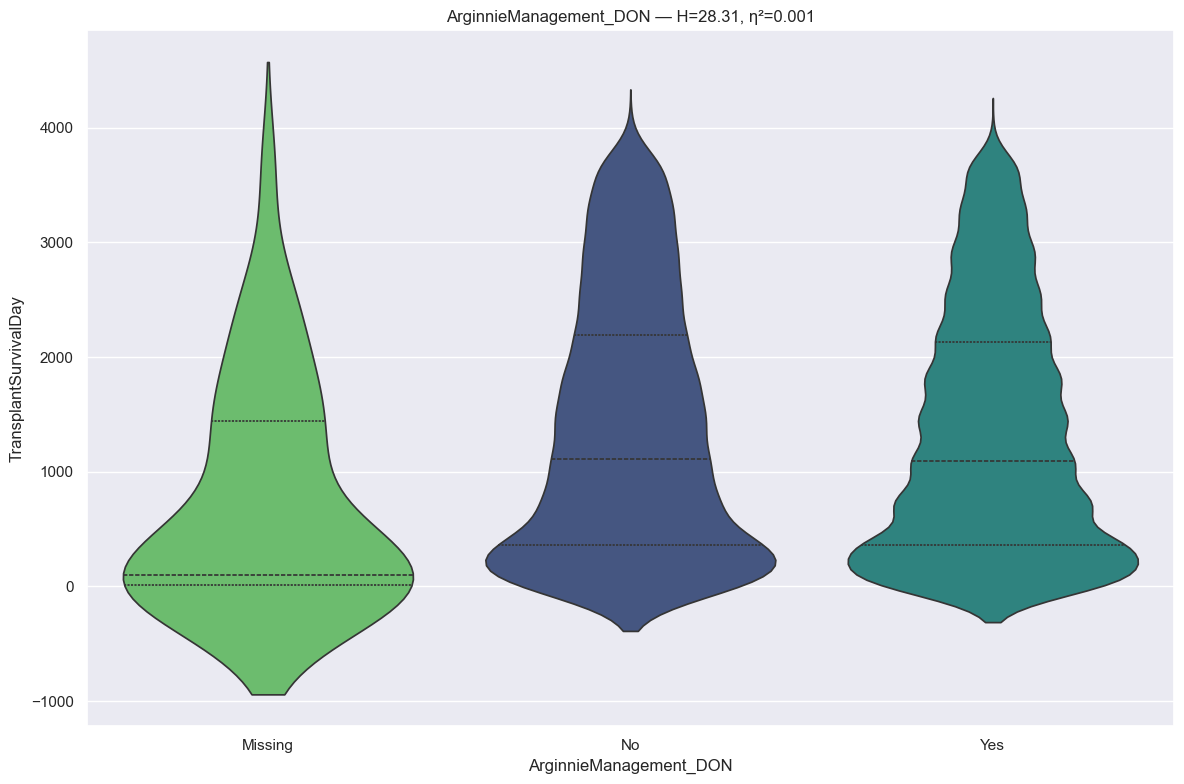

RANKING REPORT: ArginnieManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   5933 records
 * Yes                                               :  14031 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      5 records
--------------------------------------------------------------------------------
Kruskal H: 28.3072 | P-value: 7.131418e-07 | Effect η²: 0.0013
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=5.3773e-06 | thr=0.0167 | r= 0.428 | *Sig*
Missing      vs Yes          | p=1.2332e-05 | thr=0.0167 | r= 0.410 | *Sig*
No           vs Yes          | p=3.1767e-03 | thr=0.0167 | r=-0.026 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [198]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [199]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,ArginnieManagement_DON,mean_survival_days,record_count
3,Yes,1308.360915,14031
1,No,1373.578797,5933
0,Missing,737.078947,38
2,Unknown,1684.400000,5


In [200]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,ArginnieManagement_DON,mean_survival_days,record_count
2,Yes,1308.360915,14031
0,No,1373.578797,5933
1,Other,847.232558,43


#### Insulin Management

In [201]:
# info
features = u.get_feature_info(df, 'InsulinManagement', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique  top   freq
InsulinManagement_DON  20007      4  Yes  11293

:::: NaN Count:
InsulinManagement_DON    0 



{'InsulinManagement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

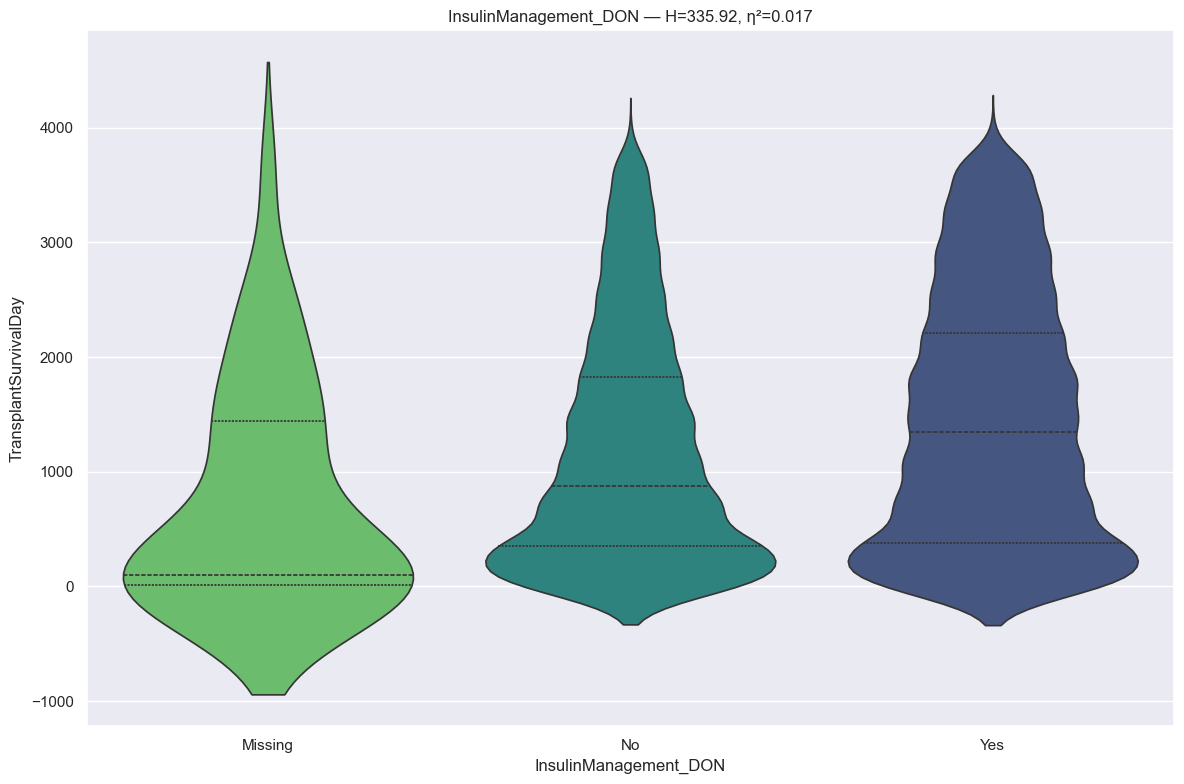

RANKING REPORT: InsulinManagement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   8673 records
 * Yes                                               :  11293 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 335.9164 | P-value: 1.139392e-73 | Effect η²: 0.0167
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=7.4349e-71 | thr=0.0167 | r= 0.147 | *Sig*
Missing      vs Yes          | p=1.1977e-06 | thr=0.0167 | r= 0.456 | *Sig*
Missing      vs No           | p=1.1152e-04 | thr=0.0167 | r= 0.363 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [202]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [203]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,InsulinManagement_DON,mean_survival_days,record_count
3,Yes,1447.636766,11293
1,No,1171.890926,8673
0,Missing,737.078947,38
2,Unknown,1168.333333,3


In [204]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Unknown': 'Other',
           'Missing': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,InsulinManagement_DON,mean_survival_days,record_count
2,Yes,1447.636766,11293
0,No,1171.890926,8673
1,Other,768.634146,41


#### HBV NAT Result

In [205]:
# info
features = u.get_feature_info(df, 'HBV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique       top   freq
HBV_NAT_Result_DON  20007      5  Negative  13910

:::: NaN Count:
HBV_NAT_Result_DON    0 



{'HBV_NAT_Result_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Positive', 'Unknown'], ordered=False, categories_dtype=object)}

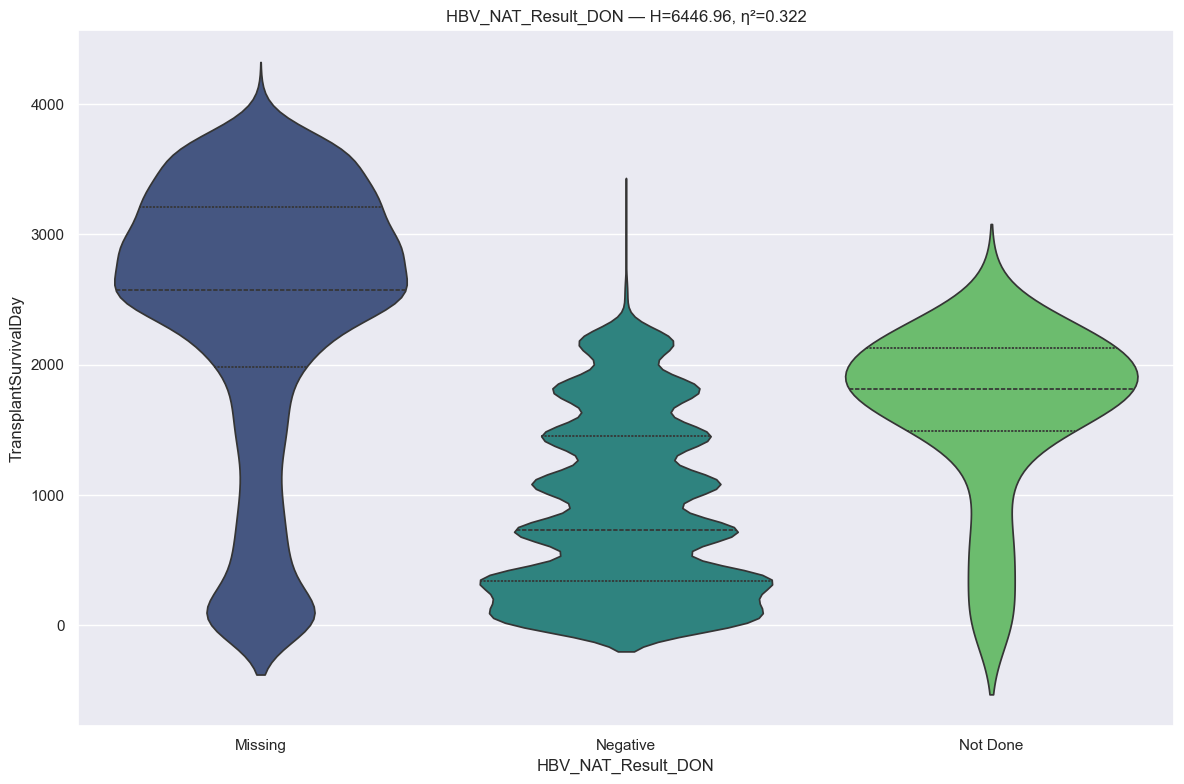

RANKING REPORT: HBV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6008 records
 * Negative                                          :  13910 records
 * Not Done                                          :     75 records
BYPASSED CATEGORIES (n < min_n):
 * Positive                                          :     12 records
 * Unknown                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 6446.9558 | P-value: 0.000000e+00 | Effect η²: 0.3224
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.713 | *Sig*
Negative     vs Not Done     | p=1.1614e-18 | thr=0.0167 | r= 0.589 | *Sig*
Missing      vs Not Done     | p=1.3462e-16 | thr=0.0167 | r=-0.555 | *Sig*
:::

In [206]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [207]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'Negative': 'Group_2', 'Not Done': 'Group_3', 'Positive': 'Other', 'Unknown': 'Other'}


,HBV_NAT_Result_DON,mean_survival_days,record_count
1,Negative,872.722358,13910
0,Missing,2374.868675,6008
2,Not Done,1647.293333,75
3,Positive,723.750000,12
4,Unknown,1737.500000,2


In [208]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Positive': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,HBV_NAT_Result_DON,mean_survival_days,record_count
1,Negative,872.722358,13910
0,Missing,2374.868675,6008
2,Not Done,1647.293333,75
3,Other,868.571429,14


#### HCV NAT Result

In [209]:
# info
features = u.get_feature_info(df, 'HCV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique       top   freq
HCV_NAT_Result_DON  20007      5  Negative  13311

:::: NaN Count:
HCV_NAT_Result_DON    0 



{'HCV_NAT_Result_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

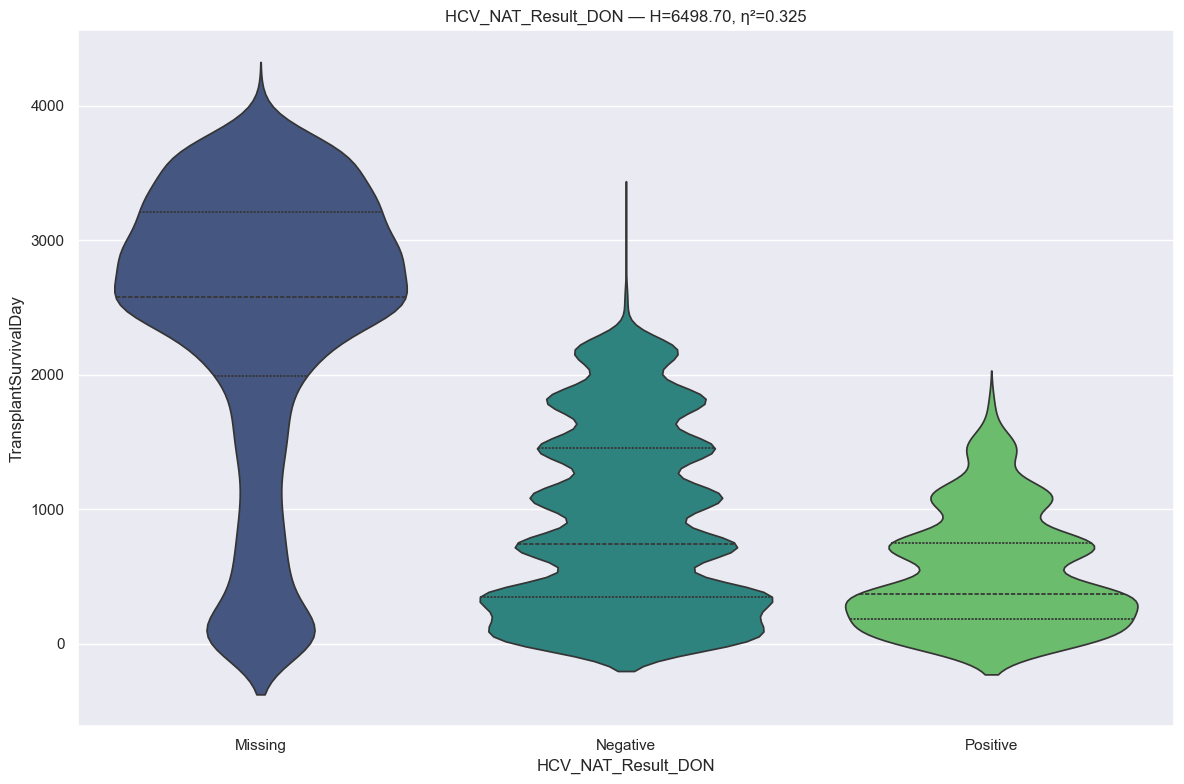

RANKING REPORT: HCV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6008 records
 * Negative                                          :  13311 records
 * Positive                                          :    671 records
BYPASSED CATEGORIES (n < min_n):
 * Indeterminate                                     :      1 records
 * Not Done                                          :     16 records
--------------------------------------------------------------------------------
Kruskal H: 6498.7023 | P-value: 0.000000e+00 | Effect η²: 0.3250
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.709 | *Sig*
Missing      vs Positive     | p=6.1092e-242 | thr=0.0167 | r=-0.781 | *Sig*
Negative     vs Positive     | p=1.8737e-37 | thr=0.0167 | r=-0.292 | *Sig*
::

In [210]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [211]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'Negative': 'Group_2', 'Positive': 'Group_3', 'Indeterminate': 'Other', 'Not Done': 'Other'}


,HCV_NAT_Result_DON,mean_survival_days,record_count
2,Negative,893.940726,13311
1,Missing,2374.868675,6008
4,Positive,528.989568,671
3,Not Done,1195.562500,16
0,Indeterminate,1949.000000,1


In [212]:
# mapping: collapse Missing & Unknown into Other: underpowered, small sample size
mapping = {'Not Done': 'Other',
           'Indeterminate': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))
# sanity check
mean_survival_by_category(df,features[0])

,HCV_NAT_Result_DON,mean_survival_days,record_count
1,Negative,893.940726,13311
0,Missing,2374.868675,6008
3,Positive,528.989568,671
2,Other,1239.882353,17


#### HIV NAT Result

In [213]:
# info
features = u.get_feature_info(df, 'HIV_NAT_Result', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique       top   freq
HIV_NAT_Result_DON  20007      3  Negative  13963

:::: NaN Count:
HIV_NAT_Result_DON    0 



{'HIV_NAT_Result_DON': CategoricalDtype(categories=['Missing', 'Negative', 'Not Done', 'Unknown'], ordered=False, categories_dtype=object)}

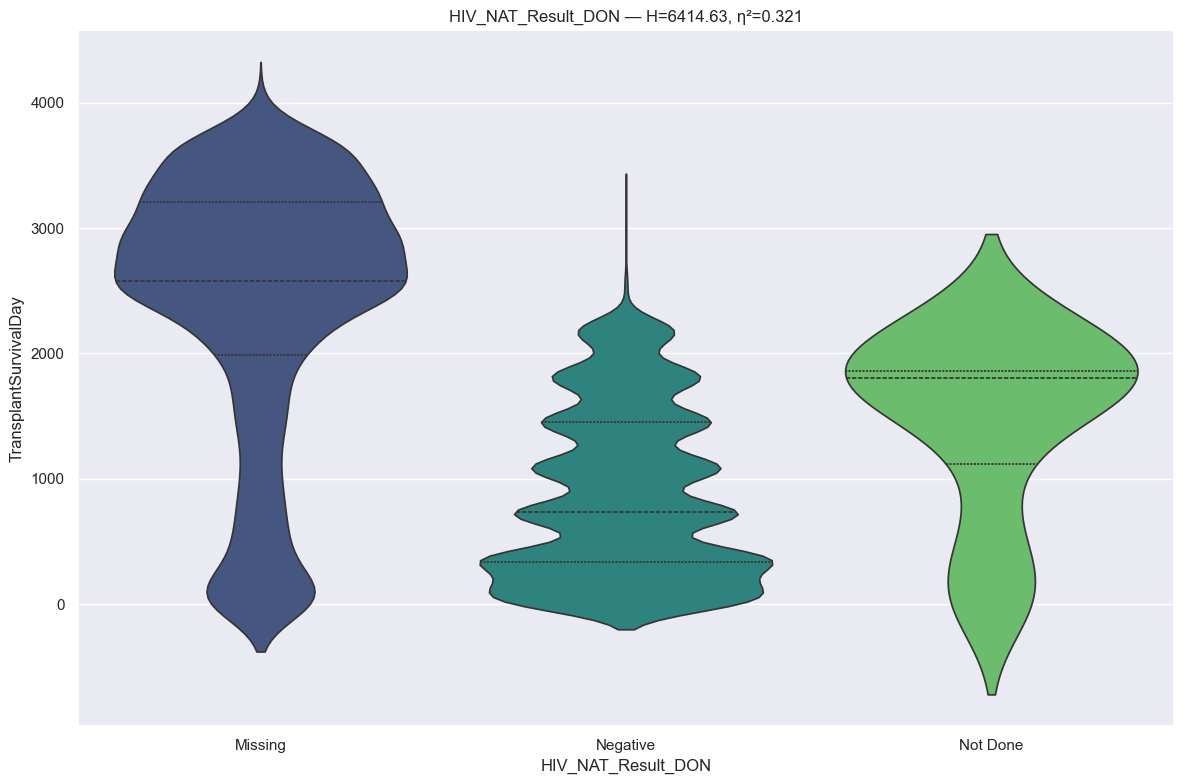

RANKING REPORT: HIV_NAT_Result_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :   6008 records
 * Negative                                          :  13963 records
 * Not Done                                          :     36 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 6414.6274 | P-value: 0.000000e+00 | Effect η²: 0.3206
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs Negative     | p=0.0000e+00 | thr=0.0167 | r=-0.713 | *Sig*
Missing      vs Not Done     | p=5.3272e-10 | thr=0.0167 | r=-0.599 | *Sig*
Negative     vs Not Done     | p=2.8547e-06 | thr=0.0167 | r= 0.451 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [214]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [215]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'Negative': 'Group_2', 'Not Done': 'Group_3'}


,HIV_NAT_Result_DON,mean_survival_days,record_count
1,Negative,875.336103,13963
0,Missing,2374.868675,6008
2,Not Done,1471.027778,36


#### Allocation Type

In [216]:
# info
features = u.get_feature_info(df, 'AllocationType', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique    top   freq
AllocationType_DON  20007      4  Local  10841

:::: NaN Count:
AllocationType_DON    0 



{'AllocationType_DON': CategoricalDtype(categories=['Foreign Donor', 'Local', 'National', 'Regional'], ordered=False, categories_dtype=object)}

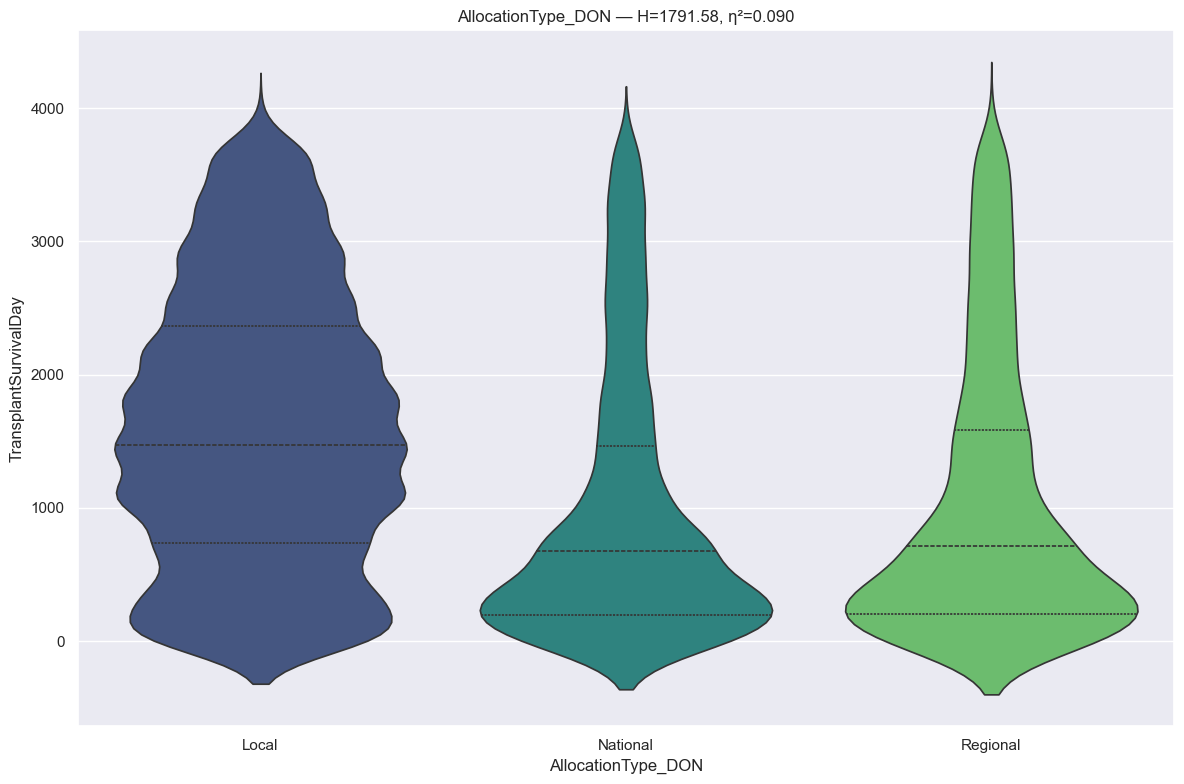

RANKING REPORT: AllocationType_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Local                                             :  10841 records
 * National                                          :   5474 records
 * Regional                                          :   3674 records
BYPASSED CATEGORIES (n < min_n):
 * Foreign Donor                                     :     18 records
--------------------------------------------------------------------------------
Kruskal H: 1791.5771 | P-value: 0.000000e+00 | Effect η²: 0.0895
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Local        vs National     | p=1.7765e-308 | thr=0.0167 | r=-0.359 | *Sig*
Local        vs Regional     | p=3.0850e-193 | thr=0.0167 | r=-0.327 | *Sig*
National     vs Regional     | p=1.7308e-02 | thr=0.0167 | r= 0.029 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [217]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [218]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Local': 'Group_1', 'National': 'Group_2', 'Regional': 'Group_2', 'Foreign Donor': 'Other'}


,AllocationType_DON,mean_survival_days,record_count
1,Local,1597.345356,10841
2,National,984.070698,5474
3,Regional,1037.985846,3674
0,Foreign Donor,1461.222222,18


In [219]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="fdr",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: AllocationType_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Local                                             :  10841 records
 * National                                          :   5474 records
 * Regional                                          :   3674 records
BYPASSED CATEGORIES (n < min_n):
 * Foreign Donor                                     :     18 records
--------------------------------------------------------------------------------
Kruskal H: 1791.5771 | P-value: 0.000000e+00 | Effect η²: 0.0895
Correction Method: FDR
Pairwise Testing (Base Alpha: 0.05 | Method: FDR | r_threshold: 0.10)
--------------------------------------------------------------------------------
Local        vs National     | p=1.7765e-308 | fdr_alpha=0.05 | r=-0.359 | *Sig*
Local        vs Regional     | p=3.0850e-193 | fdr_alpha=0.05 | r=-0.327 | *Sig*
National     vs Regional     | p=1.7308e-02 | fdr_alpha=0.05 | r= 0.029 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [220]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Local': 'Group_1', 'National': 'Group_2', 'Regional': 'Group_3', 'Foreign Donor': 'Other'}


,AllocationType_DON,mean_survival_days,record_count
1,Local,1597.345356,10841
2,National,984.070698,5474
3,Regional,1037.985846,3674
0,Foreign Donor,1461.222222,18


#### Urine Portein

In [221]:
# info
features = u.get_feature_info(df, 'UrinePortein', cat=False)
# dtype
{col: df[col].dtype for col in features}

                  count unique top   freq
UrinePortein_DON  20007      4  No  10403

:::: NaN Count:
UrinePortein_DON    0 



{'UrinePortein_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

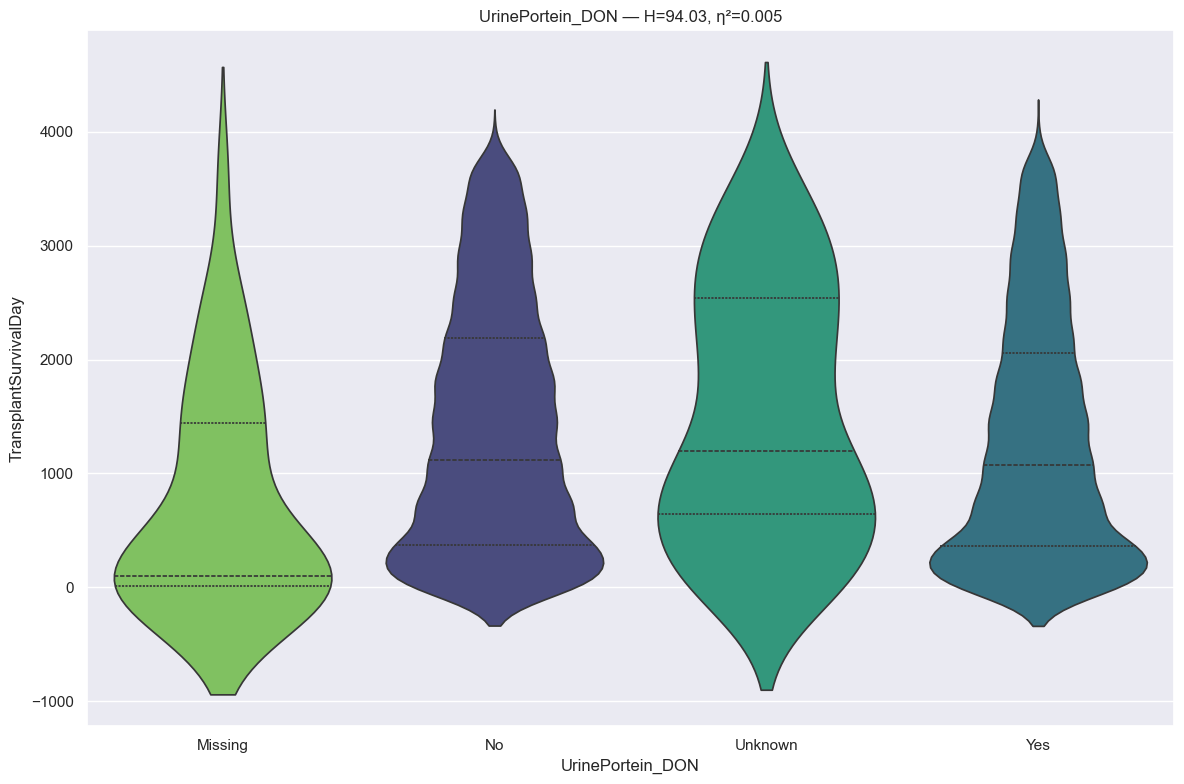

RANKING REPORT: UrinePortein_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  10403 records
 * Unknown                                           :     93 records
 * Yes                                               :   9473 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 94.0278 | P-value: 2.987084e-20 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.4520e-17 | thr=0.0083 | r=-0.070 | *Sig*
Missing      vs No           | p=3.4993e-06 | thr=0.0083 | r= 0.435 | *Sig*
Missing      vs Yes          | p=2.8516e-05 | thr=0.0083 | r= 0.393 | *Sig*
Missing      vs Unknown      | p=3.5685e-05 | thr=0.0083 | r= 0.462 | *Sig*
Unknown 

In [222]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [223]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Unknown': 'Group_2', 'Yes': 'Group_3'}


,UrinePortein_DON,mean_survival_days,record_count
1,No,1384.927521,10403
3,Yes,1263.557268,9473
2,Unknown,1488.150538,93
0,Missing,737.078947,38


#### Cardiac Arrest

In [224]:
# info
features = u.get_feature_info(df, 'CardiacArrest', cat=False)
# dtype
{col: df[col].dtype for col in features}

                   count unique top   freq
CardiacArrest_DON  20007      3  No  18354

:::: NaN Count:
CardiacArrest_DON    0 



{'CardiacArrest_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

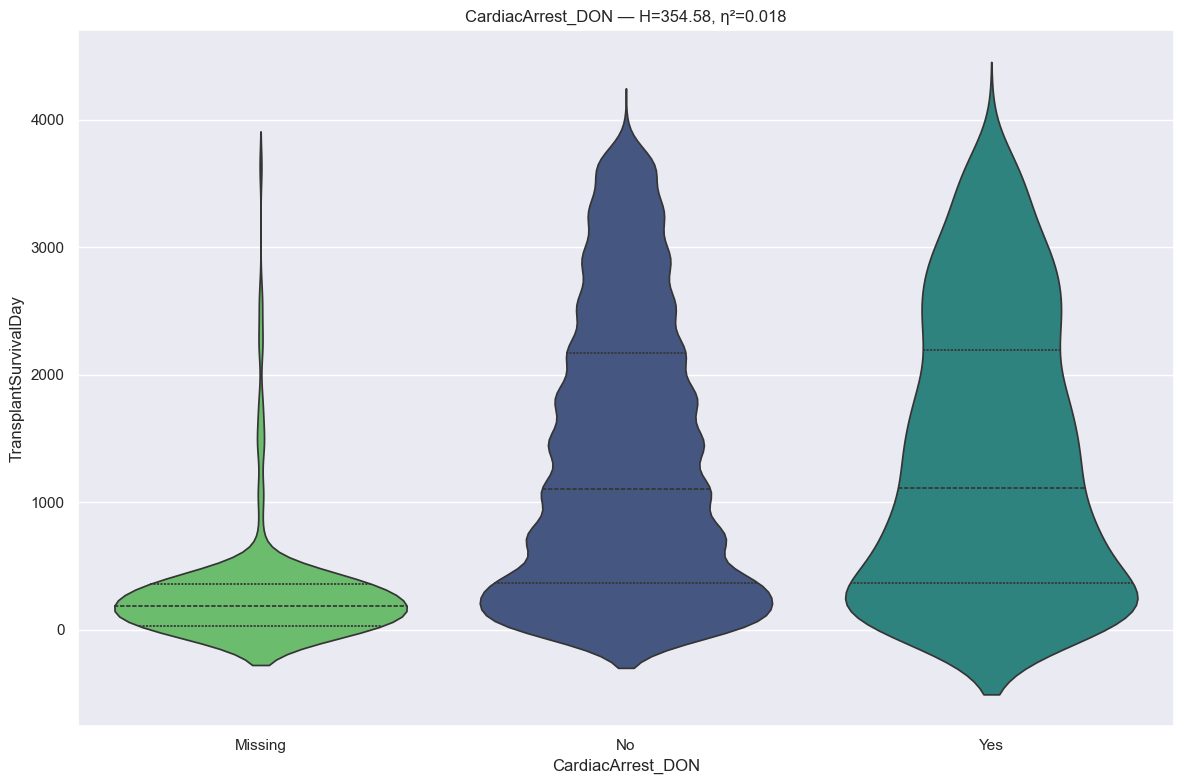

RANKING REPORT: CardiacArrest_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :    275 records
 * No                                                :  18354 records
 * Yes                                               :   1378 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 354.5800 | P-value: 1.009090e-77 | Effect η²: 0.0176
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Missing      vs No           | p=3.7899e-79 | thr=0.0167 | r= 0.661 | *Sig*
Missing      vs Yes          | p=4.8727e-65 | thr=0.0167 | r= 0.650 | *Sig*
No           vs Yes          | p=6.1876e-01 | thr=0.0167 | r= 0.008 | Not Sig
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [225]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [226]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_2'}


,CardiacArrest_DON,mean_survival_days,record_count
1,No,1339.703225,18354
2,Yes,1363.173440,1378
0,Missing,276.800000,275


#### Myocardial Infarction History

In [227]:
# info
features = u.get_feature_info(df, 'MyocardialInfarctionHistory', cat=False)
# dtype
{col: df[col].dtype for col in features}

                                 count unique top   freq
MyocardialInfarctionHistory_DON  20007      4  No  19660

:::: NaN Count:
MyocardialInfarctionHistory_DON    0 



{'MyocardialInfarctionHistory_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

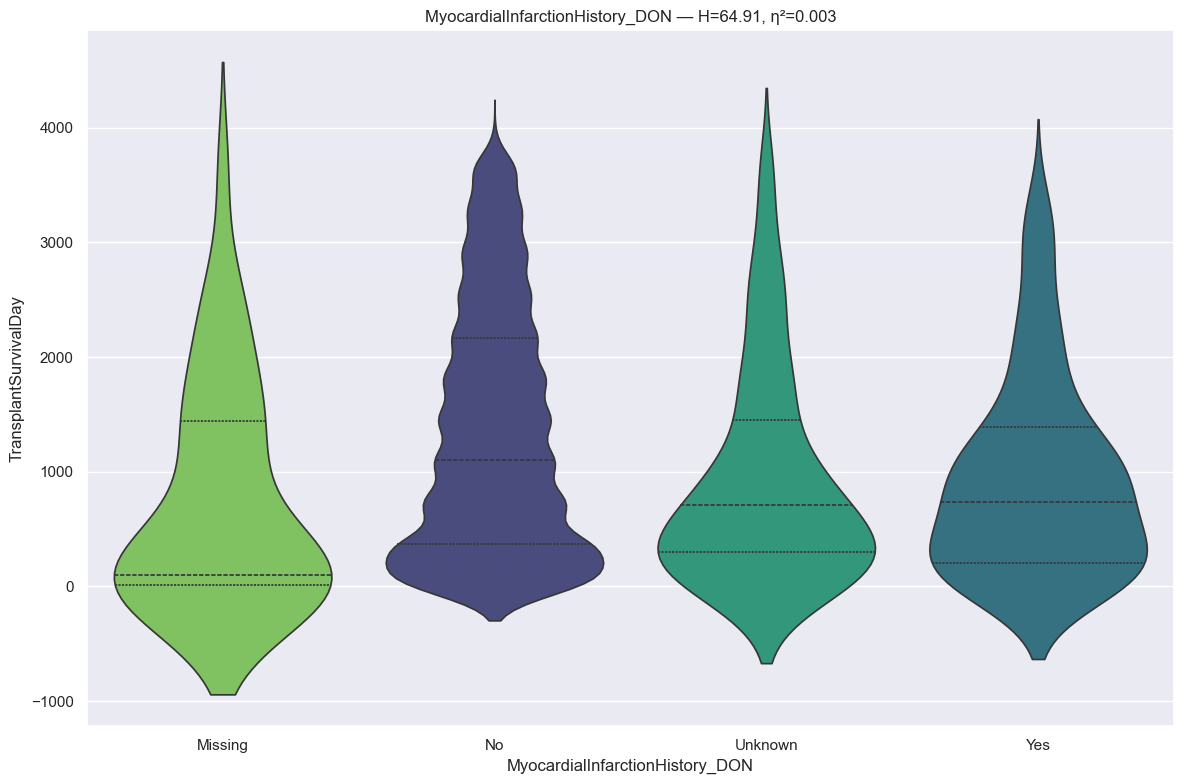

RANKING REPORT: MyocardialInfarctionHistory_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  19660 records
 * Unknown                                           :    161 records
 * Yes                                               :    148 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 64.9067 | P-value: 5.251866e-14 | Effect η²: 0.0031
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Unknown      | p=2.5512e-07 | thr=0.0083 | r=-0.235 | *Sig*
Missing      vs No           | p=8.3832e-06 | thr=0.0083 | r= 0.418 | *Sig*
No           vs Yes          | p=1.2274e-05 | thr=0.0083 | r=-0.208 | *Sig*
Missing      vs Yes          | p=1.1677e-02 | thr=0.0083 | r= 0.266 |

In [228]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [229]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Unknown': 'Group_3', 'Yes': 'Group_3'}


,MyocardialInfarctionHistory_DON,mean_survival_days,record_count
1,No,1334.168769,19660
2,Unknown,911.981366,161
3,Yes,938.445946,148
0,Missing,737.078947,38


#### LV Ejection Fraction Medthod

In [230]:
# info
features = u.get_feature_info(df, 'LV_EjectionFractionMedthod', cat=False)
# dtype
{col: df[col].dtype for col in features}

                                count unique   top   freq
LV_EjectionFractionMedthod_DON  20007      3  Echo  19588

:::: NaN Count:
LV_EjectionFractionMedthod_DON    0 



{'LV_EjectionFractionMedthod_DON': CategoricalDtype(categories=['Angiogram', 'Echo', 'Missing'], ordered=False, categories_dtype=object)}

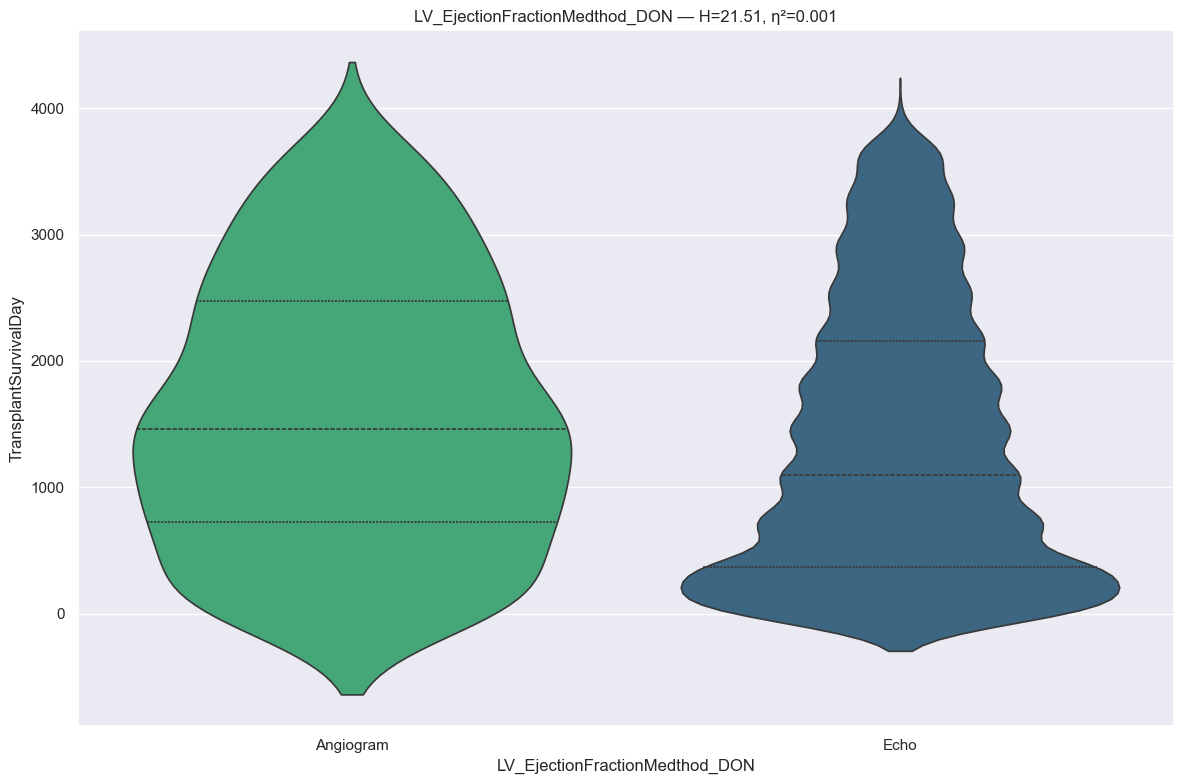

RANKING REPORT: LV_EjectionFractionMedthod_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Angiogram                                         :    392 records
 * Echo                                              :  19588 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     27 records
--------------------------------------------------------------------------------
Kruskal H: 21.5136 | P-value: 3.513237e-06 | Effect η²: 0.0010
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Angiogram    vs Echo         | p=3.5133e-06 | thr=0.0500 | r=-0.137 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [231]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [232]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Angiogram': 'Group_1', 'Echo': 'Group_2', 'Missing': 'Other'}


,LV_EjectionFractionMedthod_DON,mean_survival_days,record_count
1,Echo,1321.216765,19588
0,Angiogram,1568.992347,392
2,Missing,1794.333333,27


#### Coronary Angiogram

In [233]:
# info
features = u.get_feature_info(df, 'CoronaryAngiogram', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique top   freq
CoronaryAngiogram_DON  20007      4  No  13074

:::: NaN Count:
CoronaryAngiogram_DON    0 



{'CoronaryAngiogram_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes, normal', 'Yes, not normal'], ordered=False, categories_dtype=object)}

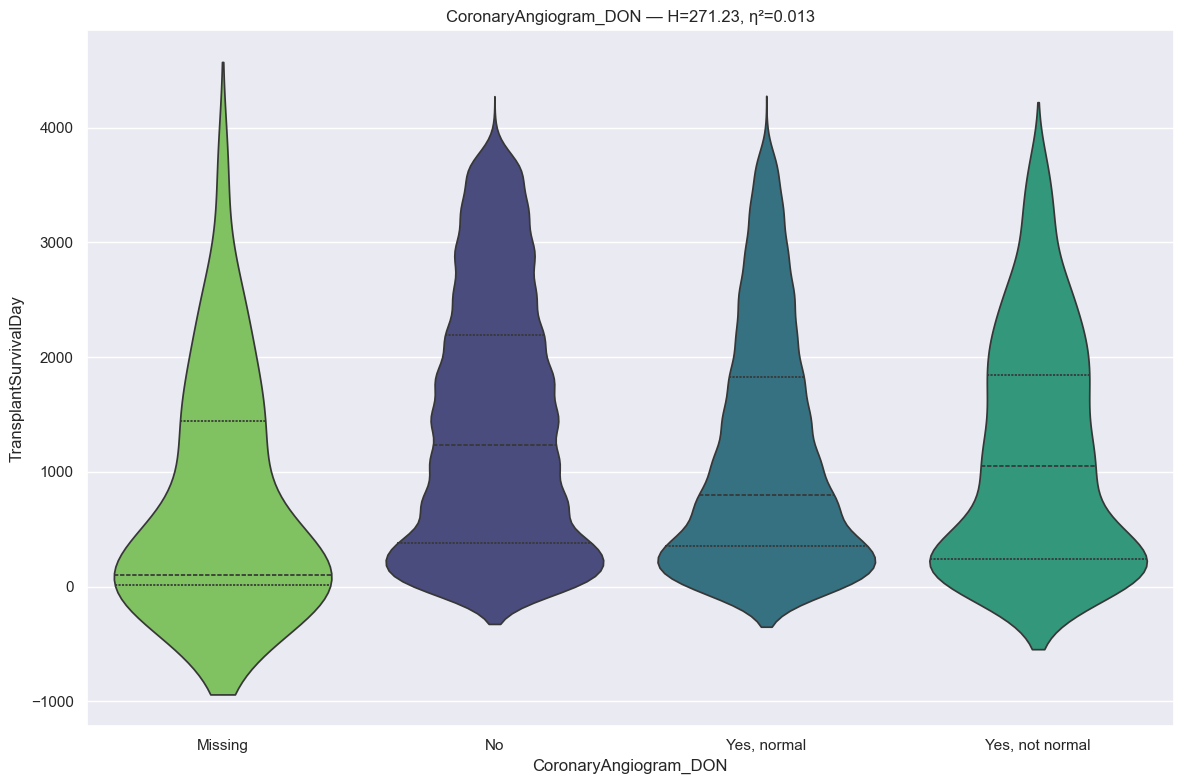

RANKING REPORT: CoronaryAngiogram_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  13074 records
 * Yes, normal                                       :   6222 records
 * Yes, not normal                                   :    673 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 271.2267 | P-value: 1.675236e-58 | Effect η²: 0.0134
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes, normal  | p=1.4356e-52 | thr=0.0083 | r=-0.136 | *Sig*
No           vs Yes, not normal | p=4.1029e-10 | thr=0.0083 | r=-0.143 | *Sig*
Missing      vs No           | p=2.0882e-06 | thr=0.0083 | r= 0.445 | *Sig*
Missing      vs Yes, normal  | p=1.3245e-04 | thr=0.0083 | r= 0.359 | *Sig*

In [234]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [235]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes, normal': 'Group_3', 'Yes, not normal': 'Group_3'}


,CoronaryAngiogram_DON,mean_survival_days,record_count
1,No,1416.632630,13074
2,"Yes, normal",1160.026840,6222
3,"Yes, not normal",1154.138187,673
0,Missing,737.078947,38


#### Biopsy

In [236]:
# info
features = u.get_feature_info(df, 'Biopsy', cat=False)
# dtype
{col: df[col].dtype for col in features}

            count unique              top   freq
Biopsy_DON  20007      5  Biopsy not done  19947

:::: NaN Count:
Biopsy_DON    0 



{'Biopsy_DON': CategoricalDtype(categories=['Biopsy not done', 'Missing', 'Unknown',
                   'Yes, rejection confirmed', 'Yes, rejection not confirmed'],
 , ordered=False, categories_dtype=object)}

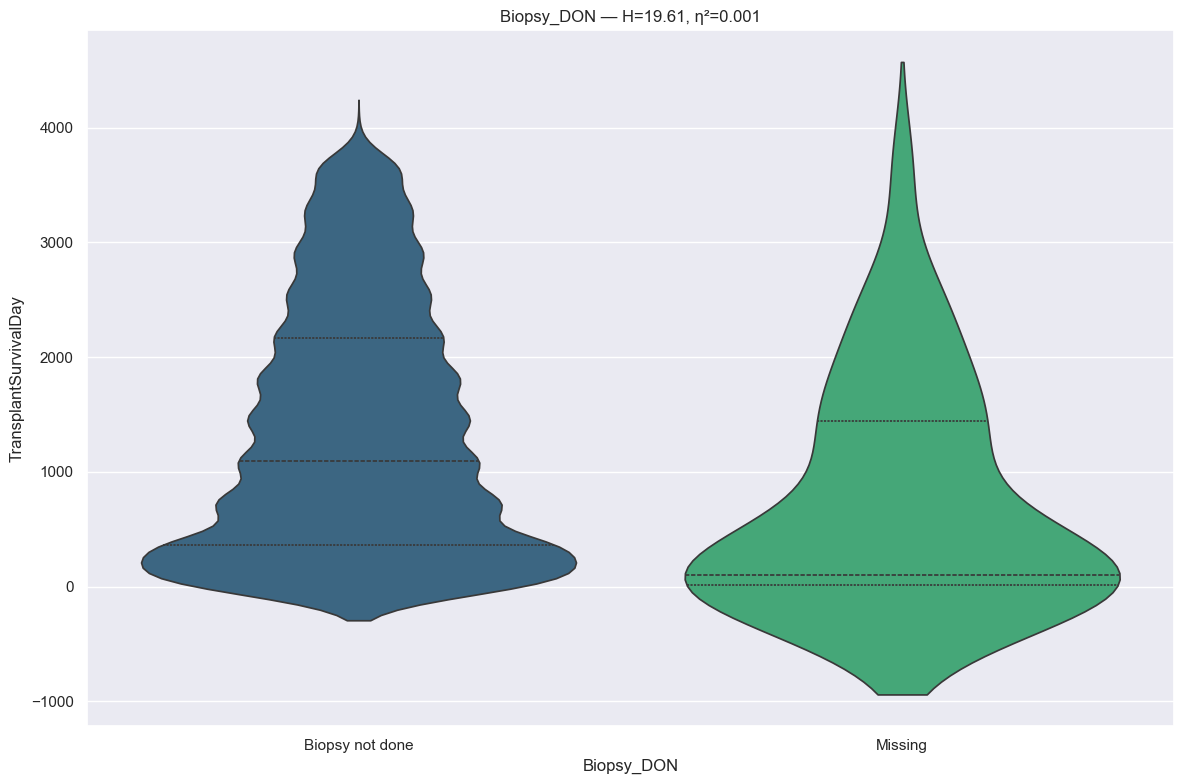

RANKING REPORT: Biopsy_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Biopsy not done                                   :  19947 records
 * Missing                                           :     38 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :      6 records
 * Yes, rejection confirmed                          :      8 records
 * Yes, rejection not confirmed                      :      8 records
--------------------------------------------------------------------------------
Kruskal H: 19.6129 | P-value: 9.482535e-06 | Effect η²: 0.0009
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Biopsy not done vs Missing      | p=9.4832e-06 | thr=0.0500 | r=-0.415 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [237]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [238]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Biopsy not done': 'Group_1', 'Missing': 'Group_2', 'Unknown': 'Other', 'Yes, rejection confirmed': 'Other', 'Yes, rejection not confirmed': 'Other'}


,Biopsy_DON,mean_survival_days,record_count
0,Biopsy not done,1327.675991,19947
1,Missing,737.078947,38
3,"Yes, rejection confirmed",1530.375000,8
4,"Yes, rejection not confirmed",1697.500000,8
2,Unknown,1083.500000,6


In [239]:
# mapping
mapping = {'Yes, rejection confirmed': 'Other',
           'Yes, rejection not confirmed': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,Biopsy_DON,mean_survival_days,record_count
0,Biopsy not done,1327.675991,19947
1,Missing,737.078947,38
2,Other,1469.272727,22


#### Tatoos

In [240]:
# info
features = u.get_feature_info(df, 'Tatoos', cat=False)
# dtype
{col: df[col].dtype for col in features}

            count unique  top   freq
Tatoos_DON  20007      4  Yes  11191

:::: NaN Count:
Tatoos_DON    0 



{'Tatoos_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

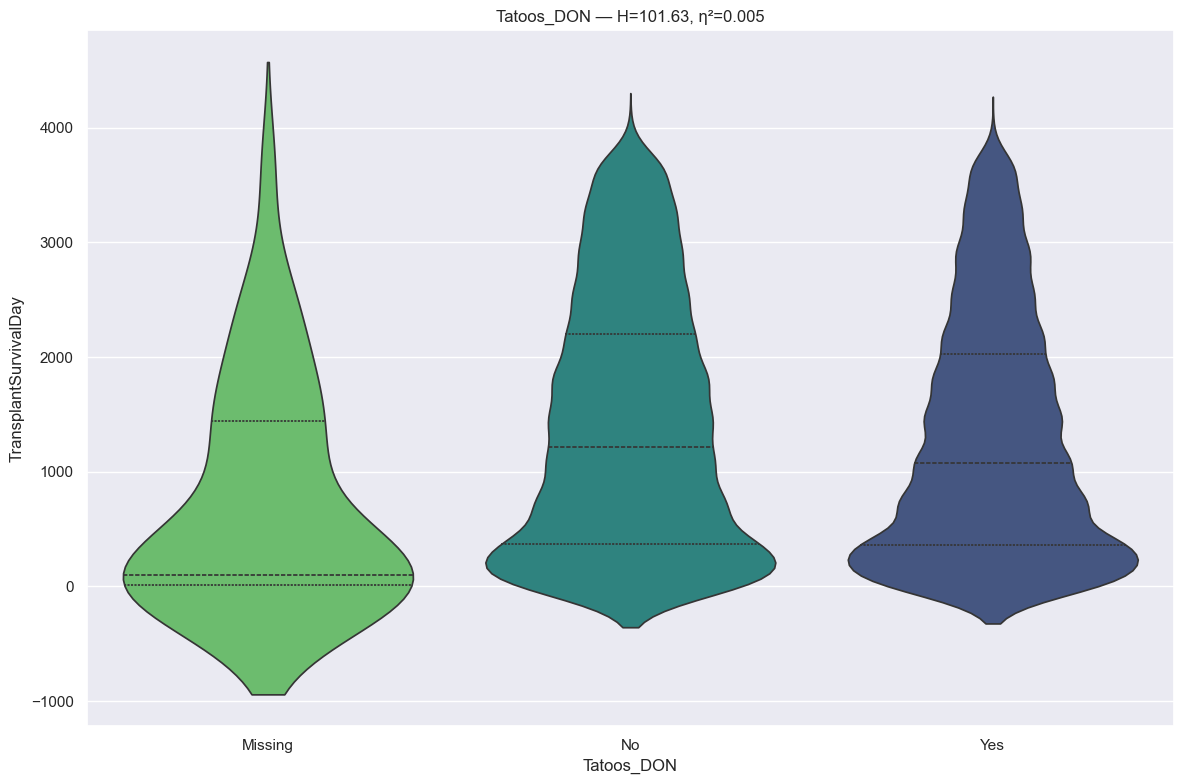

RANKING REPORT: Tatoos_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :   8760 records
 * Yes                                               :  11191 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     18 records
--------------------------------------------------------------------------------
Kruskal H: 101.6288 | P-value: 8.542387e-23 | Effect η²: 0.0050
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.2749e-19 | thr=0.0167 | r=-0.075 | *Sig*
Missing      vs No           | p=2.6282e-06 | thr=0.0167 | r= 0.441 | *Sig*
Missing      vs Yes          | p=2.5368e-05 | thr=0.0167 | r= 0.395 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [241]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [242]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,Tatoos_DON,mean_survival_days,record_count
3,Yes,1262.301492,11191
1,No,1411.952055,8760
0,Missing,737.078947,38
2,Unknown,1131.166667,18


In [243]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,Tatoos_DON,mean_survival_days,record_count
2,Yes,1262.301492,11191
0,No,1411.952055,8760
1,Other,863.750000,56


In [244]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: Tatoos_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :   8760 records
 * Other                                             :     56 records
 * Yes                                               :  11191 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 97.5370 | P-value: 6.608733e-22 | Effect η²: 0.0048
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.2749e-19 | thr=0.0167 | r=-0.075 | *Sig*
No           vs Other        | p=1.3940e-05 | thr=0.0167 | r=-0.336 | *Sig*
Other        vs Yes          | p=3.0461e-04 | thr=0.0167 | r= 0.279 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [245]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Other': 'Group_2', 'Yes': 'Group_3'}


,Tatoos_DON,mean_survival_days,record_count
2,Yes,1262.301492,11191
0,No,1411.952055,8760
1,Other,863.750000,56


#### Antibody Result HBSAB

In [246]:
# info
features = u.get_feature_info(df, 'AntibodyResultHBSAB', cat=False)
# dtype
{col: df[col].dtype for col in features}

                         count unique       top   freq
AntibodyResultHBSAB_DON  20007      6  Not Done  16937

:::: NaN Count:
AntibodyResultHBSAB_DON    0 



{'AntibodyResultHBSAB_DON': CategoricalDtype(categories=['Cannot Disclose', 'Indeterminate', 'Missing', 'Negative',
                   'Not Done', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

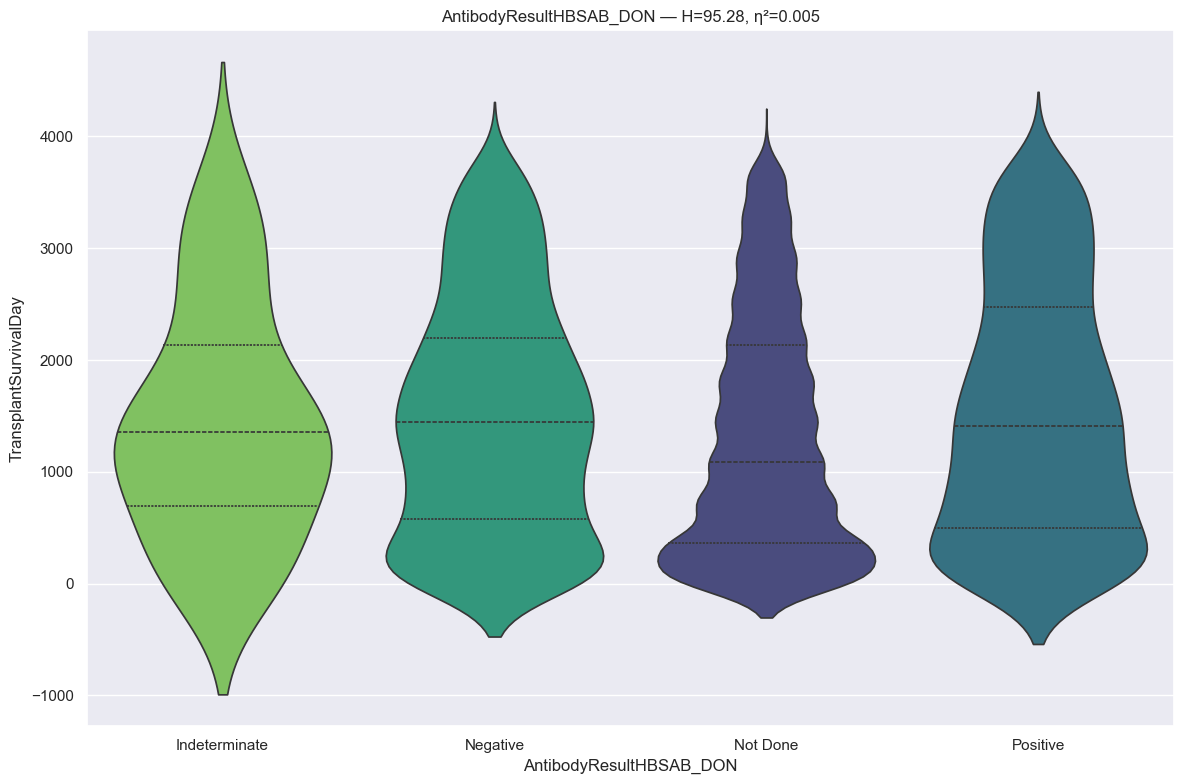

RANKING REPORT: AntibodyResultHBSAB_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     38 records
 * Negative                                          :   1800 records
 * Not Done                                          :  16937 records
 * Positive                                          :   1209 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     19 records
 * Unknown                                           :      4 records
--------------------------------------------------------------------------------
Kruskal H: 95.2762 | P-value: 1.610478e-20 | Effect η²: 0.0046
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=2.7600e-14 | thr=0.0083 | r=-0.109 | *Sig*
Not Done     vs Positive     | p=2.7357e-11 | thr=0.0083 | r= 0.114 | *Sig*
Indete

In [247]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [248]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_1', 'Not Done': 'Group_1', 'Positive': 'Group_1', 'Missing': 'Other', 'Unknown': 'Other'}


,AntibodyResultHBSAB_DON,mean_survival_days,record_count
3,Not Done,1296.121037,16937
2,Negative,1487.124444,1800
4,Positive,1516.790736,1209
0,Indeterminate,1430.631579,38
1,Missing,1064.421053,19
5,Unknown,1468.000000,4


In [249]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,AntibodyResultHBSAB_DON,mean_survival_days,record_count
2,Not Done,1296.121037,16937
1,Negative,1487.124444,1800
4,Positive,1516.790736,1209
0,Indeterminate,1430.631579,38
3,Other,1134.608696,23


#### EpsteinBarr IGG

In [250]:
# info
features = u.get_feature_info(df, 'EpsteinBarr_IGG', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique       top   freq
EpsteinBarr_IGG_DON  20007      7  Positive  17656

:::: NaN Count:
EpsteinBarr_IGG_DON    0 



{'EpsteinBarr_IGG_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

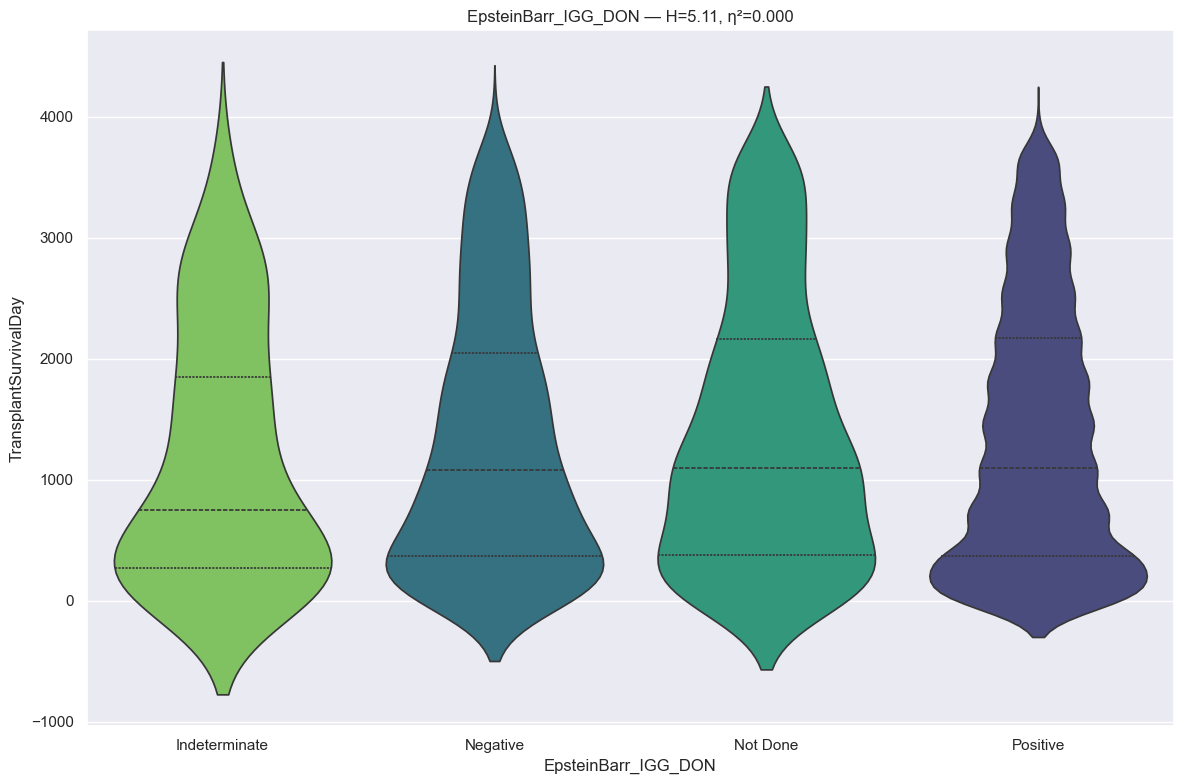

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :    133 records
 * Negative                                          :   1394 records
 * Not Done                                          :    805 records
 * Positive                                          :  17656 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     16 records
 * Pending                                           :      2 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 5.1050 | P-value: 1.642660e-01 | Effect η²: 0.0001
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Indeterminate vs Not Done     | p=4.2575e-02 | thr=0.0083 | r= 0.110 | Not Sig
Indeterminate 

In [251]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [252]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_1', 'Not Done': 'Group_1', 'Positive': 'Group_1', 'Missing': 'Other', 'Pending': 'Other', 'Unknown': 'Other'}


,EpsteinBarr_IGG_DON,mean_survival_days,record_count
5,Positive,1328.108009,17656
2,Negative,1296.230990,1394
3,Not Done,1371.791304,805
0,Indeterminate,1185.022556,133
1,Missing,1389.375000,16
4,Pending,1660.500000,2
6,Unknown,14.000000,1


In [253]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: EpsteinBarr_IGG_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :    133 records
 * Negative                                          :   1394 records
 * Not Done                                          :    805 records
 * Positive                                          :  17656 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     16 records
 * Pending                                           :      2 records
 * Unknown                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 5.1050 | P-value: 1.642660e-01 | Effect η²: 0.0001
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
Indeterminate vs Not Done     | p=4.2575e-02 | thr=0.0083 | r= 0.110 | Not Sig
Indeterminate

In [254]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_2', 'Not Done': 'Group_2', 'Positive': 'Group_2', 'Missing': 'Other', 'Pending': 'Other', 'Unknown': 'Other'}


,EpsteinBarr_IGG_DON,mean_survival_days,record_count
5,Positive,1328.108009,17656
2,Negative,1296.230990,1394
3,Not Done,1371.791304,805
0,Indeterminate,1185.022556,133
1,Missing,1389.375000,16
4,Pending,1660.500000,2
6,Unknown,14.000000,1


In [255]:
# mapping
mapping = {'Missing': 'Other',
           'Pending': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,EpsteinBarr_IGG_DON,mean_survival_days,record_count
4,Positive,1328.108009,17656
1,Negative,1296.230990,1394
2,Not Done,1371.791304,805
0,Indeterminate,1185.022556,133
3,Other,1345.526316,19


#### EpsteinBarr IGM

In [256]:
# info
features = u.get_feature_info(df, 'EpsteinBarr_IGM', cat=False)
# dtype
{col: df[col].dtype for col in features}

                     count unique       top   freq
EpsteinBarr_IGM_DON  20007      7  Negative  15998

:::: NaN Count:
EpsteinBarr_IGM_DON    0 



{'EpsteinBarr_IGM_DON': CategoricalDtype(categories=['Indeterminate', 'Missing', 'Negative', 'Not Done',
                   'Pending', 'Positive', 'Unknown'],
 , ordered=False, categories_dtype=object)}

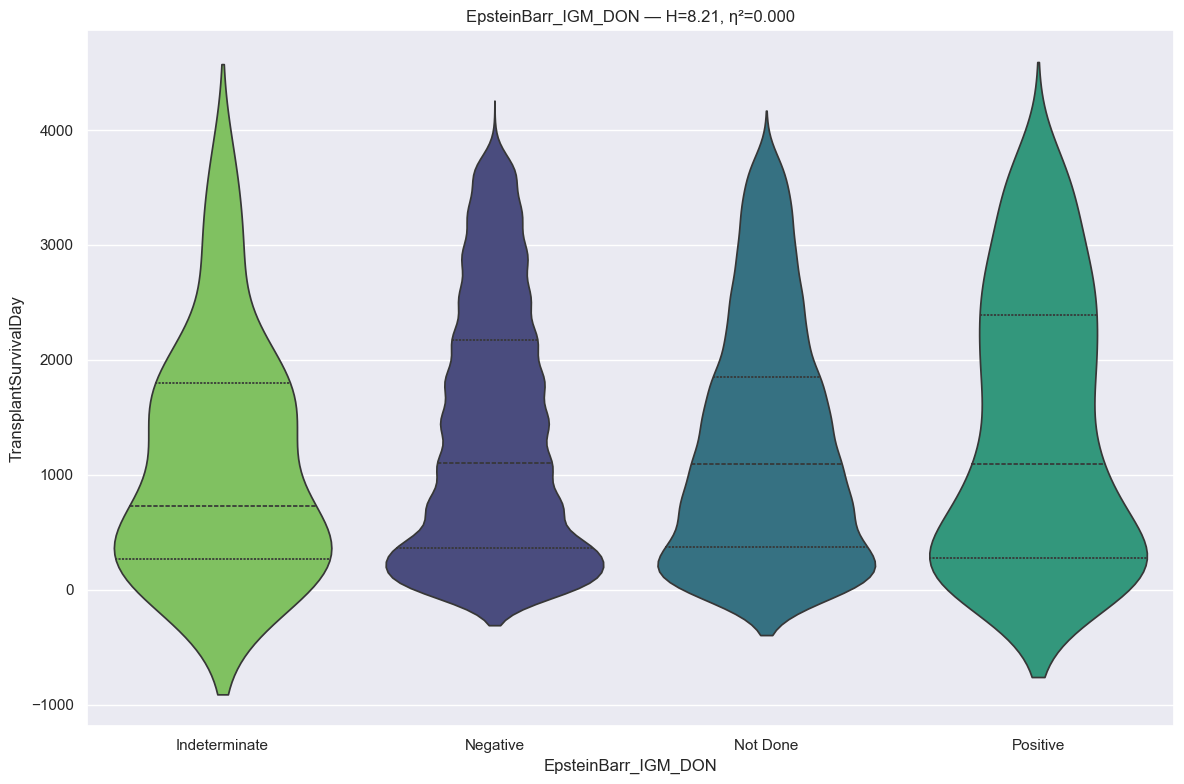

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     46 records
 * Negative                                          :  15998 records
 * Not Done                                          :   3674 records
 * Positive                                          :    266 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     19 records
 * Pending                                           :      1 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 8.2092 | P-value: 4.188052e-02 | Effect η²: 0.0003
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=1.2565e-02 | thr=0.0083 | r=-0.026 | Not Sig
Indeterminate v

In [257]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [258]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_1', 'Not Done': 'Group_1', 'Positive': 'Group_1', 'Missing': 'Other', 'Pending': 'Other', 'Unknown': 'Other'}


,EpsteinBarr_IGM_DON,mean_survival_days,record_count
2,Negative,1338.416740,15998
3,Not Done,1273.476320,3674
5,Positive,1391.097744,266
0,Indeterminate,1113.804348,46
1,Missing,1291.210526,19
6,Unknown,1565.666667,3
4,Pending,2246.000000,1


In [259]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: EpsteinBarr_IGM_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Indeterminate                                     :     46 records
 * Negative                                          :  15998 records
 * Not Done                                          :   3674 records
 * Positive                                          :    266 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     19 records
 * Pending                                           :      1 records
 * Unknown                                           :      3 records
--------------------------------------------------------------------------------
Kruskal H: 8.2092 | P-value: 4.188052e-02 | Effect η²: 0.0003
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
Negative     vs Not Done     | p=1.2565e-02 | thr=0.0083 | r=-0.026 | Not Sig
Indeterminate 

In [260]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Indeterminate': 'Group_1', 'Negative': 'Group_2', 'Not Done': 'Group_2', 'Positive': 'Group_2', 'Missing': 'Other', 'Pending': 'Other', 'Unknown': 'Other'}


,EpsteinBarr_IGM_DON,mean_survival_days,record_count
2,Negative,1338.416740,15998
3,Not Done,1273.476320,3674
5,Positive,1391.097744,266
0,Indeterminate,1113.804348,46
1,Missing,1291.210526,19
6,Unknown,1565.666667,3
4,Pending,2246.000000,1


In [261]:
# mapping
mapping = {'Missing': 'Other',
           'Pending': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,EpsteinBarr_IGM_DON,mean_survival_days,record_count
1,Negative,1338.416740,15998
2,Not Done,1273.476320,3674
4,Positive,1391.097744,266
0,Indeterminate,1113.804348,46
3,Other,1368.521739,23


#### HIV Risk

In [262]:
# info
features = u.get_feature_info(df, 'HIV_Risk', cat=False)
# dtype
{col: df[col].dtype for col in features}

              count unique top   freq
HIV_Risk_DON  20007      4  No  14486

:::: NaN Count:
HIV_Risk_DON    0 



{'HIV_Risk_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

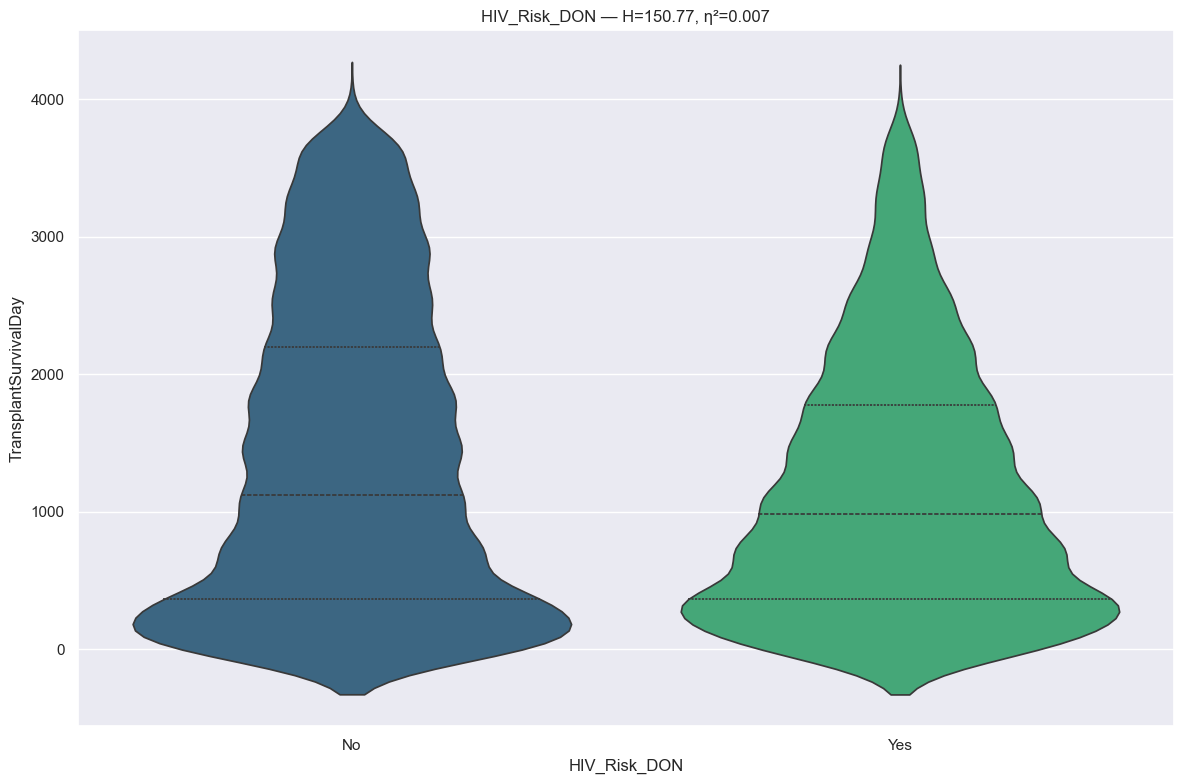

RANKING REPORT: HIV_Risk_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  14486 records
 * Yes                                               :   5511 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      3 records
 * Unknown                                           :      7 records
--------------------------------------------------------------------------------
Kruskal H: 150.7673 | P-value: 1.178285e-34 | Effect η²: 0.0075
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=1.1783e-34 | thr=0.0500 | r=-0.112 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [263]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [264]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other', 'Unknown': 'Other'}


,HIV_Risk_DON,mean_survival_days,record_count
1,No,1398.319757,14486
3,Yes,1138.341862,5511
2,Unknown,1465.000000,7
0,Missing,1256.333333,3


In [265]:
# mapping
mapping = {'Missing': 'Other',
           'Unknown': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,HIV_Risk_DON,mean_survival_days,record_count
0,No,1398.319757,14486
2,Yes,1138.341862,5511
1,Other,1402.400000,10


#### Inotropic Agent

In [266]:
# info
features = u.get_feature_info(df, 'InotropicAgent', cat=False)
# dtype
{col: df[col].dtype for col in features}

                    count unique      top   freq
InotropicAgent_DON  20007      7  Missing  12248

:::: NaN Count:
InotropicAgent_DON    0 



{'InotropicAgent_DON': CategoricalDtype(categories=['Dobutamine', 'Dopamine', 'Epinephrine', 'Levophed',
                   'Missing', 'Neosynephrine', 'Other, specify'],
 , ordered=False, categories_dtype=object)}

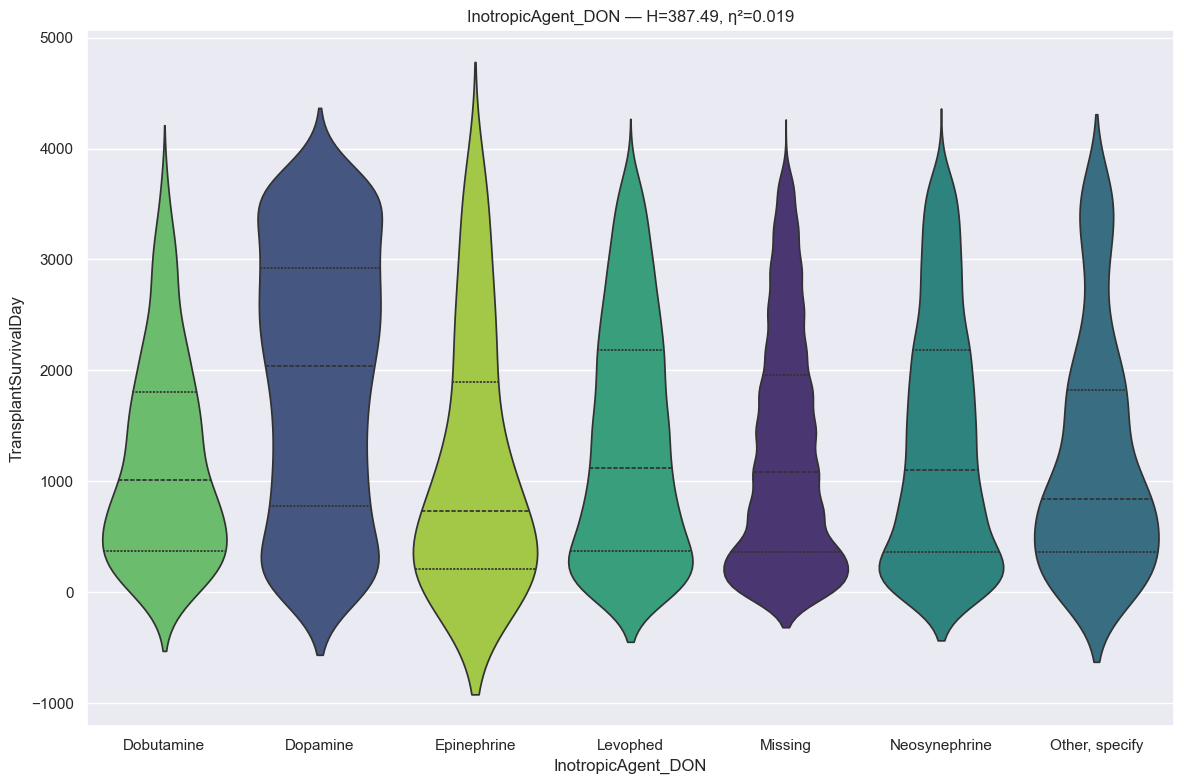

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    451 records
 * Dopamine                                          :   1340 records
 * Epinephrine                                       :     88 records
 * Levophed                                          :   2289 records
 * Missing                                           :  12248 records
 * Neosynephrine                                     :   3135 records
 * Other, specify                                    :    456 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 387.4903 | P-value: 1.366034e-80 | Effect η²: 0.0191
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Dopamine     vs Missing      | p=3.7662e-81 | thr=0.0024 | r=-0.317 | *Sig*
Dopamine     vs Neosyne

In [267]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [268]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Dobutamine': 'Group_1', 'Epinephrine': 'Group_1', 'Levophed': 'Group_1', 'Missing': 'Group_1', 'Neosynephrine': 'Group_1', 'Other, specify': 'Group_1', 'Dopamine': 'Group_2'}


,InotropicAgent_DON,mean_survival_days,record_count
4,Missing,1254.593403,12248
5,Neosynephrine,1361.118341,3135
3,Levophed,1375.228921,2289
1,Dopamine,1912.987313,1340
6,"Other, specify",1241.239035,456
0,Dobutamine,1176.977827,451
2,Epinephrine,1159.045455,88


In [269]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: InotropicAgent_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Dobutamine                                        :    451 records
 * Dopamine                                          :   1340 records
 * Epinephrine                                       :     88 records
 * Levophed                                          :   2289 records
 * Missing                                           :  12248 records
 * Neosynephrine                                     :   3135 records
 * Other, specify                                    :    456 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 387.4903 | P-value: 1.366034e-80 | Effect η²: 0.0191
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
Dopamine     vs Missing      | p=3.7662e-81 | thr=0.0024 | r=-0.317 | *Sig*
Dopamine     vs Neosyn

In [270]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Dobutamine': 'Group_1', 'Missing': 'Group_1', 'Other, specify': 'Group_1', 'Dopamine': 'Group_2', 'Epinephrine': 'Group_3', 'Levophed': 'Group_4', 'Neosynephrine': 'Group_4'}


,InotropicAgent_DON,mean_survival_days,record_count
4,Missing,1254.593403,12248
5,Neosynephrine,1361.118341,3135
3,Levophed,1375.228921,2289
1,Dopamine,1912.987313,1340
6,"Other, specify",1241.239035,456
0,Dobutamine,1176.977827,451
2,Epinephrine,1159.045455,88


#### Kidney Allocation

In [271]:
# info
features = u.get_feature_info(df, 'KidneyAllocation', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique top   freq
KidneyAllocation_DON  20007      3  No  19576

:::: NaN Count:
KidneyAllocation_DON    0 



{'KidneyAllocation_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

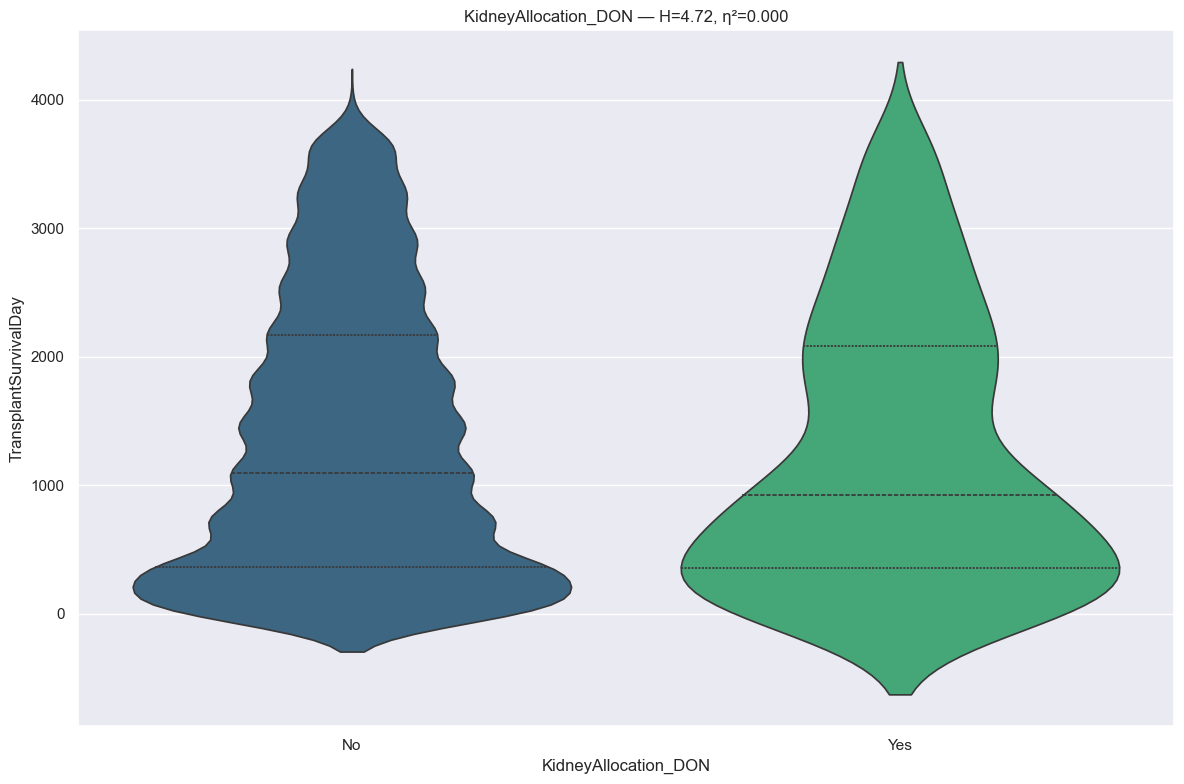

RANKING REPORT: KidneyAllocation_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * No                                                :  19576 records
 * Yes                                               :    429 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :      2 records
--------------------------------------------------------------------------------
Kruskal H: 4.7187 | P-value: 2.983702e-02 | Effect η²: 0.0002
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0500 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=2.9837e-02 | thr=0.0500 | r=-0.061 | *Sig*
::::: Collapsed into 2 groups (excluding 'Other') :::::



In [272]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [273]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'No': 'Group_1', 'Yes': 'Group_2', 'Missing': 'Other'}


,KidneyAllocation_DON,mean_survival_days,record_count
1,No,1328.959951,19576
2,Yes,1226.638695,429
0,Missing,769.000000,2


#### Inotropic Medication Procurement

In [274]:
# info
features = u.get_feature_info(df, 'InotropicMedicationProcurement', cat=False)
# dtype
{col: df[col].dtype for col in features}

                                    count unique top   freq
InotropicMedicationProcurement_DON  20007      4  No  12182

:::: NaN Count:
InotropicMedicationProcurement_DON    0 



{'InotropicMedicationProcurement_DON': CategoricalDtype(categories=['Missing', 'No', 'Unknown', 'Yes'], ordered=False, categories_dtype=object)}

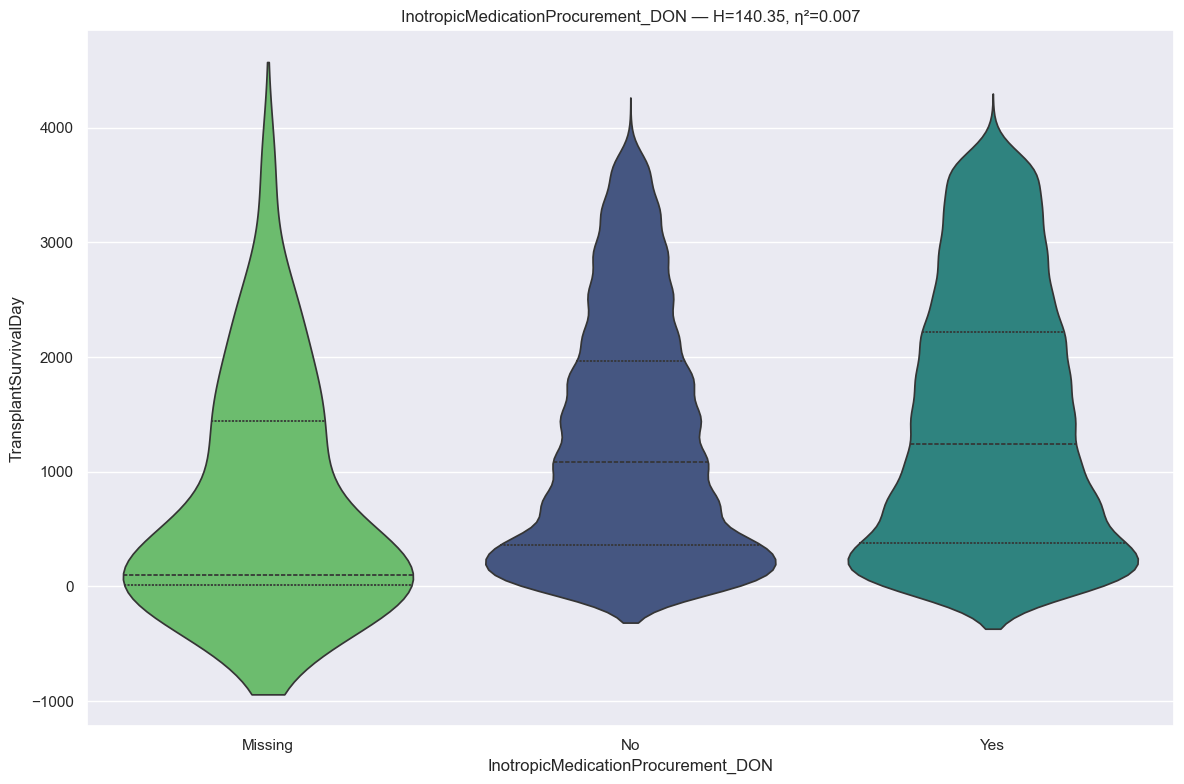

RANKING REPORT: InotropicMedicationProcurement_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  12182 records
 * Yes                                               :   7759 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     28 records
--------------------------------------------------------------------------------
Kruskal H: 140.3545 | P-value: 3.329726e-31 | Effect η²: 0.0069
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.0039e-28 | thr=0.0167 | r= 0.092 | *Sig*
Missing      vs Yes          | p=1.5979e-06 | thr=0.0167 | r= 0.451 | *Sig*
Missing      vs No           | p=2.8298e-05 | thr=0.0167 | r= 0.393 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [275]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [276]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3', 'Unknown': 'Other'}


,InotropicMedicationProcurement_DON,mean_survival_days,record_count
1,No,1255.995896,12182
3,Yes,1440.549813,7759
0,Missing,737.078947,38
2,Unknown,1346.750000,28


#### LT ONE WEEK

In [277]:
# info
features = u.get_feature_info(df, 'LT_ONE_WEEK', cat=False)
# dtype
{col: df[col].dtype for col in features}

                 count unique top   freq
LT_ONE_WEEK_DON  20007      1  No  20007

:::: NaN Count:
LT_ONE_WEEK_DON    0 



{'LT_ONE_WEEK_DON': CategoricalDtype(categories=['No'], ordered=False, categories_dtype=object)}

In [278]:
# add to remove list
remove_cols.extend(features)

#### Transfusion Number

In [279]:
# info
features = u.get_feature_info(df, 'TransfusionNumber', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique   top  freq
TransfusionNumber_DON  20007      6  NONE  9794

:::: NaN Count:
TransfusionNumber_DON    0 



{'TransfusionNumber_DON': CategoricalDtype(categories=['1 - 5', '6 - 10', 'GREATER THAN 10', 'Missing', 'NONE',
                   'UNKNOWN'],
 , ordered=False, categories_dtype=object)}

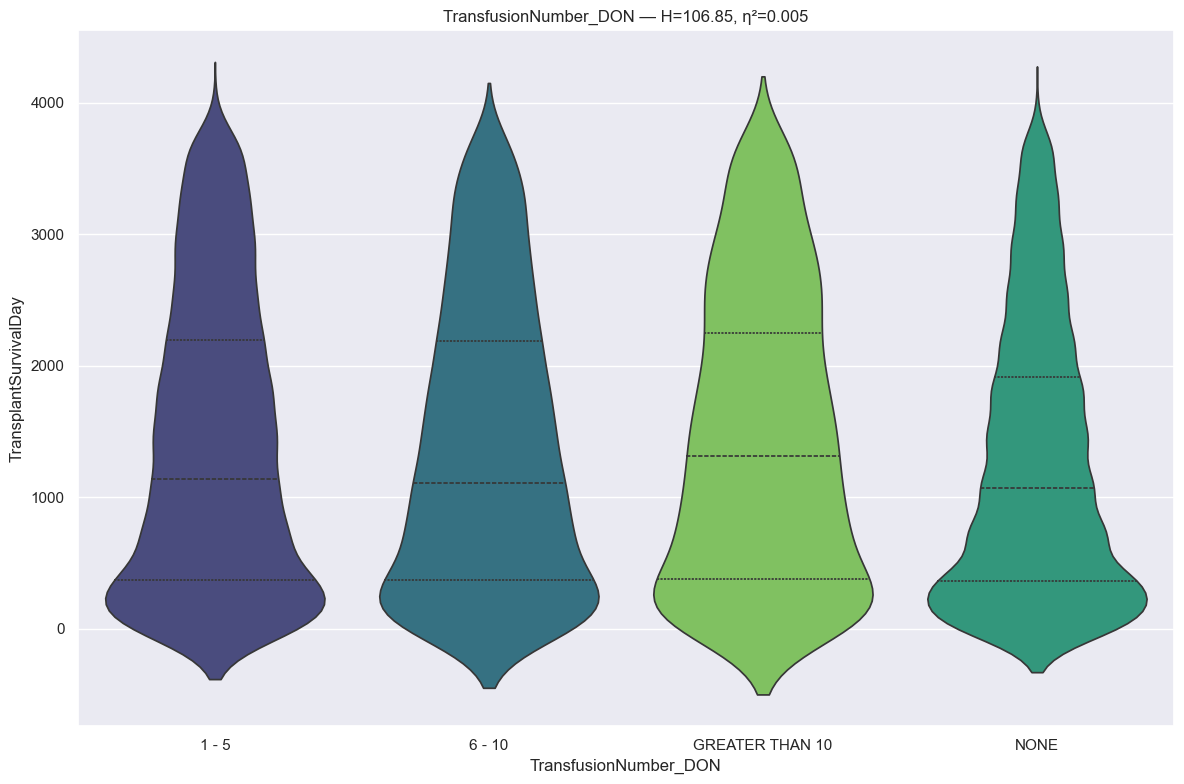

RANKING REPORT: TransfusionNumber_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * 1 - 5                                             :   6181 records
 * 6 - 10                                            :   2422 records
 * GREATER THAN 10                                   :   1590 records
 * NONE                                              :   9794 records
BYPASSED CATEGORIES (n < min_n):
 * Missing                                           :     19 records
 * UNKNOWN                                           :      1 records
--------------------------------------------------------------------------------
Kruskal H: 106.8539 | P-value: 5.215721e-23 | Effect η²: 0.0052
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0083 | r_threshold: 0.10)
--------------------------------------------------------------------------------
1 - 5        vs NONE         | p=1.2409e-18 | thr=0.0083 | r=-0.083 | *Sig*
GREATER THAN 10 vs NONE         | p=2.3741e-11 | thr=0.0083 | r=-0.104 | *Sig*
6 - 

In [280]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [281]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'1 - 5': 'Group_1', '6 - 10': 'Group_1', 'GREATER THAN 10': 'Group_1', 'NONE': 'Group_2', 'Missing': 'Other', 'UNKNOWN': 'Other'}


,TransfusionNumber_DON,mean_survival_days,record_count
4,NONE,1245.018379,9794
0,1 - 5,1407.576768,6181
1,6 - 10,1374.564822,2422
2,GREATER THAN 10,1442.979874,1590
3,Missing,1274.157895,19
5,UNKNOWN,1801.000000,1


In [282]:
# mapping
mapping = {'Missing': 'Other',
           'UNKNOWN': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,TransfusionNumber_DON,mean_survival_days,record_count
3,NONE,1245.018379,9794
0,1 - 5,1407.576768,6181
1,6 - 10,1374.564822,2422
2,GREATER THAN 10,1442.979874,1590
4,Other,1300.500000,20


#### Pulmonary Catheter

In [283]:
# info
features = u.get_feature_info(df, 'PulmonaryCatheter', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique top   freq
PulmonaryCatheter_DON  20007      3  No  18733

:::: NaN Count:
PulmonaryCatheter_DON    0 



{'PulmonaryCatheter_DON': CategoricalDtype(categories=['Missing', 'No', 'Yes'], ordered=False, categories_dtype=object)}

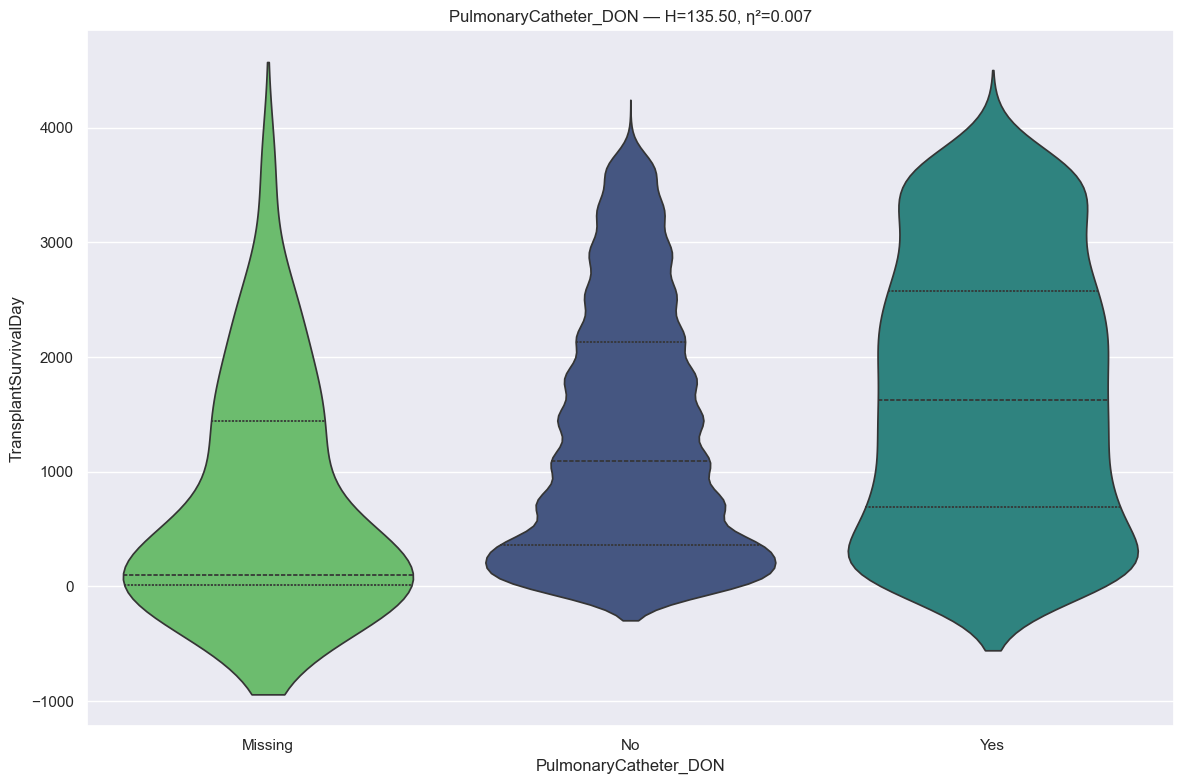

RANKING REPORT: PulmonaryCatheter_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Missing                                           :     38 records
 * No                                                :  18733 records
 * Yes                                               :   1236 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 135.4994 | P-value: 3.772946e-30 | Effect η²: 0.0067
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0167 | r_threshold: 0.10)
--------------------------------------------------------------------------------
No           vs Yes          | p=4.6297e-27 | thr=0.0167 | r= 0.183 | *Sig*
Missing      vs Yes          | p=4.6559e-08 | thr=0.0167 | r= 0.520 | *Sig*
Missing      vs No           | p=1.3278e-05 | thr=0.0167 | r= 0.408 | *Sig*
::::: Collapsed into 3 groups (excluding 'Other') :::::



In [284]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [285]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Missing': 'Group_1', 'No': 'Group_2', 'Yes': 'Group_3'}


,PulmonaryCatheter_DON,mean_survival_days,record_count
1,No,1304.963487,18733
2,Yes,1674.430421,1236
0,Missing,737.078947,38


#### Bronchoscopy Left

In [286]:
# info
features = u.get_feature_info(df, 'BronchoscopyLeft', cat=False)
# dtype
{col: df[col].dtype for col in features}

                      count unique      top   freq
BronchoscopyLeft_DON  20007      9  Missing  10065

:::: NaN Count:
BronchoscopyLeft_DON    0 



{'BronchoscopyLeft_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'Missing', 'No Bronchoscopy',
                   'Normal', 'Unknown', 'Unknown if bronchoscopy performed'],
 , ordered=False, categories_dtype=object)}

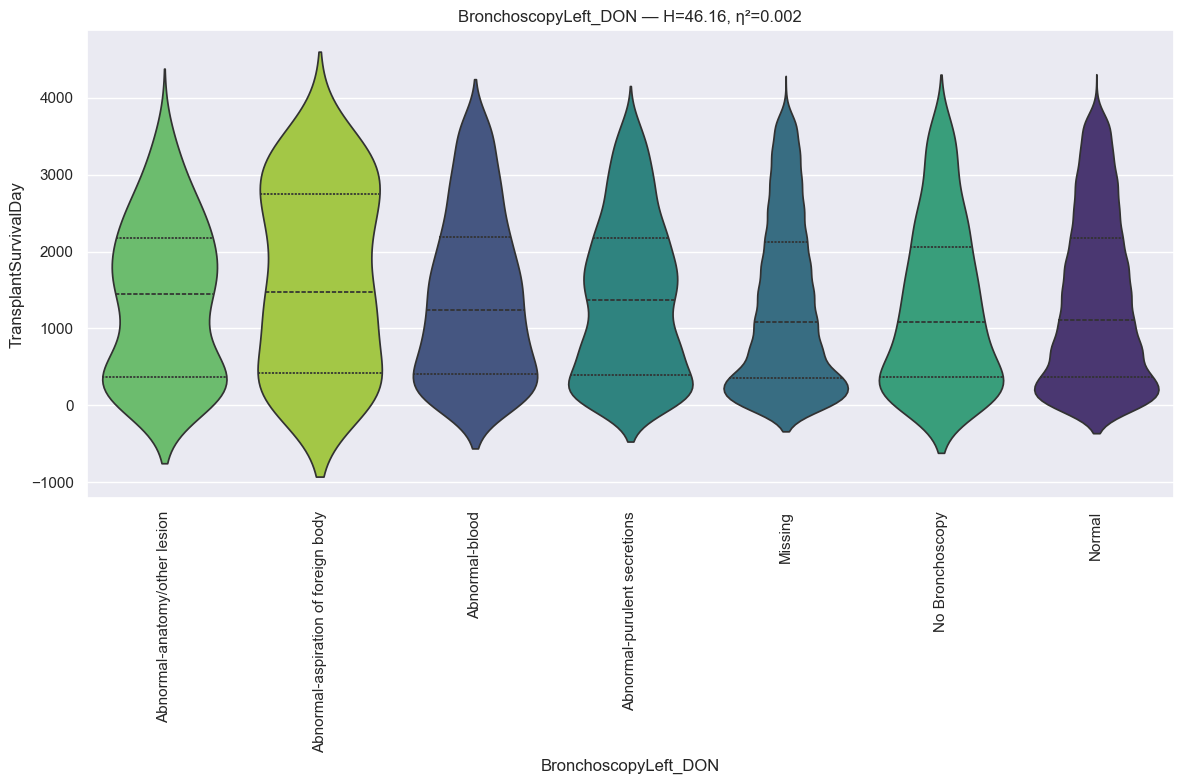

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    126 records
 * Abnormal-aspiration of foreign body               :     94 records
 * Abnormal-blood                                    :    732 records
 * Abnormal-purulent secretions                      :   1475 records
 * Missing                                           :  10065 records
 * No Bronchoscopy                                   :    431 records
 * Normal                                            :   7046 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     28 records
 * Unknown if bronchoscopy performed                 :     10 records
--------------------------------------------------------------------------------
Kruskal H: 46.1626 | P-value: 2.747887e-08 | Effect η²: 0.0020
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
--------------------------------

In [287]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [288]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-anatomy/other lesion': 'Group_1', 'Abnormal-blood': 'Group_1', 'Abnormal-purulent secretions': 'Group_1', 'Missing': 'Group_1', 'No Bronchoscopy': 'Group_1', 'Normal': 'Group_1', 'Abnormal-aspiration of foreign body': 'Group_2', 'Unknown': 'Other', 'Unknown if bronchoscopy performed': 'Other'}


,BronchoscopyLeft_DON,mean_survival_days,record_count
4,Missing,1287.890015,10065
6,Normal,1357.373971,7046
3,Abnormal-purulent secretions,1380.512542,1475
2,Abnormal-blood,1410.337432,732
5,No Bronchoscopy,1280.241299,431
0,Abnormal-anatomy/other lesion,1355.753968,126
1,Abnormal-aspiration of foreign body,1659.031915,94
7,Unknown,1700.678571,28
8,Unknown if bronchoscopy performed,2201.600000,10


In [289]:
# mapping
mapping = {'Unknown': 'Other',
           'Unknown if bronchoscopy performed': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,BronchoscopyLeft_DON,mean_survival_days,record_count
4,Missing,1287.890015,10065
6,Normal,1357.373971,7046
3,Abnormal-purulent secretions,1380.512542,1475
2,Abnormal-blood,1410.337432,732
5,No Bronchoscopy,1280.241299,431
0,Abnormal-anatomy/other lesion,1355.753968,126
1,Abnormal-aspiration of foreign body,1659.031915,94
7,Other,1832.500000,38


In [290]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    126 records
 * Abnormal-aspiration of foreign body               :     94 records
 * Abnormal-blood                                    :    732 records
 * Abnormal-purulent secretions                      :   1475 records
 * Missing                                           :  10065 records
 * No Bronchoscopy                                   :    431 records
 * Normal                                            :   7046 records
 * Other                                             :     38 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 52.4803 | P-value: 4.694651e-09 | Effect η²: 0.0023
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0018 | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output 

In [291]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: BronchoscopyLeft_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    126 records
 * Abnormal-aspiration of foreign body               :     94 records
 * Abnormal-blood                                    :    732 records
 * Abnormal-purulent secretions                      :   1475 records
 * Missing                                           :  10065 records
 * No Bronchoscopy                                   :    431 records
 * Normal                                            :   7046 records
 * Other                                             :     38 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 52.4803 | P-value: 4.694651e-09 | Effect η²: 0.0023
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
[Pairwise comparison output

In [292]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-anatomy/other lesion': 'Group_1', 'Abnormal-blood': 'Group_1', 'Abnormal-purulent secretions': 'Group_1', 'Missing': 'Group_1', 'No Bronchoscopy': 'Group_1', 'Normal': 'Group_1', 'Abnormal-aspiration of foreign body': 'Group_2', 'Other': 'Group_3'}


,BronchoscopyLeft_DON,mean_survival_days,record_count
4,Missing,1287.890015,10065
6,Normal,1357.373971,7046
3,Abnormal-purulent secretions,1380.512542,1475
2,Abnormal-blood,1410.337432,732
5,No Bronchoscopy,1280.241299,431
0,Abnormal-anatomy/other lesion,1355.753968,126
1,Abnormal-aspiration of foreign body,1659.031915,94
7,Other,1832.500000,38


In [293]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Bronchoscopy Right

In [294]:
# info
features = u.get_feature_info(df, 'BronchoscopyRight', cat=False)
# dtype
{col: df[col].dtype for col in features}

                       count unique      top   freq
BronchoscopyRight_DON  20007      9  Missing  10233

:::: NaN Count:
BronchoscopyRight_DON    0 



{'BronchoscopyRight_DON': CategoricalDtype(categories=['Abnormal-anatomy/other lesion',
                   'Abnormal-aspiration of foreign body', 'Abnormal-blood',
                   'Abnormal-purulent secretions', 'Missing', 'No Bronchoscopy',
                   'Normal', 'Unknown', 'Unknown if bronchoscopy performed'],
 , ordered=False, categories_dtype=object)}

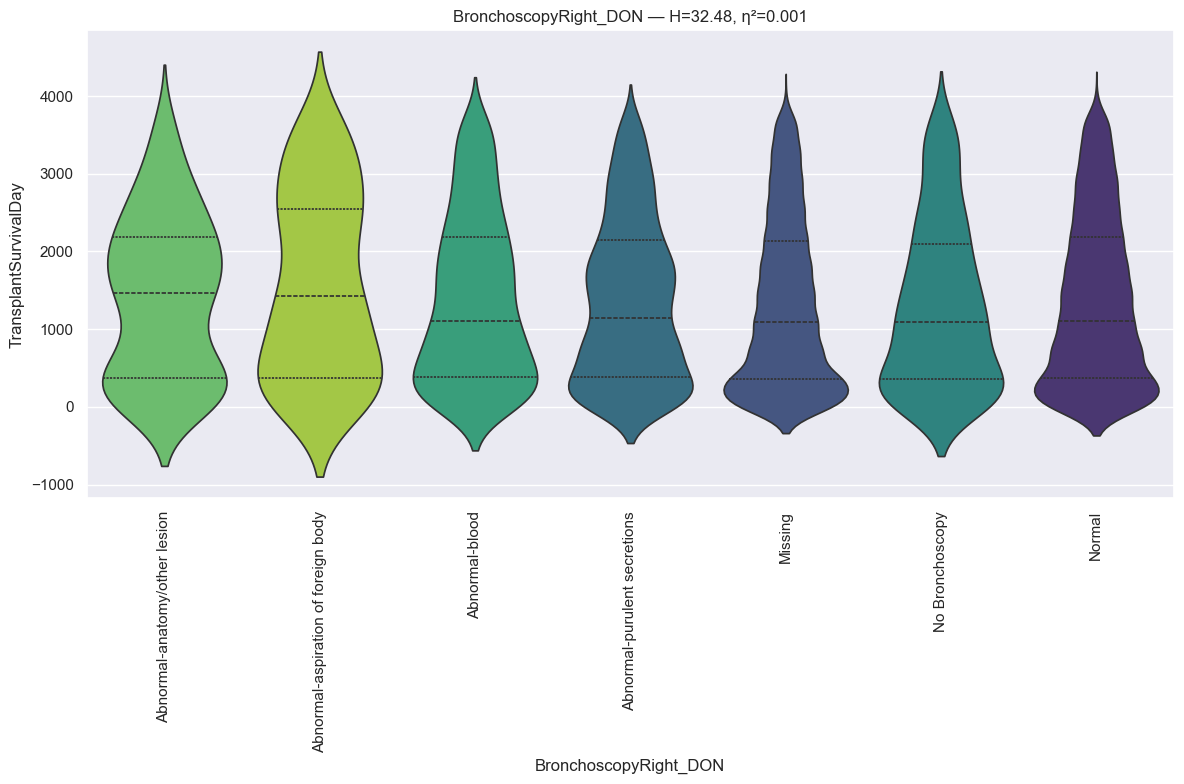

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    149 records
 * Abnormal-aspiration of foreign body               :    121 records
 * Abnormal-blood                                    :    797 records
 * Abnormal-purulent secretions                      :   1706 records
 * Missing                                           :  10233 records
 * No Bronchoscopy                                   :    434 records
 * Normal                                            :   6530 records
BYPASSED CATEGORIES (n < min_n):
 * Unknown                                           :     29 records
 * Unknown if bronchoscopy performed                 :      8 records
--------------------------------------------------------------------------------
Kruskal H: 32.4755 | P-value: 1.322611e-05 | Effect η²: 0.0013
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0024 | r_threshold: 0.10)
-------------------------------

In [295]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    rotation=90
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [296]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-anatomy/other lesion': 'Group_1', 'Abnormal-aspiration of foreign body': 'Group_1', 'Abnormal-blood': 'Group_1', 'Abnormal-purulent secretions': 'Group_1', 'Missing': 'Group_1', 'No Bronchoscopy': 'Group_1', 'Normal': 'Group_1', 'Unknown': 'Other', 'Unknown if bronchoscopy performed': 'Other'}


,BronchoscopyRight_DON,mean_survival_days,record_count
4,Missing,1293.527314,10233
6,Normal,1353.679479,6530
3,Abnormal-purulent secretions,1365.077374,1706
2,Abnormal-blood,1389.775408,797
5,No Bronchoscopy,1305.043779,434
0,Abnormal-anatomy/other lesion,1420.181208,149
1,Abnormal-aspiration of foreign body,1559.190083,121
7,Unknown,1602.724138,29
8,Unknown if bronchoscopy performed,2210.500000,8


In [297]:
# mapping
mapping = {'Unknown': 'Other',
           'Unknown if bronchoscopy performed': 'Other'
          }
# map the change
df[features[0]] = (df[features[0]].map(mapping).fillna(df[features[0]]))

# sanity check
mean_survival_by_category(df, features[0])

,BronchoscopyRight_DON,mean_survival_days,record_count
4,Missing,1293.527314,10233
6,Normal,1353.679479,6530
3,Abnormal-purulent secretions,1365.077374,1706
2,Abnormal-blood,1389.775408,797
5,No Bronchoscopy,1305.043779,434
0,Abnormal-anatomy/other lesion,1420.181208,149
1,Abnormal-aspiration of foreign body,1559.190083,121
7,Other,1734.135135,37


In [298]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    149 records
 * Abnormal-aspiration of foreign body               :    121 records
 * Abnormal-blood                                    :    797 records
 * Abnormal-purulent secretions                      :   1706 records
 * Missing                                           :  10233 records
 * No Bronchoscopy                                   :    434 records
 * Normal                                            :   6530 records
 * Other                                             :     37 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 35.6096 | P-value: 8.588111e-06 | Effect η²: 0.0014
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0018 | r_threshold: 0.10)
--------------------------------------------------------------------------------
[Pairwise comparison output

In [299]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="holm",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.05,        # Lower r-threshold (strict merging)
    plot=False,
    suppress_pairwise=True
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame & remove last entry 
mapping_df = mapping_df[mapping_df["feature"] != features[0]]
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

RANKING REPORT: BronchoscopyRight_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-anatomy/other lesion                     :    149 records
 * Abnormal-aspiration of foreign body               :    121 records
 * Abnormal-blood                                    :    797 records
 * Abnormal-purulent secretions                      :   1706 records
 * Missing                                           :  10233 records
 * No Bronchoscopy                                   :    434 records
 * Normal                                            :   6530 records
 * Other                                             :     37 records
BYPASSED CATEGORIES: None
--------------------------------------------------------------------------------
Kruskal H: 35.6096 | P-value: 8.588111e-06 | Effect η²: 0.0014
Correction Method: HOLM
Pairwise Testing (Base Alpha: 0.05 | Method: HOLM | r_threshold: 0.05)
--------------------------------------------------------------------------------
[Pairwise comparison outpu

In [300]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-anatomy/other lesion': 'Group_1', 'Abnormal-blood': 'Group_1', 'Abnormal-purulent secretions': 'Group_1', 'Missing': 'Group_1', 'No Bronchoscopy': 'Group_1', 'Normal': 'Group_1', 'Abnormal-aspiration of foreign body': 'Group_2', 'Other': 'Group_3'}


,BronchoscopyRight_DON,mean_survival_days,record_count
4,Missing,1293.527314,10233
6,Normal,1353.679479,6530
3,Abnormal-purulent secretions,1365.077374,1706
2,Abnormal-blood,1389.775408,797
5,No Bronchoscopy,1305.043779,434
0,Abnormal-anatomy/other lesion,1420.181208,149
1,Abnormal-aspiration of foreign body,1559.190083,121
7,Other,1734.135135,37


In [301]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Chest Xray

In [302]:
# info
features = u.get_feature_info(df, 'ChestXray', cat=False)
# dtype
{col: df[col].dtype for col in features}

               count unique            top   freq
ChestXray_DON  20007      7  Abnormal-both  10560

:::: NaN Count:
ChestXray_DON    0 



{'ChestXray_DON': CategoricalDtype(categories=['Abnormal-both', 'Abnormal-left', 'Abnormal-right',
                   'Missing', 'No chest x-ray', 'Normal', 'Results Unknown'],
 , ordered=False, categories_dtype=object)}

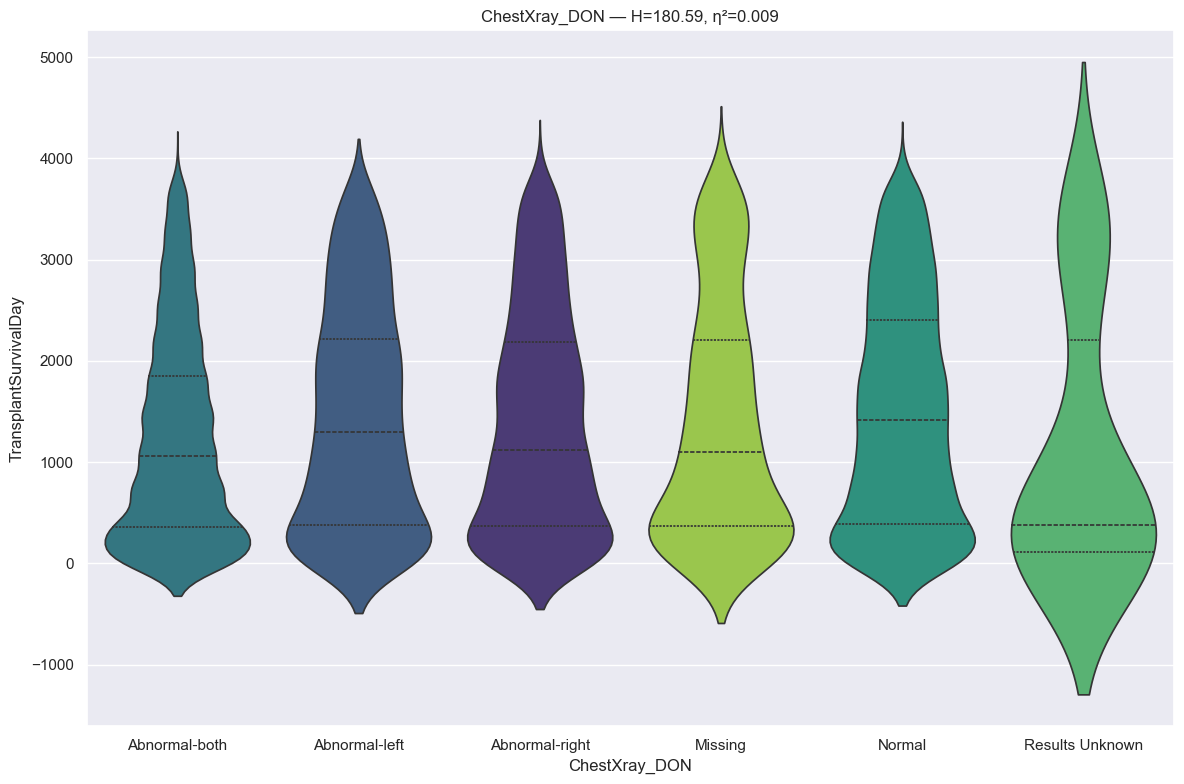

RANKING REPORT: ChestXray_DON (n ≥ 30)
INCLUDED CATEGORIES:
 * Abnormal-both                                     :  10560 records
 * Abnormal-left                                     :   1738 records
 * Abnormal-right                                    :   2540 records
 * Missing                                           :    943 records
 * Normal                                            :   4181 records
 * Results Unknown                                   :     35 records
BYPASSED CATEGORIES (n < min_n):
 * No chest x-ray                                    :     10 records
--------------------------------------------------------------------------------
Kruskal H: 180.5922 | P-value: 3.999083e-37 | Effect η²: 0.0088
Correction Method: BONFERRONI
Pairwise Testing (Bonferroni Alpha: 0.0033 | r_threshold: 0.10)
--------------------------------------------------------------------------------
Abnormal-both vs Normal       | p=8.8925e-33 | thr=0.0033 | r= 0.126 | *Sig*
Abnormal-both vs Abn

In [303]:
# instantiate class
ranker = NominalSurvivalRanker.NominalSurvivalRanker(
    method="bonferroni",  # bonferroni, Holm-Bonferroni (holm) Benjamini–Hochberg (fdr)
    r_thresh=0.10,        # Lower r-threshold (strict merging)
)
# initialize variable
results = ranker.fit(df, features[0])
# mapping DataFrame
new_row = pd.DataFrame([ranker.build_feature_dict(results)])
mapping_df = pd.concat([mapping_df, new_row], ignore_index=True)

In [304]:
# mapping dictionary
print(results['mapping'])
mean_survival_by_category(df, features[0])

{'Abnormal-both': 'Group_1', 'Abnormal-left': 'Group_2', 'Abnormal-right': 'Group_2', 'Missing': 'Group_2', 'Normal': 'Group_2', 'Results Unknown': 'Group_3', 'No chest x-ray': 'Other'}


,ChestXray_DON,mean_survival_days,record_count
0,Abnormal-both,1227.773485,10560
5,Normal,1474.724229,4181
2,Abnormal-right,1397.285433,2540
1,Abnormal-left,1431.290564,1738
3,Missing,1395.778367,943
6,Results Unknown,1115.314286,35
4,No chest x-ray,2043.300000,10


In [305]:
# mapping dictionary
collapse_map = results['mapping']
# New feature
df[features[0] + "_group"] = (
    df[features[0]]
    .map(collapse_map)
    .astype("category")
)
# add to remove list
remove_cols.extend(features)
# update feature with new name
mapping_df.loc[mapping_df["feature"].isin(features), "feature"] = mapping_df["feature"] + "_group"
# sanity check
df[features[0] + "_group"].isna().any()

np.False_

#### Meds_DON

In [306]:
# info
features = u.get_feature_info(df, 'Meds', cat=False)
# dtype
{col: df[col].dtype for col in features}

          count unique top freq
Meds_DON  20007  16763      369

:::: NaN Count:
Meds_DON    0 



{'Meds_DON': dtype('O')}

In [307]:
# add to remove list
remove_cols.extend(features)
# info
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 20007 entries, 0 to 28750
Data columns (total 117 columns):
 #    Column                                Non-Null Count  Dtype   
---   ------                                --------------  -----   
 0    DeceasedRetyped_DON                   20007 non-null  category
 1    AntigenDA1_DON                        20007 non-null  category
 2    AntigenDA2_DON                        20007 non-null  category
 3    AntigenDB1_DON                        20007 non-null  category
 4    AntigenDB2_DON                        20007 non-null  category
 5    AntigenDR1_DON                        20007 non-null  category
 6    AntigenDR2_DON                        20007 non-null  category
 7    Citizenship_DON                       20007 non-null  category
 8    PastCocaineUse_DON                    20007 non-null  category
 9    Age_DON                               20007 non-null  float64 
 10   Ethnicity_DON                         20007 non-null  categor

In [308]:
# remove unwanted columns
df = df.drop(columns=remove_cols).copy()

#### Write to Disk: Full Data

In [309]:
# save data: heart dataset
u.write_to_file(df, 'Male_DON_Heart_Data',path='../Data/', format='pkl')
u.write_to_file(mapping_df, 'Male_DON_Category_Mapping',path='../Data/', format='pkl')

20,007 records written to ../Data/Male_DON_Heart_Data.pkl
68 records written to ../Data/Male_DON_Category_Mapping.pkl
